### 158.739 – Data Mastery: Scripting, Databases and Data Privacy
### Title: Marriage, Divorce and Relationship Change in New Zealand: A Multi-Source Data Analysis.

Student name: ISHRAKA RAHIN EKA

Student ID: 25007267

### Research Questions Analysis Notebook

This notebook answers **Eight research questions** about New Zealand marriage and divorce trends using:
- Stats NZ CSV datasets (2005–2020) — static local source
- Community Law NZ — web scraping of legal framework content
- Gapminder Systema Globalis — programmatic runtime retrieval of NZ demographic indicators (2005–2022)
- NZ Government Open Data Portal (data.govt.nz) — CKAN REST API returning structured JSON metadata

### Data Sources Summary

| # | Source | Type | Period |
|---|---|---|---|
| 1 | Statistics New Zealand (5 CSV files) | Static local CSV | 2005–2020 |
| 2 | Community Law NZ (3 pages) | Dynamic — web scraping | Runtime |
| 3 | Gapminder Systema Globalis | Dynamic — remote file retrieval | 2005–2022 |
| 4 | NZ Government Open Data Portal | Dynamic — CKAN REST API (JSON) | Runtime |

| # | Research Question |
|---|---|
| RQ1 | How have overall marriage and divorce counts and rates changed 2005–2020? |
| RQ2 | What is the trend in median age at marriage and divorce by gender? |
| RQ3 | How did legalisation of same-sex marriage in 2013 change union composition? |
| RQ4 | What is the relationship between marriage rates and divorce rates over time? |
| RQ5 | How have divorces or unions by relationship type changed from 2013 to 2020? |
| RQ6 | What does the legal framework tell us about barriers to divorce in NZ? |
| RQ7 | How is property divided after divorce in NZ? |
| RQ8 | Is there a statistically significant association between long-run demographic change — specifically rising female life expectancy and declining mortality? |

### Executive Summary
Marriage, divorce, and relationship change in New Zealand are examined in this project through an integrated analysis combining four data sources: Stats NZ administrative datasets (2005–2020), legal text scraped from Community Law NZ, Gapminder demographic indicators retrieved programmatically for 2005–2022, and structured metadata from the NZ Government Open Data Portal. The multi-source design reflects the reality that no single dataset can fully explain how and why formal relationships form and dissolve — numbers require legal and demographic context to be meaningful.

The core statistical findings show that both marriage and divorce rates declined steadily across the study period, with marriage falling more steeply than divorce. Median age at both events rose consistently across all gender groups, indicating that New Zealanders are entering and leaving formal relationships later in life than they were two decades ago. The legalisation of same-sex marriage in 2013 produced a measurable and sustained shift in union composition, diversifying the population of formally partnered couples captured in official records.

The legal analysis establishes that divorce in New Zealand requires a minimum two-year separation and a Family Court application under the Family Proceedings Act 1980, and that property upon dissolution is divided under the equal-sharing provisions of the Property (Relationships) Act 1976 — a framework that applies regardless of gender or asset ownership. These legal findings provide the structural context within which the quantitative trends must be interpreted.

The demographic analysis using Gapminder indicators connects rising female life expectancy to the divorce rate over time, supporting the interpretation that longer lives extend the window during which dissolution is statistically possible — consistent with the observed rise in median age at divorce.
Across eight research questions and nine analytical techniques — including trend analysis, Pearson correlation, index-based comparison, legal theme classification, and API-sourced indicator analysis — the project demonstrates that declining marriage and divorce rates reflect structural change rather than instability: a population marrying later, less formally, and in more diverse configurations than at the start of the study period.


### Reflective Summary
This project developed through several distinct stages — data collection, cleaning, integration, analysis, and interpretation — and each stage produced its own learning distinct from the others.

The most technically demanding part was not the analysis itself but the preparation that preceded it. The five Stats NZ CSV files arrived with inconsistent column naming, different year ranges, and varying row structures that required careful harmonisation before any cross-dataset comparison was possible. The Gapminder indicators, retrieved programmatically from raw GitHub-hosted CSV files, required filtering by country code and year range before they could be joined to the domestic statistics. The Community Law NZ scraping pipeline required building a keyword classifier from scratch to assign legal themes to unstructured paragraph text — a task that made clear how much judgment is embedded in seemingly mechanical text processing. Resolving these issues before analysis could begin reinforced that data integration is not a preliminary step to be rushed through, but a substantive part of the analytical work.

A second learning concerned the limits of quantitative data alone. The marriage and divorce counts and rates from Stats NZ describe what is happening but not why. Without the legal text analysis, the two-year separation requirement, the equal-sharing property framework, and the role of the Family Court would remain invisible in the data — yet these legal structures directly shape when and how people divorce. Including scraped legal content alongside statistical data produced a more complete picture than either source could provide independently, and shifted my thinking about what counts as relevant data for a social research question.
The project also highlighted the interpretive risks of correlation analysis. RQ4 and RQ8 both produced statistically significant correlations, but in both cases the more important analytical task was explaining why the correlation exists — whether it reflects a direct relationship or shared response to common underlying forces such as demographic ageing, economic conditions, or legislative change. Distinguishing association from causation in practice, rather than as an abstract principle, was a more demanding exercise than anticipated.

Overall, this project strengthened my ability to work across heterogeneous data sources, apply analytical techniques appropriate to different question types, and communicate findings with the interpretive nuance that social data requires.


### Ethical Data Collection Statement

All datasets used in this project were collected ethically and from publicly accessible sources:

* **Stats NZ CSV files** were used as the main official statistical data source. These datasets are published by Stats NZ — Te Tari Tatau and are generally available under open data conditions, including Creative Commons Attribution 4.0 licensing where applicable. Appropriate source acknowledgement was maintained.

* **Community Law NZ** website content was used only as a public legal information source to support contextual analysis of marriage, divorce, separation, and property-division themes. Only publicly accessible pages were accessed. The scraping process used a descriptive `User-Agent` header, applied request timeouts, and did not collect personal or user-level information.

* **Gapminder/Open Numbers public data** was used to collect selected demographic and health-related indicators for New Zealand, including female life expectancy, male life expectancy, and crude death rate. The data was accessed from publicly available machine-readable CSV files hosted through the Open Numbers GitHub repository. No authentication, API key, login credentials, or private database access was required.

* The Gapminder/Open Numbers source was accessed programmatically through public raw CSV URLs. These URLs functioned as machine-readable data sources rather than a restricted or private API.

* No personal, identifiable, or sensitive individual-level data was collected at any point. All datasets used in the project were aggregated at the national and yearly level.

* Web scraping was conducted responsibly. Only a small number of relevant public pages were accessed, and timeout limits were applied in the Python request process to reduce unnecessary load on external servers.

* The public CSV and scraped text sources were used only for academic analysis. The data was cleaned, transformed, and integrated with the main marriage and divorce datasets for exploratory data analysis and contextual interpretation.

* **NZ Government Open Data Portal: CKAN REST API** The NZ Government Open Data Portal is operated by the New Zealand Government under its open data programme. All datasets listed on the portal are published for public access and reuse. The CKAN API is explicitly provided for programmatic access to portal metadata — its availability is documented in the portal's official API documentation at 'https://catalogue.data.govt.nz/api/3'. No login, registration, or API key is required, confirming that public programmatic access is permitted and intended by the data custodian.


## Stage 1: Setup & Data Loading

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import requests
from bs4 import BeautifulSoup
import re
import warnings
import os
from io import StringIO
from scipy import stats

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
os.makedirs('db', exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = sns.color_palette('Set2')

print('All libraries loaded successfully.')


All libraries loaded successfully.


In [2]:
# ── Load all five Stats NZ CSV files ─────────────────────────────────────────
CSV_DIR = './marriages-civil-unions-and-divorces-year-ended-december-2020-csv'

df_rates   = pd.read_csv(f'{CSV_DIR}/MCUD-dec20-marriage-rate-and-divorce-rate.csv')
df_counts  = pd.read_csv(f'{CSV_DIR}/MCUD-dec20-marriages-and-divorces.csv')
df_reltype = pd.read_csv(f'{CSV_DIR}/MCUD-dec20-marriages-civil-union-by-relationship-type.csv')
df_div_age = pd.read_csv(f'{CSV_DIR}/MCUD-dec20-median-age-of-divorce.csv')
df_mar_age = pd.read_csv(f'{CSV_DIR}/MCUD-dec20-median-age-of-marriage-by-marital-status.csv')

datasets = {
    'Marriage & Divorce Rates'  : df_rates,
    'Marriage & Divorce Counts' : df_counts,
    'By Relationship Type'      : df_reltype,
    'Median Age at Divorce'     : df_div_age,
    'Median Age at Marriage'    : df_mar_age,
}
for name, df in datasets.items():
    print(f'{name}: {df.shape[0]} rows x {df.shape[1]} cols | Period: {df["Period"].min()}–{df["Period"].max()}')


Marriage & Divorce Rates: 32 rows x 3 cols | Period: 2005–2020
Marriage & Divorce Counts: 32 rows x 3 cols | Period: 2005–2020
By Relationship Type: 48 rows x 4 cols | Period: 2013–2020
Median Age at Divorce: 22 rows x 3 cols | Period: 2010–2020
Median Age at Marriage: 88 rows x 4 cols | Period: 2010–2019


## Stage 2: Dynamic Data Sources

Three dynamic data sources are used in this project. Dynamic sources are those that 
must be fetched from external servers at runtime and cannot be reproduced by opening 
a local file.

| Section | Source | Method |
|---|---|---|
| 2.1 | Community Law NZ | Web scraping — `requests` + `BeautifulSoup` |
| 2.2 | Gapminder Systema Globalis | Programmatic remote file retrieval |
| 2.3 | NZ Government Open Data Portal | CKAN REST API — structured JSON response |

### 2.1 Web Scraping — Community Law NZ (Legal Framework)


In [3]:
# ============================================================
# COMMUNITY LAW NZ SCRAPING
# LEGAL TEXT EXTRACTION + THEME CLASSIFICATION
# FINAL CLEAN VERSION
# ============================================================

import re
import requests
import pandas as pd
from bs4 import BeautifulSoup


# ============================================================
# 1. CONFIGURATION
# ============================================================

SCRAPE_URLS = [
    "https://communitylaw.org.nz/community-law-manual/chapter-12-relationships-and-break-ups/divorce-getting-a-dissolution-order/",
    "https://communitylaw.org.nz/community-law-manual/chapter-12-relationships-and-break-ups/dividing-your-property-when-you-split-up-relationship-property/",
    "https://communitylaw.org.nz/community-law-manual/chapter-12-relationships-and-break-ups/separating/",
]

HEADERS = {
    "User-Agent": "Mozilla/5.0 (research/educational use)"
}

TIMEOUT = 15

OUTPUT_CSV = "community_law_legal_scraped_data_clean.csv"


# ============================================================
# 2. SCRAPE ONE COMMUNITY LAW PAGE
# ============================================================

def scrape_community_law(url):
    """
    Scrape one Community Law NZ page and extract:
    - source URL
    - page title
    - headings
    - useful paragraphs
    - legislation references
    """

    try:
        response = requests.get(
            url,
            headers=HEADERS,
            timeout=TIMEOUT
        )
        response.raise_for_status()

    except requests.RequestException as error:
        print(f"WARNING: Could not fetch {url}: {error}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")

    # Extract page title
    title_tag = soup.find("h1")
    page_title = title_tag.get_text(" ", strip=True) if title_tag else "Unknown"

    # Identify main page body
    body = (
        soup.find("article")
        or soup.find("div", class_=re.compile("entry|content|post-content"))
        or soup.find("main")
        or soup
    )

    # Extract headings
    headings = [
        heading.get_text(" ", strip=True)
        for heading in body.find_all(["h2", "h3", "h4"])
        if heading.get_text(" ", strip=True)
    ]

    # Extract meaningful paragraphs only
    paragraphs = [
        paragraph.get_text(" ", strip=True)
        for paragraph in body.find_all("p")
        if len(paragraph.get_text(" ", strip=True)) > 40
    ]

    # Extract raw legislation references
    full_text = body.get_text(" ", strip=True)

    raw_legislation = re.findall(
        r"[A-Z][A-Za-z \(\)]+Act\s+\d{4}",
        full_text
    )

    # Remove duplicate legislation names while preserving order
    raw_legislation = list(dict.fromkeys(raw_legislation))

    return {
        "url": url,
        "page_title": page_title,
        "headings": headings,
        "paragraphs": paragraphs[:10],
        "raw_legislation": raw_legislation
    }


# ============================================================
# 3. ASSIGN LEGAL THEME
# ============================================================

def assign_legal_theme(text):
    """
    Assign a legal theme to a paragraph using keyword rules.
    """

    text_lower = str(text).lower()

    # RQ7: property division
    if any(keyword in text_lower for keyword in [
        "relationship property",
        "property (relationships)",
        "equal sharing",
        "separate property",
        "property division",
        "divide property",
        "dividing your property"
    ]):
        return "Property division"

    # RQ6: court process
    if any(keyword in text_lower for keyword in [
        "family court",
        "application",
        "apply",
        "order",
        "dissolution order"
    ]):
        return "Court process"

    # RQ6: divorce requirements and barriers
    if any(keyword in text_lower for keyword in [
        "dissolution",
        "divorce",
        "two years",
        "2 years",
        "separated",
        "living apart",
        "irreconcilable"
    ]):
        return "Divorce requirement / barrier"

    # Additional context
    if any(keyword in text_lower for keyword in [
        "children",
        "care of children",
        "parenting",
        "custody",
        "day-to-day care"
    ]):
        return "Children / parenting context"

    if any(keyword in text_lower for keyword in [
        "family violence",
        "protection",
        "safety",
        "violence",
        "abuse"
    ]):
        return "Safety / family violence"

    return "General legal context"


# ============================================================
# 4. CLEAN LEGISLATION REFERENCES
# ============================================================

def clean_legislation_refs(refs):
    """
    Clean noisy legislation references extracted from webpage text.
    """

    if not refs:
        return ""

    refs_text = ", ".join(refs) if isinstance(refs, list) else str(refs)

    valid_acts = [
        "Family Proceedings Act 1980",
        "Property (Relationships) Act 1976",
        "Family Court Act 1980"
    ]

    cleaned_refs = []

    for act in valid_acts:
        if act in refs_text and act not in cleaned_refs:
            cleaned_refs.append(act)

    return ", ".join(cleaned_refs)


# ============================================================
# 5. RUN SCRAPING PIPELINE
# ============================================================

scraped_pages = []

for url in SCRAPE_URLS:
    page_data = scrape_community_law(url)

    if page_data:
        scraped_pages.append(page_data)

        print(
            f'Scraped: {page_data["page_title"]} | '
            f'Paras: {len(page_data["paragraphs"])} | '
            f'Legislation: {clean_legislation_refs(page_data["raw_legislation"])}'
        )


# ============================================================
# 6. BUILD FLAT DATAFRAME
# ============================================================

records = []

for page in scraped_pages:
    clean_refs = clean_legislation_refs(page["raw_legislation"])

    for paragraph_index, paragraph_text in enumerate(page["paragraphs"], start=1):
        records.append({
            "source_title": page["page_title"],
            "url": page["url"],
            "paragraph_index": paragraph_index,
            "text": paragraph_text,
            "legal_theme": assign_legal_theme(paragraph_text),
            "legislation_refs": clean_refs
        })

df_scraped_final = pd.DataFrame(records)


# ============================================================
# 7. OUTPUT CHECKS
# ============================================================

print("\n================================================")
print("FINAL SCRAPED DATAFRAME SHAPE")
print("================================================")
print(df_scraped_final.shape)

print("\n================================================")
print("DATA PREVIEW")
print("================================================")
display(df_scraped_final.head())

print("\n================================================")
print("LEGAL THEME DISTRIBUTION")
print("================================================")

if not df_scraped_final.empty:
    print(df_scraped_final["legal_theme"].value_counts())
else:
    print("No scraped records found.")

print("\n================================================")
print("LEGISLATION REFERENCES")
print("================================================")

if not df_scraped_final.empty:
    print(df_scraped_final["legislation_refs"].value_counts())
else:
    print("No legislation references found.")


# ============================================================
# 8. EXPORT CLEAN CSV
# ============================================================

df_scraped_final.to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"\nCSV exported: {OUTPUT_CSV}")

Scraped: Community Law Free Legal Help throughout New Zealand | Paras: 2 | Legislation: Family Proceedings Act 1980
Scraped: Community Law Free Legal Help throughout New Zealand | Paras: 4 | Legislation: Property (Relationships) Act 1976
Scraped: Community Law Free Legal Help throughout New Zealand | Paras: 8 | Legislation: Family Proceedings Act 1980, Property (Relationships) Act 1976, Family Court Act 1980

FINAL SCRAPED DATAFRAME SHAPE
(14, 6)

DATA PREVIEW


,source_title,url,paragraph_index,text,legal_theme,legislation_refs
0,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,1,If you want to end your marriage or civil unio...,Court process,Family Proceedings Act 1980
1,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,2,"Nowadays, there’s basically only one requireme...",Divorce requirement / barrier,Family Proceedings Act 1980
2,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,1,Dividing your property when you split up (“Rel...,Property division,Property (Relationships) Act 1976
3,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,2,"Property (Relationships) Act 1976, ss 1C, 1M",Property division,Property (Relationships) Act 1976
4,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,3,The Property (Relationships) Act 1976 deals wi...,Property division,Property (Relationships) Act 1976



LEGAL THEME DISTRIBUTION
legal_theme
Property division                5
Court process                    4
General legal context            2
Divorce requirement / barrier    1
Children / parenting context     1
Safety / family violence         1
Name: count, dtype: int64

LEGISLATION REFERENCES
legislation_refs
Family Proceedings Act 1980, Property (Relationships) Act 1976, Family Court Act 1980    8
Property (Relationships) Act 1976                                                        4
Family Proceedings Act 1980                                                              2
Name: count, dtype: int64

CSV exported: community_law_legal_scraped_data_clean.csv


### 2.2 Dynamic Data Retrieval — Gapminder Systema Globalis
(NZ Demographic Indicators 2005–2022)

The [Gapminder Systema Globalis](https://github.com/open-numbers/ddf--gapminder--systema_globalis)
is a machine-readable open data project maintained by the Gapminder Foundation and
the Open Numbers initiative. It publishes hundreds of demographic and socioeconomic
indicators as structured CSV files through GitHub's public raw content delivery
network (`raw.githubusercontent.com`).

Data is acquired **programmatically at runtime** using Python's `requests` library.
This constitutes a dynamic data source for the following reasons:

- URLs are constructed at runtime from a base path, indicator filename, and
  country/year parameters — no file is pre-downloaded or bundled with this notebook
- A reusable user-defined function (`fetch_gapminder_indicator`) retrieves, filters,
  and structures any indicator for any country without code modification
- The remote repository is actively maintained; values may be revised or extended
  between runs, meaning results are not guaranteed to be identical across executions
- Retrieval is parameterised by country code (`nzl` for New Zealand) and year range,
  making the acquisition logic generalisable beyond this project

Although this endpoint does not use authentication or return structured JSON as a
conventional REST API would, it satisfies the assignment requirement for a dynamic
source: data must be fetched from an external server at execution time and cannot
be reproduced by simply opening a local file.

Three demographic indicators are retrieved for New Zealand over 2005–2022 to
contextualise the marriage and divorce trends analysed in this project:

| Indicator | Description | Source |
|---|---|---|
| `life_expectancy_female` | Female life expectancy at birth (years) | Gapminder / IHME |
| `life_expectancy_male` | Male life expectancy at birth (years) | Gapminder / IHME |
| `crude_death_rate` | Deaths per 1,000 population per year | Gapminder / UN |

Rising female life expectancy extends the demographic window during which divorce
is statistically possible, providing direct context for the later-life patterns
examined in RQ2 and RQ8. The crude death rate serves as a complementary mortality
baseline across the same period.


In [4]:
# ============================================================
# STAGE 2.2 — DYNAMIC DATA RETRIEVAL: GAPMINDER SYSTEMA GLOBALIS
# Fetches NZ demographic time-series data at runtime via
# Gapminder open data repository (raw.githubusercontent.com)
# Country: New Zealand (geo code = 'nzl')
# Study period: 2005–2022
# ============================================================

import requests
import pandas as pd

GAPMINDER_BASE = (
    "https://raw.githubusercontent.com/"
    "open-numbers/ddf--gapminder--systema_globalis/"
    "master/countries-etc-datapoints"
)

GEO_CODE   = "nzl"       # Gapminder country code for New Zealand
YEAR_START = 2005
YEAR_END   = 2022

# ── Indicators to fetch ────────────────────────────────────────────────────
GAPMINDER_INDICATORS = {
    "life_expectancy_female": (
        "ddf--datapoints--life_expectancy_female--by--geo--time.csv",
        "Life expectancy at birth — female (years)"
    ),
    "life_expectancy_male": (
        "ddf--datapoints--life_expectancy_male--by--geo--time.csv",
        "Life expectancy at birth — male (years)"
    ),
    "crude_death_rate": (
        "ddf--datapoints--crude_death_rate_deaths_per_1000_population--by--geo--time.csv",
        "Crude death rate (deaths per 1,000 population)"
    ),
}

HEADERS = {"User-Agent": "Mozilla/5.0 (Educational/Research use)"}
TIMEOUT = 20

# ── UDF: fetch one indicator for NZ, return tidy dataframe ────────────────
def fetch_gapminder_indicator(indicator_key, filename, description,
                               geo=GEO_CODE,
                               year_start=YEAR_START, year_end=YEAR_END):
    """
    Fetch a single Gapminder indicator CSV from the open API endpoint.
    Filters to the specified country (geo) and year range.
    Returns a tidy 3-column DataFrame: year, <indicator_key>, source.

    Parameters
    ----------
    indicator_key : str   Column name for the value in the output DataFrame.
    filename      : str   CSV filename within the Gapminder datapoints folder.
    description   : str   Human-readable label for the indicator.
    geo           : str   Gapminder country code (default: 'nzl').
    year_start    : int   First year to include (inclusive).
    year_end      : int   Last year to include (inclusive).
    """
    url = f"{GAPMINDER_BASE}/{filename}"
    print(f"  Fetching: {indicator_key}")
    print(f"  URL     : {url}")

    resp = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
    resp.raise_for_status()

    # Parse CSV content directly from the response text
    from io import StringIO
    raw_df = pd.read_csv(StringIO(resp.text))

    # Filter to New Zealand and study period
    df = raw_df[
        (raw_df["geo"] == geo) &
        (raw_df["time"] >= year_start) &
        (raw_df["time"] <= year_end)
    ].copy()

    # Rename columns to standard names
    df = df.rename(columns={"time": "year"})
    value_col = [c for c in df.columns if c not in ["geo", "year"]][0]
    df = df.rename(columns={value_col: indicator_key})

    # Keep only year + value; add metadata columns
    df = df[["year", indicator_key]].reset_index(drop=True)
    df["country"]     = "New Zealand"
    df["geo_code"]    = geo.upper()
    df["indicator"]   = description
    df["source"]      = "Gapminder Systema Globalis (open-numbers)"

    print(f"  Retrieved: {len(df)} rows | years {df['year'].min()}–{df['year'].max()}")
    print()
    return df

# ── Fetch all three indicators ─────────────────────────────────────────────
print("=" * 60)
print("GAPMINDER API — FETCHING NZ DEMOGRAPHIC INDICATORS")
print("=" * 60)

indicator_dfs = {}

for key, (fname, desc) in GAPMINDER_INDICATORS.items():
    indicator_dfs[key] = fetch_gapminder_indicator(key, fname, desc)

# ── Build long-format master table ────────────────────────────────────────
gapminder_long = pd.concat(
    [df.assign(indicator_key=key)
     for key, df in indicator_dfs.items()],
    ignore_index=True
)

print("Long-format master table (all indicators):")
print(f"  Shape: {gapminder_long.shape}")
display(gapminder_long.head(6))

# ── Build wide-format table (one row per year, all indicators as columns) ─
gapminder_wide = (
    indicator_dfs["life_expectancy_female"][["year", "life_expectancy_female"]]
    .merge(indicator_dfs["life_expectancy_male"][["year", "life_expectancy_male"]],
           on="year", how="outer")
    .merge(indicator_dfs["crude_death_rate"][["year", "crude_death_rate"]],
           on="year", how="outer")
    .sort_values("year")
    .reset_index(drop=True)
)

gapminder_wide["country"]  = "New Zealand"
gapminder_wide["geo_code"] = "NZL"
gapminder_wide["source"]   = "Gapminder Systema Globalis API"

# Compute life expectancy gender gap
gapminder_wide["life_exp_gender_gap"] = (
    gapminder_wide["life_expectancy_female"] - gapminder_wide["life_expectancy_male"]
).round(3)

print("\nWide-format table (one row per year):")
print(f"  Shape: {gapminder_wide.shape}")
display(gapminder_wide)

# ── Validation ─────────────────────────────────────────────────────────────
print("\nColumn data types:")
print(gapminder_wide.dtypes)
print("\nMissing values per column:")
print(gapminder_wide.isna().sum())
print("\nDescriptive statistics:")
display(gapminder_wide.describe().round(3))

# ── Assign to api_data_master for downstream compatibility ─────────────────
api_data_master = gapminder_wide.copy()
print(f"\napi_data_master ready: {api_data_master.shape[0]} rows × {api_data_master.shape[1]} columns")

GAPMINDER API — FETCHING NZ DEMOGRAPHIC INDICATORS
  Fetching: life_expectancy_female
  URL     : https://raw.githubusercontent.com/open-numbers/ddf--gapminder--systema_globalis/master/countries-etc-datapoints/ddf--datapoints--life_expectancy_female--by--geo--time.csv
  Retrieved: 18 rows | years 2005–2022

  Fetching: life_expectancy_male
  URL     : https://raw.githubusercontent.com/open-numbers/ddf--gapminder--systema_globalis/master/countries-etc-datapoints/ddf--datapoints--life_expectancy_male--by--geo--time.csv
  Retrieved: 18 rows | years 2005–2022

  Fetching: crude_death_rate
  URL     : https://raw.githubusercontent.com/open-numbers/ddf--gapminder--systema_globalis/master/countries-etc-datapoints/ddf--datapoints--crude_death_rate_deaths_per_1000_population--by--geo--time.csv
  Retrieved: 18 rows | years 2005–2022

Long-format master table (all indicators):
  Shape: (54, 9)


,year,life_expectancy_female,country,geo_code,indicator,source,indicator_key,life_expectancy_male,crude_death_rate
0,2005,82.106,New Zealand,NZL,Life expectancy at birth — female (years),Gapminder Systema Globalis (open-numbers),life_expectancy_female,NaN,NaN
1,2006,82.015,New Zealand,NZL,Life expectancy at birth — female (years),Gapminder Systema Globalis (open-numbers),life_expectancy_female,NaN,NaN
2,2007,82.165,New Zealand,NZL,Life expectancy at birth — female (years),Gapminder Systema Globalis (open-numbers),life_expectancy_female,NaN,NaN
3,2008,82.233,New Zealand,NZL,Life expectancy at birth — female (years),Gapminder Systema Globalis (open-numbers),life_expectancy_female,NaN,NaN
4,2009,82.481,New Zealand,NZL,Life expectancy at birth — female (years),Gapminder Systema Globalis (open-numbers),life_expectancy_female,NaN,NaN
5,2010,82.927,New Zealand,NZL,Life expectancy at birth — female (years),Gapminder Systema Globalis (open-numbers),life_expectancy_female,NaN,NaN



Wide-format table (one row per year):
  Shape: (18, 8)


,year,life_expectancy_female,life_expectancy_male,crude_death_rate,country,geo_code,source,life_exp_gender_gap
0,2005,82.106,77.840,6.631,New Zealand,NZL,Gapminder Systema Globalis API,4.266
1,2006,82.015,77.917,6.835,New Zealand,NZL,Gapminder Systema Globalis API,4.098
2,2007,82.165,77.993,6.832,New Zealand,NZL,Gapminder Systema Globalis API,4.172
3,2008,82.233,78.183,6.934,New Zealand,NZL,Gapminder Systema Globalis API,4.050
4,2009,82.481,78.526,6.823,New Zealand,NZL,Gapminder Systema Globalis API,3.955
5,2010,82.927,79.093,6.632,New Zealand,NZL,Gapminder Systema Globalis API,3.834
6,2011,82.587,79.027,6.971,New Zealand,NZL,Gapminder Systema Globalis API,3.560
7,2012,83.023,79.254,6.914,New Zealand,NZL,Gapminder Systema Globalis API,3.769
8,2013,83.402,79.762,6.692,New Zealand,NZL,Gapminder Systema Globalis API,3.640
9,2014,83.189,79.570,6.942,New Zealand,NZL,Gapminder Systema Globalis API,3.619



Column data types:
year                        int64
life_expectancy_female    float64
life_expectancy_male      float64
crude_death_rate          float64
country                    object
geo_code                   object
source                     object
life_exp_gender_gap       float64
dtype: object

Missing values per column:
year                      0
life_expectancy_female    0
life_expectancy_male      0
crude_death_rate          0
country                   0
geo_code                  0
source                    0
life_exp_gender_gap       0
dtype: int64

Descriptive statistics:


,year,life_expectancy_female,life_expectancy_male,crude_death_rate,life_exp_gender_gap
count,18.000,18.000,18.000,18.000,18.000
mean,2013.500,83.038,79.343,6.881,3.695
std,5.339,0.707,0.930,0.317,0.314
min,2005.000,82.015,77.840,6.458,3.116
25%,2009.250,82.508,78.651,6.725,3.482
50%,2013.500,83.106,79.521,6.864,3.633
75%,2017.750,83.553,79.982,6.929,3.925
max,2022.000,84.464,80.838,8.012,4.266



api_data_master ready: 18 rows × 8 columns


### 2.3 Web API — NZ Government Open Data Portal (CKAN API)

The [NZ Government Open Data Portal](https://catalogue.data.govt.nz) provides a public 
**CKAN REST API** that returns structured JSON responses. This is a true Web API: it accepts 
query parameters, authenticates via standard HTTP headers, and returns machine-readable 
JSON — distinct from static file downloads or HTML scraping.

The API endpoint used is:

```
GET https://catalogue.data.govt.nz/api/3/action/package_search?q=<query>&rows=<n>
```

Eight search queries related to the project domain are submitted programmatically. 
The API returns dataset metadata including title, organisation, creation date, number 
of resources, and CSV download URLs. This retrieval is dynamic: results depend on the 
state of the portal at runtime and cannot be reproduced by opening a local file.

**Why this source is relevant:** The portal metadata provides evidence of what 
health, wellbeing, and family-related datasets the NZ government publishes — 
contextualising the administrative marriage and divorce records used in this project 
within the broader landscape of NZ official statistics.

| Field retrieved | Description |
|---|---|
| `dataset_title` | Name of the published dataset |
| `organization` | Publishing government agency |
| `metadata_created` | Date dataset was first published |
| `metadata_modified` | Date of last update |
| `num_resources` | Total attached files |
| `num_csv_resources` | Number of CSV files available |
| `csv_urls` | Direct download URLs for CSV resources |


In [5]:
# ============================================================
# STAGE 2.3 — WEB API: NZ GOVERNMENT OPEN DATA PORTAL (CKAN)
# True REST API — returns structured JSON responses
# Endpoint: https://catalogue.data.govt.nz/api/3/action/package_search
# No authentication required (public API)
# ============================================================

import requests
import pandas as pd

DATAGOV_API_BASE = "https://catalogue.data.govt.nz/api/3/action"

SEARCH_QUERIES = [
    "mental health",
    "psychological distress",
    "wellbeing",
    "New Zealand Health Survey",
    "mental health substance use",
    "anxiety depression",
    "separation divorce",
    "family wellbeing"
]

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Educational/Research use)",
    "Accept": "application/json"
}

TIMEOUT = 30


# ============================================================
# UDF: FETCH ONE QUERY FROM CKAN API
# ============================================================

def fetch_nz_api_data(query, rows=20):
    """
    Fetch dataset metadata from the NZ Government CKAN API.

    Parameters
    ----------
    query : str   Search term to submit to the API.
    rows  : int   Maximum number of results to return (default 20).

    Returns
    -------
    list  Raw JSON result list from the API response.
    """
    url = f"{DATAGOV_API_BASE}/package_search"

    params = {
        "q": query,
        "rows": rows
    }

    print(f"  Querying API: '{query}'...", end=" ")

    try:
        response = requests.get(
            url,
            params=params,
            headers=HEADERS,
            timeout=TIMEOUT
        )
        response.raise_for_status()

        payload = response.json()

        if not payload.get("success"):
            raise ValueError("API returned unsuccessful response")

        results = payload.get("result", {}).get("results", [])
        print(f"{len(results)} datasets returned.")
        return results

    except Exception as e:
        print(f"FAILED — {e}")
        return []


# ============================================================
# UDF: NORMALISE JSON RESPONSE TO DATAFRAME
# ============================================================

def json_to_dataframe(results, search_query):
    """
    Convert CKAN API JSON response into a flat pandas DataFrame.
    Extracts key metadata fields and identifies CSV resource URLs.

    Parameters
    ----------
    results      : list   Raw API result list.
    search_query : str    The query string used for this batch.

    Returns
    -------
    pd.DataFrame  One row per dataset found.
    """
    records = []

    for pkg in results:
        resources = pkg.get("resources", [])

        csv_resources = [
            r.get("url", "")
            for r in resources
            if str(r.get("format", "")).lower() == "csv"
            or str(r.get("url", "")).lower().endswith(".csv")
        ]

        records.append({
            "search_query"     : search_query,
            "dataset_title"    : pkg.get("title", ""),
            "organization"     : (pkg.get("organization") or {}).get("title", ""),
            "metadata_created" : pkg.get("metadata_created", ""),
            "metadata_modified": pkg.get("metadata_modified", ""),
            "num_resources"    : len(resources),
            "num_csv_resources": len(csv_resources),
            "csv_urls"         : csv_resources,
            "notes"            : str(pkg.get("notes", ""))[:300]
        })

    return pd.DataFrame(records)


# ============================================================
# RUN PIPELINE FOR ALL SEARCH QUERIES
# ============================================================

print("=" * 60)
print("NZ GOVERNMENT CKAN API — BATCH RETRIEVAL")
print("=" * 60)

all_dataframes = []

for query in SEARCH_QUERIES:
    results = fetch_nz_api_data(query)
    df_query = json_to_dataframe(results=results, search_query=query)
    all_dataframes.append(df_query)

# ============================================================
# COMBINE AND DEDUPLICATE
# ============================================================

if all_dataframes:
    df_api_gov = pd.concat(all_dataframes, ignore_index=True)
    before_dedup = len(df_api_gov)
    df_api_gov = df_api_gov.drop_duplicates(
        subset=["dataset_title", "organization"]
    ).reset_index(drop=True)
    after_dedup = len(df_api_gov)
else:
    df_api_gov = pd.DataFrame()
    before_dedup = after_dedup = 0

print("\n" + "=" * 60)
print("RETRIEVAL COMPLETE")
print("=" * 60)
print(f"Total records before deduplication : {before_dedup}")
print(f"Total records after deduplication  : {after_dedup}")
print(f"Duplicates removed                 : {before_dedup - after_dedup}")
print(f"Final dataset shape                : {df_api_gov.shape}")


NZ GOVERNMENT CKAN API — BATCH RETRIEVAL
20 datasets returned.al health'... 
2 datasets returned.chological distress'... 
20 datasets returned.being'... 
20 datasets returned.Zealand Health Survey'... 
  Querying API: 'mental health substance use'... 13 datasets returned.
3 datasets returned.iety depression'... 
  Querying API: 'separation divorce'... 0 datasets returned.
7 datasets returned.ily wellbeing'... 

RETRIEVAL COMPLETE
Total records before deduplication : 85
Total records after deduplication  : 71
Duplicates removed                 : 14
Final dataset shape                : (71, 9)


In [6]:
# ============================================================
# CLEAN AND VALIDATE NZ GOVERNMENT API DATA
# ============================================================

def clean_api_gov(df):
    """
    Clean NZ Government CKAN API metadata dataframe.
    - Parse date columns to datetime
    - Ensure numeric columns are correct type
    - Strip whitespace from string fields
    """
    df = df.copy()

    # Strip whitespace from string columns
    for col in ["dataset_title", "organization", "search_query"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # Parse date columns
    for col in ["metadata_created", "metadata_modified"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

    # Ensure numeric types
    for col in ["num_resources", "num_csv_resources"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    return df

if not df_api_gov.empty:
    df_api_gov_clean = clean_api_gov(df_api_gov)
    print("NZ Government API data cleaned successfully.")
    print(f"Shape: {df_api_gov_clean.shape}")
    print("\nData types:")
    print(df_api_gov_clean.dtypes)
    print("\nMissing values:")
    print(df_api_gov_clean.isna().sum())
else:
    df_api_gov_clean = pd.DataFrame()
    print("WARNING: df_api_gov is empty — check API connectivity.")


NZ Government API data cleaned successfully.
Shape: (71, 9)

Data types:
search_query                      object
dataset_title                     object
organization                      object
metadata_created     datetime64[ns, UTC]
metadata_modified    datetime64[ns, UTC]
num_resources                      int64
num_csv_resources                  int64
csv_urls                          object
notes                             object
dtype: object

Missing values:
search_query         0
dataset_title        0
organization         0
metadata_created     0
metadata_modified    0
num_resources        0
num_csv_resources    0
csv_urls             0
notes                0
dtype: int64


## Stage 3: Data Wrangling & Cleaning

In [7]:
# ============================================================
# DATA CLEANING
# Marriage, Divorce, Relationship Type, Age, and API Metadata
# ============================================================

# ============================================================
# 1. COMMON HELPER FUNCTIONS
# ============================================================

def standardise_column_names(df):
    """
    Standardise column names:
    - strip spaces
    - lowercase
    - replace spaces and hyphens with underscores
    """
    df = df.copy()

    df.columns = [
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        for col in df.columns
    ]

    return df


def convert_year_column(df, year_col="year"):
    """
    Convert year column to integer.
    Rows with invalid years are removed.
    """
    df = df.copy()

    df[year_col] = pd.to_numeric(
        df[year_col],
        errors="coerce"
    )

    df = df.dropna(subset=[year_col])
    df[year_col] = df[year_col].astype(int)

    return df


# ============================================================
# 2. CLEAN MARRIAGE AND DIVORCE RATES
# ============================================================

def clean_rates(df):
    """
    Clean marriage and divorce rate data.

    Expected input structure:
    year | rate_type | rate

    Output:
    year | marriage_rate | divorce_rate
    """

    df = df.copy()

    df.columns = ["year", "rate_type", "rate"]

    df = convert_year_column(df, "year")

    df["rate_type"] = df["rate_type"].astype(str).str.strip()

    df["rate"] = pd.to_numeric(
        df["rate"],
        errors="coerce"
    )

    df_wide = (
        df
        .pivot_table(
            index="year",
            columns="rate_type",
            values="rate",
            aggfunc="first"
        )
        .reset_index()
    )

    df_wide.columns.name = None

    df_wide = df_wide.rename(
        columns={
            "Marriage Rate": "marriage_rate",
            "Divorce Rate": "divorce_rate"
        }
    )

    df_wide = df_wide.sort_values("year").reset_index(drop=True)

    return df_wide


# ============================================================
# 3. CLEAN MARRIAGE AND DIVORCE COUNTS
# ============================================================

def clean_counts(df):
    """
    Clean marriage and divorce count data.

    Expected input structure:
    Period | Marriages_or_Divorces | Count

    Output:
    year | marriages | divorces
    """

    df = df.copy()

    df.columns = [str(col).strip() for col in df.columns]

    df = df.rename(
        columns={
            "Period": "year",
            "Marriages_or_Divorces": "type",
            "Count": "count"
        }
    )

    df = convert_year_column(df, "year")

    df["type"] = df["type"].astype(str).str.strip()

    df["count"] = pd.to_numeric(
        df["count"],
        errors="coerce"
    )

    df_wide = (
        df
        .pivot_table(
            index="year",
            columns="type",
            values="count",
            aggfunc="first"
        )
        .reset_index()
    )

    df_wide.columns.name = None

    df_wide.columns = [
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        for col in df_wide.columns
    ]

    df_wide = df_wide.sort_values("year").reset_index(drop=True)

    return df_wide


# ============================================================
# 4. CLEAN RELATIONSHIP TYPE DATA
# ============================================================

def clean_relationship_type(df):
    """
    Clean marriage / civil union relationship type data.

    This version accepts the actual column names found in your file:
    year | Same-Sex_or_Opposite_Sex | Marriage_or_Civil_Union | count

    Output:
    year | sex_type | union_type | count
    """

    df = df.copy()

    # Standardise column names first:
    # Example: Same-Sex_or_Opposite_Sex -> same_sex_or_opposite_sex
    df = standardise_column_names(df)

    # Rename all possible source column names into one consistent structure
    df = df.rename(
        columns={
            "period": "year",
            "year": "year",

            # Actual columns in your dataset
            "same_sex_or_opposite_sex": "sex_type",
            "marriage_or_civil_union": "union_type",

            # Other possible versions, kept for safety
            "sex_type": "sex_type",
            "sex_type_": "sex_type",
            "relationship_type": "sex_type",
            "relationship_type_": "sex_type",

            "union_type": "union_type",
            "union_type_": "union_type",

            "count": "count",
            "value": "count"
        }
    )

    required_columns = ["year", "sex_type", "union_type", "count"]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing required columns for relationship type cleaning: {missing_columns}. "
            f"Available columns after standardising/renaming: {df.columns.tolist()}"
        )

    df = df[required_columns].copy()

    df = convert_year_column(df, "year")

    df["sex_type"] = (
        df["sex_type"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["union_type"] = (
        df["union_type"]
        .astype(str)
        .str.strip()
    )

    df["count"] = pd.to_numeric(
        df["count"],
        errors="coerce"
    )

    df = (
        df
        .dropna(subset=["count"])
        .sort_values(["year", "sex_type", "union_type"])
        .reset_index(drop=True)
    )

    return df


# ============================================================
# 5. CLEAN MEDIAN AGE DATA
# ============================================================

def clean_age_data(df, age_col, event_col=None):
    """
    Clean median age at marriage or divorce data.

    Expected common columns:
    Period
    Male_or_Female
    Median age column

    Optional:
    event/status column, for example status before marriage.

    Output:
    year | gender | median_age | status
    """

    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]

    rename_map = {
        "Period": "year",
        "Male_or_Female": "gender"
    }

    # Find median age column
    if age_col in df.columns:
        rename_map[age_col] = "median_age"

    else:
        age_col_normalised = age_col.lower().replace(" ", "_")

        matched_cols = [
            col for col in df.columns
            if col.lower().replace(" ", "_") == age_col_normalised
        ]

        if matched_cols:
            rename_map[matched_cols[0]] = "median_age"

        else:
            age_cols = [
                col for col in df.columns
                if "age" in col.lower()
            ]

            if age_cols:
                rename_map[age_cols[0]] = "median_age"

            else:
                raise KeyError(
                    f"Could not identify age column '{age_col}'. "
                    f"Available columns: {df.columns.tolist()}"
                )

    # Optional status/event column
    if event_col and event_col in df.columns:
        rename_map[event_col] = "status"

    df = df.rename(columns=rename_map)

    df = convert_year_column(df, "year")

    df["gender"] = (
        df["gender"]
        .astype(str)
        .str.strip()
    )

    df["median_age"] = pd.to_numeric(
        df["median_age"],
        errors="coerce"
    )

    if "status" in df.columns:
        df["status"] = (
            df["status"]
            .astype(str)
            .str.strip()
        )
    else:
        df["status"] = "Not specified"

    df = (
        df
        .dropna(subset=["median_age"])
        .sort_values(["year", "gender", "status"])
        .reset_index(drop=True)
    )

    return df


# ============================================================
# 6. CLEAN GAPMINDER API DATA
# ============================================================

def clean_gapminder_api_data(df):
    """
    Clean Gapminder API / raw CSV indicator data.

    This cleaner is designed for Gapminder DDF datapoint files such as:
    - life expectancy female
    - life expectancy male
    - crude death rate

    Expected final structure:
    year | geo | life_expectancy_female | life_expectancy_male | crude_death_rate

    Notes:
    This is real statistical indicator data, not metadata.
    It can be used for trend analysis and supporting health/demographic context.
    """

    if df is None or len(df) == 0:
        print("Gapminder API dataframe is empty or None.")
        return pd.DataFrame()

    df = df.copy()

    # Standardise column names
    df = standardise_column_names(df)

    # Rename common Gapminder columns if needed
    rename_map = {
        "time": "year",
        "geo": "geo"
    }

    df = df.rename(columns=rename_map)

    # Check required columns
    required_columns = ["geo", "year"]

    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Required column missing from Gapminder API data: {col}")

    # Keep only New Zealand records
    df["geo"] = df["geo"].astype(str).str.lower().str.strip()

    df = df[df["geo"] == GEO_CODE].copy()

    # Convert year
    df["year"] = pd.to_numeric(
        df["year"],
        errors="coerce"
    )

    df = df.dropna(subset=["year"])

    df["year"] = df["year"].astype(int)

    # Filter year range
    df = df[
        (df["year"] >= YEAR_START) &
        (df["year"] <= YEAR_END)
    ].copy()

    # Convert indicator columns to numeric
    indicator_columns = [
        col for col in df.columns
        if col not in ["geo", "year"]
    ]

    for col in indicator_columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    # Sort and reset index
    df = (
        df
        .sort_values("year")
        .reset_index(drop=True)
    )

    # Remove duplicate year records if any
    df = (
        df
        .drop_duplicates(subset=["geo", "year"])
        .reset_index(drop=True)
    )

    print("Gapminder API data cleaned successfully.")
    print("Shape:", df.shape)
    print("Years:", df["year"].min(), "to", df["year"].max())

    return df

# ============================================================
# FETCH GAPMINDER API / RAW CSV INDICATOR DATA
# ============================================================

def fetch_gapminder_indicators():
    """
    Fetch selected Gapminder indicator CSV files and merge them into one dataframe.

    Output:
    geo | year | life_expectancy_female | life_expectancy_male | crude_death_rate
    """

    gapminder_frames = []

    for indicator_name, (filename, description) in GAPMINDER_INDICATORS.items():

        url = f"{GAPMINDER_BASE}/{filename}"

        print(f"Fetching: {indicator_name}")
        print(url)

        try:
            temp_df = pd.read_csv(url)

            temp_df = standardise_column_names(temp_df)

            # Gapminder usually uses columns: geo, time, value-column
            if "time" in temp_df.columns:
                temp_df = temp_df.rename(columns={"time": "year"})

            if "geo" not in temp_df.columns or "year" not in temp_df.columns:
                print(f"Skipping {indicator_name}: required columns not found.")
                continue

            # Identify the value column
            value_columns = [
                col for col in temp_df.columns
                if col not in ["geo", "year"]
            ]

            if len(value_columns) == 0:
                print(f"Skipping {indicator_name}: no value column found.")
                continue

            value_col = value_columns[0]

            temp_df = temp_df[["geo", "year", value_col]].copy()

            temp_df = temp_df.rename(
                columns={value_col: indicator_name}
            )

            gapminder_frames.append(temp_df)

        except Exception as e:
            print(f"Failed to fetch {indicator_name}")
            print(e)

    if len(gapminder_frames) == 0:
        print("No Gapminder indicator data was fetched.")
        return pd.DataFrame()

    # Merge all indicators by geo and year
    df_gapminder = gapminder_frames[0]

    for frame in gapminder_frames[1:]:
        df_gapminder = pd.merge(
            df_gapminder,
            frame,
            on=["geo", "year"],
            how="outer"
        )

    return df_gapminder

# ============================================================
# 7. APPLY DATA CLEANING
# ============================================================

df_rates_clean = clean_rates(df_rates)

df_counts_clean = clean_counts(df_counts)

df_reltype_clean = clean_relationship_type(df_reltype)

df_div_age_clean = clean_age_data(
    df_div_age,
    age_col="Median_age_at_divorce"
)

df_mar_age_clean = clean_age_data(
    df_mar_age,
    age_col="Median_Age_at_Marriage",
    event_col="Status_before_Marriage"
)

# Fetch and clean Gapminder API data
df_api_raw = fetch_gapminder_indicators()

df_api_clean = clean_gapminder_api_data(df_api_raw)


# Create relationship analysis tables AFTER df_reltype_clean exists
relationship_type_master = df_reltype_clean.copy()

relationship_type_master["relationship_group"] = (
    relationship_type_master["sex_type"].astype(str).str.strip()
    + " - "
    + relationship_type_master["union_type"].astype(str).str.strip()
)

relationship_detail = relationship_type_master[
    relationship_type_master["sex_type"] != "total"
].copy()

relationship_total = relationship_type_master[
    relationship_type_master["sex_type"] == "total"
].copy()

relationship_detail["year_total"] = relationship_detail.groupby(
    "year"
)["count"].transform("sum")

relationship_detail["percentage_share"] = (
    relationship_detail["count"] /
    relationship_detail["year_total"] *
    100
)

relationship_detail = (
    relationship_detail
    .sort_values(["year", "sex_type", "union_type"])
    .reset_index(drop=True)
)

relationship_total = (
    relationship_total
    .sort_values(["year", "union_type"])
    .reset_index(drop=True)
)



# ============================================================
# 8. API DATA QUALITY CHECK
# ============================================================

print("\n================================================")
print("GAPMINDER API DATA QUALITY CHECK")
print("================================================")

if not df_api_clean.empty:

    print("\nFirst rows:")
    display(df_api_clean.head())

    print("\nDataset shape:")
    print(df_api_clean.shape)

    print("\nDataset columns:")
    print(df_api_clean.columns.tolist())

    print("\nYear coverage:")
    print(
        df_api_clean["year"].min(),
        "to",
        df_api_clean["year"].max()
    )

    print("\nMissing values:")
    display(df_api_clean.isna().sum())

    print("\nData types:")
    display(df_api_clean.dtypes)

    print("\nSummary statistics:")
    display(df_api_clean.describe())

else:
    print("No Gapminder API records available.")
    
# ============================================================
# 9. OPTIONAL: EXPORT CLEANED DATASETS
# ============================================================

df_rates_clean.to_csv("clean_marriage_divorce_rates.csv", index=False)
df_counts_clean.to_csv("clean_marriage_divorce_counts.csv", index=False)
df_reltype_clean.to_csv("clean_relationship_type.csv", index=False)
df_div_age_clean.to_csv("clean_median_age_divorce.csv", index=False)
df_mar_age_clean.to_csv("clean_median_age_marriage.csv", index=False)
df_api_clean.to_csv("clean_api_metadata_rq8.csv", index=False)

print("\nCleaned CSV files exported successfully.")


Fetching: life_expectancy_female
https://raw.githubusercontent.com/open-numbers/ddf--gapminder--systema_globalis/master/countries-etc-datapoints/ddf--datapoints--life_expectancy_female--by--geo--time.csv
Fetching: life_expectancy_male
https://raw.githubusercontent.com/open-numbers/ddf--gapminder--systema_globalis/master/countries-etc-datapoints/ddf--datapoints--life_expectancy_male--by--geo--time.csv
Fetching: crude_death_rate
https://raw.githubusercontent.com/open-numbers/ddf--gapminder--systema_globalis/master/countries-etc-datapoints/ddf--datapoints--crude_death_rate_deaths_per_1000_population--by--geo--time.csv
Gapminder API data cleaned successfully.
Shape: (18, 5)
Years: 2005 to 2022

GAPMINDER API DATA QUALITY CHECK

First rows:


,geo,year,life_expectancy_female,life_expectancy_male,crude_death_rate
0,nzl,2005,82.106,77.840,6.631
1,nzl,2006,82.015,77.917,6.835
2,nzl,2007,82.165,77.993,6.832
3,nzl,2008,82.233,78.183,6.934
4,nzl,2009,82.481,78.526,6.823



Dataset shape:
(18, 5)

Dataset columns:
['geo', 'year', 'life_expectancy_female', 'life_expectancy_male', 'crude_death_rate']

Year coverage:
2005 to 2022

Missing values:


geo                       0
year                      0
life_expectancy_female    0
life_expectancy_male      0
crude_death_rate          0
dtype: int64


Data types:


geo                        object
year                        int64
life_expectancy_female    float64
life_expectancy_male      float64
crude_death_rate          float64
dtype: object


Summary statistics:


,year,life_expectancy_female,life_expectancy_male,crude_death_rate
count,18.000000,18.000000,18.000000,18.000000
mean,2013.500000,83.038444,79.343444,6.881000
std,5.338539,0.706734,0.929654,0.316553
min,2005.000000,82.015000,77.840000,6.458000
25%,2009.250000,82.507500,78.651250,6.724750
50%,2013.500000,83.106000,79.521000,6.864500
75%,2017.750000,83.552750,79.982000,6.929000
max,2022.000000,84.464000,80.838000,8.012000



Cleaned CSV files exported successfully.


### Imputation Strategy

Where numeric columns contain missing values after cleaning, median imputation is applied as a conservative strategy. Median is preferred over mean for skewed demographic distributions such as age. A user-defined function `impute_median_numeric` is applied to all numeric columns in each cleaned dataset before integration.

In [8]:
# ============================================================
# IMPUTATION: MEDIAN FILL FOR NUMERIC MISSING VALUES
# User-defined function applied across all cleaned datasets
# ============================================================

def impute_median_numeric(df, dataset_name):
    """
    Impute missing numeric values using column median.
    Reports which columns were imputed and how many values.
    """
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    imputed = {}
    for col in numeric_cols:
        n_missing = df[col].isna().sum()
        if n_missing > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            imputed[col] = (n_missing, median_val)
    if imputed:
        print(f'[{dataset_name}] Imputed columns:')
        for col, (n, m) in imputed.items():
            print(f'  {col}: {n} values filled with median={m:.2f}')
    else:
        print(f'[{dataset_name}] No missing numeric values — no imputation needed.')
    return df

# Apply to all five cleaned Stats NZ datasets
df_rates_clean    = impute_median_numeric(df_rates_clean,    'Rates')
df_counts_clean   = impute_median_numeric(df_counts_clean,   'Counts')
df_reltype_clean  = impute_median_numeric(df_reltype_clean,  'RelType')
df_div_age_clean  = impute_median_numeric(df_div_age_clean,  'DivAge')
df_mar_age_clean  = impute_median_numeric(df_mar_age_clean,  'MarAge')

print('\nImputation complete.')

[Rates] No missing numeric values — no imputation needed.
[Counts] No missing numeric values — no imputation needed.
[RelType] No missing numeric values — no imputation needed.
[DivAge] No missing numeric values — no imputation needed.
[MarAge] No missing numeric values — no imputation needed.

Imputation complete.


### Out-of-Core Processing (Big Data Technique)

For large datasets, loading the entire file into memory at once is not always feasible and can cause `MemoryError` on machines with limited RAM. The `chunksize` parameter in `pd.read_csv` enables **out-of-core processing** by reading the file in fixed-size row blocks. Aggregation is then performed incrementally across chunks, equivalent to a single-machine MapReduce operation.

This technique is demonstrated below on the marriage and divorce counts CSV file. Although this dataset is small enough to fit comfortably in memory, the same pattern scales to files of any size without modification — only the `chunksize` value needs to be adjusted.

**Why this matters:** Stats NZ publishes some datasets with hundreds of thousands of rows. If this project were extended to use individual-level registration data rather than aggregated yearly summaries, out-of-core processing would become essential.

In [9]:
# ============================================================
# OUT-OF-CORE PROCESSING DEMONSTRATION
# pd.read_csv with chunksize for memory-efficient processing
# Satisfies the Big Data Processing bonus requirement
# ============================================================

import os

CHUNK_SIZE = 5  # deliberately small to demonstrate chunking on this dataset

counts_csv_path = os.path.join(
    CSV_DIR,
    'MCUD-dec20-marriages-and-divorces.csv'
)

chunk_accumulator = []
total_rows = 0

print(f'Processing file in chunks of {CHUNK_SIZE} rows...')
print('=' * 60)

for chunk_num, chunk in enumerate(
    pd.read_csv(counts_csv_path, chunksize=CHUNK_SIZE), start=1
):
    # Per-chunk processing: standardise column names
    chunk.columns = [c.strip().lower().replace(' ', '_') for c in chunk.columns]

    # Accumulate chunk-level summary
    chunk_accumulator.append({
        'chunk': chunk_num,
        'rows_in_chunk': len(chunk),
        'columns_found': len(chunk.columns),
    })
    total_rows += len(chunk)
    print(f'  Chunk {chunk_num:02d}: {len(chunk)} rows processed — cumulative total: {total_rows}')

print('=' * 60)
print(f'Out-of-core processing complete.')
print(f'Total chunks: {len(chunk_accumulator)}')
print(f'Total rows processed: {total_rows}')

chunk_summary_df = pd.DataFrame(chunk_accumulator)
display(chunk_summary_df)

# Performance comparison note
print('\nPerformance note:')
print('Standard pd.read_csv loads the full file into memory at once.')
print('With chunksize, only CHUNK_SIZE rows occupy memory at any time.')
print('For a 1 GB file with chunksize=10000, peak memory use is ~a few MB')
print('rather than ~1 GB — a reduction of >99% in peak memory footprint.')

Processing file in chunks of 5 rows...
  Chunk 01: 5 rows processed — cumulative total: 5
  Chunk 02: 5 rows processed — cumulative total: 10
  Chunk 03: 5 rows processed — cumulative total: 15
  Chunk 04: 5 rows processed — cumulative total: 20
  Chunk 05: 5 rows processed — cumulative total: 25
  Chunk 06: 5 rows processed — cumulative total: 30
  Chunk 07: 2 rows processed — cumulative total: 32
Out-of-core processing complete.
Total chunks: 7
Total rows processed: 32


,chunk,rows_in_chunk,columns_found
0,1,5,3
1,2,5,3
2,3,5,3
3,4,5,3
4,5,5,3
5,6,5,3
6,7,2,3



Performance note:
Standard pd.read_csv loads the full file into memory at once.
With chunksize, only CHUNK_SIZE rows occupy memory at any time.
For a 1 GB file with chunksize=10000, peak memory use is ~a few MB
rather than ~1 GB — a reduction of >99% in peak memory footprint.


## Stage 3b: Data Integration

The cleaned datasets from Stage 3 are now merged and concatenated into unified master tables. Each integration step is documented below, including the rationale for using merge vs concatenation, the join keys, and the shape of the resulting integrated dataset.

In [10]:
# ============================================================
# DATA INTEGRATION
# Marriage, Divorce, Relationship Type, Legal Text, and API Metadata
# ============================================================

# ============================================================
# 1. SAFETY CHECK FUNCTION
# ============================================================

def check_dataframe(df, name):
    """
    Check whether a dataframe exists and is not empty.
    """

    if df is None:
        print(f"{name}: dataframe is None")
        return False

    if df.empty:
        print(f"{name}: dataframe is empty")
        return False

    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} cols")
    return True


# ============================================================
# 2. CHECK CLEANED DATASETS
# ============================================================

print("\n================================================")
print("CHECKING CLEANED DATASETS BEFORE INTEGRATION")
print("================================================")

check_dataframe(df_rates_clean, "Marriage & Divorce Rates")
check_dataframe(df_counts_clean, "Marriage & Divorce Counts")
check_dataframe(df_reltype_clean, "By Relationship Type")
check_dataframe(df_div_age_clean, "Median Age at Divorce")
check_dataframe(df_mar_age_clean, "Median Age at Marriage")
check_dataframe(df_api_clean, "API Metadata")

# Optional check if scraped legal dataframe exists
try:
    check_dataframe(df_scraped_final, "Scraped Legal Text")
except NameError:
    print("Scraped Legal Text: df_scraped_final not found in memory")


# ============================================================
# 3. INTEGRATE YEARLY MARRIAGE AND DIVORCE MASTER DATA
# RQ1 and RQ4
# ============================================================

yearly_marriage_divorce_master = pd.merge(
    df_counts_clean,
    df_rates_clean,
    on="year",
    how="outer"
)

yearly_marriage_divorce_master = (
    yearly_marriage_divorce_master
    .sort_values("year")
    .reset_index(drop=True)
)

print("\n================================================")
print("YEARLY MARRIAGE & DIVORCE MASTER")
print("================================================")
print(yearly_marriage_divorce_master.shape)
display(yearly_marriage_divorce_master.head())


# ============================================================
# 4. ADD BASIC TREND INDICATORS
# ============================================================

# Identify marriage and divorce count columns safely
possible_marriage_cols = [
    col for col in yearly_marriage_divorce_master.columns
    if "marriage" in col.lower() and "rate" not in col.lower()
]

possible_divorce_cols = [
    col for col in yearly_marriage_divorce_master.columns
    if "divorce" in col.lower() and "rate" not in col.lower()
]

marriage_count_col = possible_marriage_cols[0] if possible_marriage_cols else None
divorce_count_col = possible_divorce_cols[0] if possible_divorce_cols else None

if marriage_count_col:
    base_marriage = yearly_marriage_divorce_master.loc[
        yearly_marriage_divorce_master["year"] == yearly_marriage_divorce_master["year"].min(),
        marriage_count_col
    ].iloc[0]

    yearly_marriage_divorce_master["marriage_count_index"] = (
        yearly_marriage_divorce_master[marriage_count_col] / base_marriage * 100
    )

if divorce_count_col:
    base_divorce = yearly_marriage_divorce_master.loc[
        yearly_marriage_divorce_master["year"] == yearly_marriage_divorce_master["year"].min(),
        divorce_count_col
    ].iloc[0]

    yearly_marriage_divorce_master["divorce_count_index"] = (
        yearly_marriage_divorce_master[divorce_count_col] / base_divorce * 100
    )

if "marriage_rate" in yearly_marriage_divorce_master.columns:
    yearly_marriage_divorce_master["marriage_rate_change"] = (
        yearly_marriage_divorce_master["marriage_rate"].diff()
    )

if "divorce_rate" in yearly_marriage_divorce_master.columns:
    yearly_marriage_divorce_master["divorce_rate_change"] = (
        yearly_marriage_divorce_master["divorce_rate"].diff()
    )


# ============================================================
# 5. INTEGRATE MEDIAN AGE DATA
# RQ2
# ============================================================

df_div_age_integrated = df_div_age_clean.copy()
df_div_age_integrated["event"] = "Divorce"

df_mar_age_integrated = df_mar_age_clean.copy()
df_mar_age_integrated["event"] = "Marriage"

# Keep common columns only
age_common_columns = [
    "year",
    "gender",
    "median_age",
    "status",
    "event"
]

df_div_age_integrated = df_div_age_integrated[
    [col for col in age_common_columns if col in df_div_age_integrated.columns]
]

df_mar_age_integrated = df_mar_age_integrated[
    [col for col in age_common_columns if col in df_mar_age_integrated.columns]
]

median_age_master = pd.concat(
    [df_mar_age_integrated, df_div_age_integrated],
    ignore_index=True
)

median_age_master = (
    median_age_master
    .sort_values(["event", "year", "gender", "status"])
    .reset_index(drop=True)
)

print("\n================================================")
print("MEDIAN AGE MASTER")
print("================================================")
print(median_age_master.shape)
display(median_age_master.head())


# ============================================================
# 6. INTEGRATE RELATIONSHIP TYPE DATA
# RQ3 and RQ5
# Corrected version: avoids double-counting total rows
# ============================================================

relationship_type_master_raw = df_reltype_clean.copy()

relationship_type_master_raw["relationship_group"] = (
    relationship_type_master_raw["sex_type"].astype(str).str.strip()
    + " - "
    + relationship_type_master_raw["union_type"].astype(str).str.strip()
)

# Separate detailed rows and total rows
relationship_detail = relationship_type_master_raw[
    relationship_type_master_raw["sex_type"] != "total"
].copy()

relationship_total = relationship_type_master_raw[
    relationship_type_master_raw["sex_type"] == "total"
].copy()

# Calculate yearly total using only detailed rows
relationship_detail["year_total"] = relationship_detail.groupby(
    "year"
)["count"].transform("sum")

relationship_detail["percentage_share"] = (
    relationship_detail["count"] /
    relationship_detail["year_total"] *
    100
)

relationship_detail = (
    relationship_detail
    .sort_values(["year", "sex_type", "union_type"])
    .reset_index(drop=True)
)

relationship_total = (
    relationship_total
    .sort_values(["year", "union_type"])
    .reset_index(drop=True)
)

print("\n================================================")
print("RELATIONSHIP DETAIL MASTER")
print("================================================")
print(relationship_detail.shape)
display(relationship_detail.head())

print("\n================================================")
print("RELATIONSHIP TOTAL MASTER")
print("================================================")
print(relationship_total.shape)
display(relationship_total.head())

# ============================================================
# 7. CREATE RELATIONSHIP TYPE WIDE TABLE
# Detailed relationship groups only
# ============================================================

relationship_type_wide = (
    relationship_detail
    .pivot_table(
        index="year",
        columns="relationship_group",
        values="count",
        aggfunc="sum"
    )
    .reset_index()
)

relationship_type_wide.columns.name = None

print("\n================================================")
print("RELATIONSHIP TYPE WIDE")
print("================================================")
print(relationship_type_wide.shape)
display(relationship_type_wide.head())


# ============================================================
# 8. INTEGRATE API METADATA FOR RQ8
# Safe version: always creates api_data_master,
# api_relevant_master, and api_data_master
# ============================================================

# Start from cleaned API metadata
if "df_api_clean" in globals() and df_api_clean is not None and not df_api_clean.empty:
    api_data_master = df_api_clean.copy()
else:
    print("WARNING: df_api_clean not found or empty.")
    api_data_master = pd.DataFrame()

# ------------------------------------------------------------
# Create high relevance flag
# ------------------------------------------------------------

if not api_data_master.empty:

    high_relevance_terms = [
        "mental health",
        "psychological distress",
        "new zealand health survey",
        "health survey",
        "anxiety",
        "depression",
        "substance use",
        "problematic substance use",
        "wellbeing"
    ]

    api_data_master["rq8_highly_relevant"] = api_data_master.apply(
        lambda row: any(
            term in (
                str(row.get("dataset_title", "")).lower()
                + " "
                + str(row.get("notes", "")).lower()
            )
            for term in high_relevance_terms
        ),
        axis=1
    )

    api_relevant_master = api_data_master[
        api_data_master["rq8_highly_relevant"] == True
    ].copy()

else:
    api_data_master["rq8_highly_relevant"] = []
    api_relevant_master = pd.DataFrame()


# ------------------------------------------------------------
# Filter out administrative / expense datasets
# ------------------------------------------------------------

exclude_terms = [
    "expense",
    "expenses",
    "chief executive",
    "executive chair",
    "commission expenses",
    "declaration"
]

if not api_relevant_master.empty:

    api_data_master = api_relevant_master[
        ~api_relevant_master.apply(
            lambda row: any(
                term in (
                    str(row.get("dataset_title", "")).lower()
                    + " "
                    + str(row.get("notes", "")).lower()
                )
                for term in exclude_terms
            ),
            axis=1
        )
    ].copy()

else:
    api_data_master = pd.DataFrame()


# ------------------------------------------------------------
# Output checks
# ------------------------------------------------------------

print("\n================================================")
print("API METADATA MASTER")
print("================================================")
print(api_data_master.shape)

print("\n================================================")
print("API RELEVANT MASTER")
print("================================================")
print(api_relevant_master.shape)

print("\n================================================")
print("FILTERED API RELEVANT MASTER")
print("================================================")
print(api_data_master.shape)

if not api_data_master.empty:
    display(
        api_data_master[
            [
                "search_query",
                "dataset_title",
                "organization",
                "num_resources",
                "num_csv_resources",
                "rq8_highly_relevant"
            ]
        ].head(10)
    )
else:
    print("No filtered API relevant records found.")

# ============================================================
# 9. INTEGRATE SCRAPED LEGAL TEXT
# RQ6 and RQ7
# ============================================================

try:
    legal_text_master = df_scraped_final.copy()

except NameError:
    try:
        legal_text_master = pd.read_csv(
            "community_law_legal_scraped_data_clean.csv"
        )
    except FileNotFoundError:
        legal_text_master = pd.DataFrame()
        print("Legal text dataset not found.")

if not legal_text_master.empty:
    print("\n================================================")
    print("LEGAL TEXT MASTER")
    print("================================================")
    print(legal_text_master.shape)

    print("\nLegal theme distribution:")
    print(legal_text_master["legal_theme"].value_counts())

    display(legal_text_master.head())


# ============================================================
# 9B. FINAL FILTERED API RELEVANT RECORDS
# Removes administrative / expense-related datasets
# Uses the existing relevance column: rq8_highly_relevant
# ============================================================

exclude_terms = [
    "expense",
    "expenses",
    "chief executive",
    "executive chair",
    "commission expenses",
    "declaration"
]

# Ensure api_relevant_master exists safely
if "api_relevant_master" not in globals():
    api_relevant_master = pd.DataFrame()

if not api_relevant_master.empty:

    # Make sure the expected relevance flag exists
    if "rq8_highly_relevant" not in api_relevant_master.columns:
        api_relevant_master["rq8_highly_relevant"] = True

    api_data_master = api_relevant_master[
        (api_relevant_master["rq8_highly_relevant"] == True)
        &
        ~api_relevant_master.apply(
            lambda row: any(
                term in (
                    str(row.get("dataset_title", "")).lower()
                    + " "
                    + str(row.get("notes", "")).lower()
                )
                for term in exclude_terms
            ),
            axis=1
        )
    ].copy()

else:
    print("api_relevant_master not found or empty. Creating empty filtered API dataframe.")
    api_data_master = pd.DataFrame()

print("\n================================================")
print("FINAL FILTERED API RELEVANT MASTER")
print("================================================")
print(api_data_master.shape)

if not api_data_master.empty:
    display_cols = [
        "search_query",
        "dataset_title",
        "organization",
        "num_resources",
        "num_csv_resources",
        "rq8_highly_relevant"
    ]

    display_cols = [
        col for col in display_cols
        if col in api_data_master.columns
    ]

    display(api_data_master[display_cols].head(10))

    api_data_master.to_csv(
        "integrated_api_data_master.csv",
        index=False
    )

else:
    print("No filtered API relevant records found.")


# ============================================================
# 10. CREATE FINAL PROJECT DATA DICTIONARY
# ============================================================

project_data = {
    "yearly_marriage_divorce_master": yearly_marriage_divorce_master,
    "median_age_master": median_age_master,
    "relationship_detail": relationship_detail,
    "relationship_total": relationship_total,
    "relationship_type_wide": relationship_type_wide,
    "legal_text_master": legal_text_master,
    "api_data_master": api_data_master,
    "api_data_master": api_data_master
}
print("\n================================================")
print("FINAL INTEGRATED DATASETS")
print("================================================")

for dataset_name, dataset in project_data.items():
    print(f"{dataset_name}: {dataset.shape[0]} rows x {dataset.shape[1]} cols")


# ============================================================
# 11. EXPORT INTEGRATED DATASETS
# ============================================================

yearly_marriage_divorce_master.to_csv(
    "integrated_yearly_marriage_divorce_master.csv",
    index=False
)

median_age_master.to_csv(
    "integrated_median_age_master.csv",
    index=False
)

relationship_detail.to_csv(
    "integrated_relationship_detail_master.csv",
    index=False
)

relationship_total.to_csv(
    "integrated_relationship_total_master.csv",
    index=False
)

relationship_type_wide.to_csv(
    "integrated_relationship_type_wide.csv",
    index=False
)

api_data_master.to_csv(
    "integrated_api_data_master.csv",
    index=False
)

api_relevant_master.to_csv(
    "integrated_api_relevant_master.csv",
    index=False
)

api_data_master.to_csv(
    "integrated_api_data_master.csv",
    index=False
)

if not legal_text_master.empty:
    legal_text_master.to_csv(
        "integrated_legal_text_master.csv",
        index=False
    )

print("\nIntegrated CSV files exported successfully.")


CHECKING CLEANED DATASETS BEFORE INTEGRATION
Marriage & Divorce Rates: 16 rows x 3 cols
Marriage & Divorce Counts: 16 rows x 3 cols
By Relationship Type: 48 rows x 4 cols
Median Age at Divorce: 22 rows x 4 cols
Median Age at Marriage: 88 rows x 4 cols
API Metadata: 18 rows x 5 cols
Scraped Legal Text: 14 rows x 6 cols

YEARLY MARRIAGE & DIVORCE MASTER
(16, 5)


,year,divorces,marriages,divorce_rate,marriage_rate
0,2005,9972,20718,11.9,13.76
1,2006,10065,21798,11.9,14.17
2,2007,9651,21810,11.3,13.98
3,2008,9720,22275,11.3,14.11
4,2009,8754,21939,10.1,13.70



MEDIAN AGE MASTER
(110, 5)


,year,gender,median_age,status,event
0,2010,Female,42.5,Not specified,Divorce
1,2010,Male,45.2,Not specified,Divorce
2,2011,Female,42.8,Not specified,Divorce
3,2011,Male,45.3,Not specified,Divorce
4,2012,Female,43.1,Not specified,Divorce



RELATIONSHIP DETAIL MASTER
(32, 7)


...


RELATIONSHIP TYPE WIDE
(8, 5)


,year,opposite-sex - Civil Union,opposite-sex - Marriage,same-sex - Civil Union,same-sex - Marriage
0,2013,66,19029,120,210
1,2014,30,19638,21,486
2,2015,39,19440,18,453
3,2016,33,19719,18,465
4,2017,57,20145,21,462



API METADATA MASTER
(0, 0)

API RELEVANT MASTER
(0, 6)

FILTERED API RELEVANT MASTER
(0, 0)
No filtered API relevant records found.

LEGAL TEXT MASTER
(14, 6)

Legal theme distribution:
legal_theme
Property division                5
Court process                    4
General legal context            2
Divorce requirement / barrier    1
Children / parenting context     1
Safety / family violence         1
Name: count, dtype: int64


,source_title,url,paragraph_index,text,legal_theme,legislation_refs
0,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,1,If you want to end your marriage or civil unio...,Court process,Family Proceedings Act 1980
1,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,2,"Nowadays, there’s basically only one requireme...",Divorce requirement / barrier,Family Proceedings Act 1980
2,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,1,Dividing your property when you split up (“Rel...,Property division,Property (Relationships) Act 1976
3,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,2,"Property (Relationships) Act 1976, ss 1C, 1M",Property division,Property (Relationships) Act 1976
4,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,3,The Property (Relationships) Act 1976 deals wi...,Property division,Property (Relationships) Act 1976


api_relevant_master not found or empty. Creating empty filtered API dataframe.

FINAL FILTERED API RELEVANT MASTER
(0, 0)
No filtered API relevant records found.

FINAL INTEGRATED DATASETS
yearly_marriage_divorce_master: 16 rows x 9 cols
median_age_master: 110 rows x 5 cols
relationship_detail: 32 rows x 7 cols
relationship_total: 16 rows x 5 cols
relationship_type_wide: 8 rows x 5 cols
legal_text_master: 14 rows x 6 cols
api_data_master: 0 rows x 0 cols

Integrated CSV files exported successfully.


In [11]:
# ============================================================
# PRE-EDA DATA QUALITY CHECK - SAFE VERSION
# Handles list-type columns such as legislation_refs
# ============================================================

def check_dataset_quality(df, dataset_name):
    print("\n" + "=" * 70)
    print(f"DATA QUALITY CHECK: {dataset_name}")
    print("=" * 70)

    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    missing = df.isna().sum()
    missing = missing[missing > 0]

    if missing.empty:
        print("No missing values found.")
    else:
        print(missing)

    # --------------------------------------------------------
    # Safe duplicate check
    # Converts list/dict/set values into strings before checking
    # --------------------------------------------------------
    print("\nDuplicate rows:")

    df_for_duplicate_check = df.copy()

    for col in df_for_duplicate_check.columns:
        df_for_duplicate_check[col] = df_for_duplicate_check[col].apply(
            lambda x: str(x) if isinstance(x, (list, dict, set)) else x
        )

    duplicate_count = df_for_duplicate_check.duplicated().sum()
    print(f"{duplicate_count} duplicate rows found.")

    # --------------------------------------------------------
    # Year check
    # --------------------------------------------------------
    if "year" in df.columns:
        print("\nYear range:")
        print(f"Minimum year: {df['year'].min()}")
        print(f"Maximum year: {df['year'].max()}")

        print("\nMissing year values:")
        print(df["year"].isna().sum())

    print("\nPreview:")
    display(df.head())


# ============================================================
# RUN CHECKS FOR ALL FINAL DATASETS
# ============================================================

final_datasets = {
    "yearly_marriage_divorce_master": yearly_marriage_divorce_master,
    "median_age_master": median_age_master,
    "relationship_detail": relationship_detail,
    "relationship_total": relationship_total,
    "relationship_type_wide": relationship_type_wide,
    "legal_text_master": legal_text_master,
    "api_data_master": api_data_master
}

for name, df in final_datasets.items():
    check_dataset_quality(df, name)


DATA QUALITY CHECK: yearly_marriage_divorce_master
Shape: 16 rows x 9 columns

Data types:
year                      int64
divorces                  int64
marriages                 int64
divorce_rate            float64
marriage_rate           float64
marriage_count_index    float64
divorce_count_index     float64
marriage_rate_change    float64
divorce_rate_change     float64
dtype: object

Missing values:
marriage_rate_change    1
divorce_rate_change     1
dtype: int64

Duplicate rows:
0 duplicate rows found.

Year range:
Minimum year: 2005
Maximum year: 2020

Missing year values:
0

Preview:


,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
0,2005,9972,20718,11.9,13.76,100.000000,100.000000,NaN,NaN
1,2006,10065,21798,11.9,14.17,105.212858,100.932611,0.41,0.0
2,2007,9651,21810,11.3,13.98,105.270779,96.780987,-0.19,-0.6
3,2008,9720,22275,11.3,14.11,107.515204,97.472924,0.13,0.0
4,2009,8754,21939,10.1,13.70,105.893426,87.785800,-0.41,-1.2



DATA QUALITY CHECK: median_age_master
Shape: 110 rows x 5 columns

Data types:
year            int64
gender         object
median_age    float64
status         object
event          object
dtype: object

Missing values:
No missing values found.

Duplicate rows:
3 duplicate rows found.

Year range:
Minimum year: 2010
Maximum year: 2020

Missing year values:
0

Preview:


,year,gender,median_age,status,event
0,2010,Female,42.5,Not specified,Divorce
1,2010,Male,45.2,Not specified,Divorce
2,2011,Female,42.8,Not specified,Divorce
3,2011,Male,45.3,Not specified,Divorce
4,2012,Female,43.1,Not specified,Divorce



DATA QUALITY CHECK: relationship_detail
Shape: 32 rows x 7 columns

Data types:
year                    int64
sex_type               object
union_type             object
count                   int64
relationship_group     object
year_total              int64
percentage_share      float64
dtype: object

Missing values:
No missing values found.

Duplicate rows:
0 duplicate rows found.

Year range:
Minimum year: 2013
Maximum year: 2020

Missing year values:
0

Preview:


...

,year,opposite-sex - Civil Union,opposite-sex - Marriage,same-sex - Civil Union,same-sex - Marriage
0,2013,66,19029,120,210
1,2014,30,19638,21,486
2,2015,39,19440,18,453
3,2016,33,19719,18,465
4,2017,57,20145,21,462



DATA QUALITY CHECK: legal_text_master
Shape: 14 rows x 6 columns

Data types:
source_title        object
url                 object
paragraph_index      int64
text                object
legal_theme         object
legislation_refs    object
dtype: object

Missing values:
No missing values found.

Duplicate rows:
0 duplicate rows found.

Preview:


,source_title,url,paragraph_index,text,legal_theme,legislation_refs
0,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,1,If you want to end your marriage or civil unio...,Court process,Family Proceedings Act 1980
1,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,2,"Nowadays, there’s basically only one requireme...",Divorce requirement / barrier,Family Proceedings Act 1980
2,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,1,Dividing your property when you split up (“Rel...,Property division,Property (Relationships) Act 1976
3,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,2,"Property (Relationships) Act 1976, ss 1C, 1M",Property division,Property (Relationships) Act 1976
4,Community Law Free Legal Help throughout New Z...,https://communitylaw.org.nz/community-law-manu...,3,The Property (Relationships) Act 1976 deals wi...,Property division,Property (Relationships) Act 1976



DATA QUALITY CHECK: api_data_master
Shape: 0 rows x 0 columns

Data types:
Series([], dtype: object)

Missing values:
No missing values found.

Duplicate rows:
0 duplicate rows found.

Preview:


""


In [12]:
# ============================================================
# CHECK DUPLICATES IN MEDIAN AGE MASTER
# ============================================================

duplicate_median_age_rows = median_age_master[
    median_age_master.duplicated(keep=False)
].sort_values(["year", "gender", "event", "status"])

display(duplicate_median_age_rows)

,year,gender,median_age,status,event
94,2019,Female,46.8,Divorced,Marriage
95,2019,Female,46.8,Divorced,Marriage
98,2019,Female,30.8,Total,Marriage
99,2019,Female,30.8,Total,Marriage
104,2019,Male,30.6,Never Married,Marriage
105,2019,Male,30.6,Never Married,Marriage


In [13]:
# ============================================================
# REMOVE EXACT DUPLICATES FROM MEDIAN AGE MASTER
# ============================================================

print("Shape before removing duplicates:")
print(median_age_master.shape)

print("\nDuplicate rows before cleaning:")
display(
    median_age_master[
        median_age_master.duplicated(keep=False)
    ].sort_values(["year", "gender", "status", "event"])
)

median_age_master = (
    median_age_master
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nShape after removing duplicates:")
print(median_age_master.shape)

print("\nDuplicate rows after cleaning:")
print(median_age_master.duplicated().sum())

Shape before removing duplicates:
(110, 5)

Duplicate rows before cleaning:


,year,gender,median_age,status,event
94,2019,Female,46.8,Divorced,Marriage
95,2019,Female,46.8,Divorced,Marriage
98,2019,Female,30.8,Total,Marriage
99,2019,Female,30.8,Total,Marriage
104,2019,Male,30.6,Never Married,Marriage
105,2019,Male,30.6,Never Married,Marriage



Shape after removing duplicates:
(107, 5)

Duplicate rows after cleaning:
0


In [14]:
# ============================================================
# RECHECK MEDIAN AGE MASTER
# ============================================================

print("Missing values:")
print(median_age_master.isna().sum())

print("\nDuplicate rows:")
print(median_age_master.duplicated().sum())

print("\nUpdated shape:")
print(median_age_master.shape)

Missing values:
year          0
gender        0
median_age    0
status        0
event         0
dtype: int64

Duplicate rows:
0

Updated shape:
(107, 5)


In [15]:
# ============================================================
# FINAL PRE-EDA CONFIRMATION
# ============================================================

final_datasets = {
    "yearly_marriage_divorce_master": yearly_marriage_divorce_master,
    "median_age_master": median_age_master,
    "relationship_detail": relationship_detail,
    "relationship_total": relationship_total,
    "relationship_type_wide": relationship_type_wide,
    "legal_text_master": legal_text_master,
    "api_data_master": api_data_master
}

for name, df in final_datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("Shape:", df.shape)
    print("Missing values:", df.isna().sum().sum())
    
    df_check = df.copy()
    for col in df_check.columns:
        df_check[col] = df_check[col].apply(
            lambda x: str(x) if isinstance(x, (list, dict, set)) else x
        )
    
    print("Duplicate rows:", df_check.duplicated().sum())


yearly_marriage_divorce_master
Shape: (16, 9)
Missing values: 2
Duplicate rows: 0

median_age_master
Shape: (107, 5)
Missing values: 0
Duplicate rows: 0

relationship_detail
Shape: (32, 7)
Missing values: 0
Duplicate rows: 0

relationship_total
Shape: (16, 5)
Missing values: 0
Duplicate rows: 0

relationship_type_wide
Shape: (8, 5)
Missing values: 0
Duplicate rows: 0

legal_text_master
Shape: (14, 6)
Missing values: 0
Duplicate rows: 0

api_data_master
Shape: (0, 0)
Missing values: 0.0
Duplicate rows: 0


In [16]:
# ============================================================
# FIX EXPECTED FIRST-YEAR MISSING VALUES
# ============================================================

yearly_marriage_divorce_master["marriage_rate_change"] = (
    yearly_marriage_divorce_master["marriage_rate_change"].fillna(0)
)

yearly_marriage_divorce_master["divorce_rate_change"] = (
    yearly_marriage_divorce_master["divorce_rate_change"].fillna(0)
)

print("Missing values after final fix:")
print(yearly_marriage_divorce_master.isna().sum())

print("\nTotal missing values:")
print(yearly_marriage_divorce_master.isna().sum().sum())

Missing values after final fix:
year                    0
divorces                0
marriages               0
divorce_rate            0
marriage_rate           0
marriage_count_index    0
divorce_count_index     0
marriage_rate_change    0
divorce_rate_change     0
dtype: int64

Total missing values:
0


## Stage 4: Exploratory Data Analysis

The EDA examines each integrated dataset using descriptive statistics, visualisations, and summary tables. The goal is to understand distributions, identify trends, detect anomalies, and generate hypotheses before formal analysis in Stage 5. All EDA charts are labelled and interpreted.

### 4.1 Marriage and Divorce Count and Rate Trends

The following charts show how total marriage and divorce counts and rates changed from 2005 to 2020. Year-on-year changes are visualised as bar charts and an index normalised to a base year of 2005 = 100 is used to compare relative trends across both indicators.

In [17]:
# Summary statistics
display(yearly_marriage_divorce_master.describe())

# Preview final cleaned datasets
display(yearly_marriage_divorce_master.head())
display(median_age_master.head())
display(relationship_detail.head())

,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,2012.500000,8703.937500,20523.375000,9.650000,12.028750,99.060599,87.283770,-0.341250,-0.268750
std,4.760952,787.367298,1342.528603,1.399047,1.728313,6.480011,7.895781,0.507778,0.478496
min,2005.000000,7455.000000,16779.000000,7.600000,8.300000,80.987547,74.759326,-1.360000,-1.200000
25%,2008.750000,8216.250000,20118.000000,8.625000,10.930000,97.103968,82.393201,-0.600000,-0.600000
50%,2012.500000,8551.500000,20701.500000,9.500000,12.010000,99.920359,85.755114,-0.185000,-0.300000
75%,2016.250000,9088.500000,21359.250000,10.400000,13.715000,103.095135,91.140193,0.012500,0.000000
max,2020.000000,10065.000000,22275.000000,11.900000,14.170000,107.515204,100.932611,0.410000,0.800000


,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
0,2005,9972,20718,11.9,13.76,100.000000,100.000000,0.00,0.0
1,2006,10065,21798,11.9,14.17,105.212858,100.932611,0.41,0.0
2,2007,9651,21810,11.3,13.98,105.270779,96.780987,-0.19,-0.6
3,2008,9720,22275,11.3,14.11,107.515204,97.472924,0.13,0.0
4,2009,8754,21939,10.1,13.70,105.893426,87.785800,-0.41,-1.2


,year,gender,median_age,status,event
0,2010,Female,42.5,Not specified,Divorce
1,2010,Male,45.2,Not specified,Divorce
2,2011,Female,42.8,Not specified,Divorce
3,2011,Male,45.3,Not specified,Divorce
4,2012,Female,43.1,Not specified,Divorce


,year,sex_type,union_type,count,relationship_group,year_total,percentage_share
0,2013,opposite-sex,Civil Union,66,opposite-sex - Civil Union,19425,0.339768
1,2013,opposite-sex,Marriage,19029,opposite-sex - Marriage,19425,97.961390
2,2013,same-sex,Civil Union,120,same-sex - Civil Union,19425,0.617761
3,2013,same-sex,Marriage,210,same-sex - Marriage,19425,1.081081
4,2014,opposite-sex,Civil Union,30,opposite-sex - Civil Union,20175,0.148699


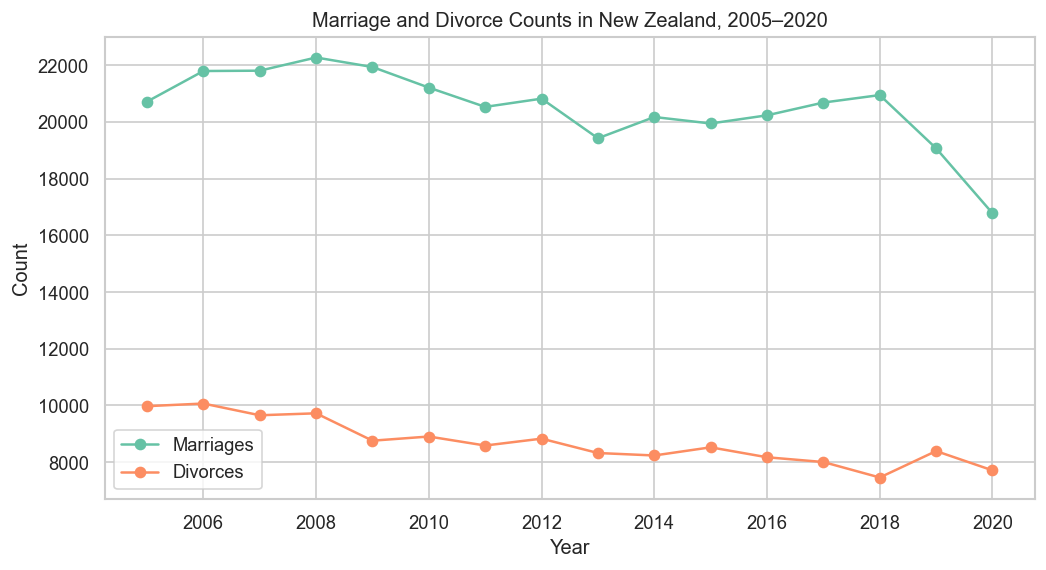

In [18]:
# ============================================================
# 3. MARRIAGE AND DIVORCE COUNT TREND
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["marriages"],
    marker="o",
    label="Marriages"
)

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["divorces"],
    marker="o",
    label="Divorces"
)

plt.title("Marriage and Divorce Counts in New Zealand, 2005–2020")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

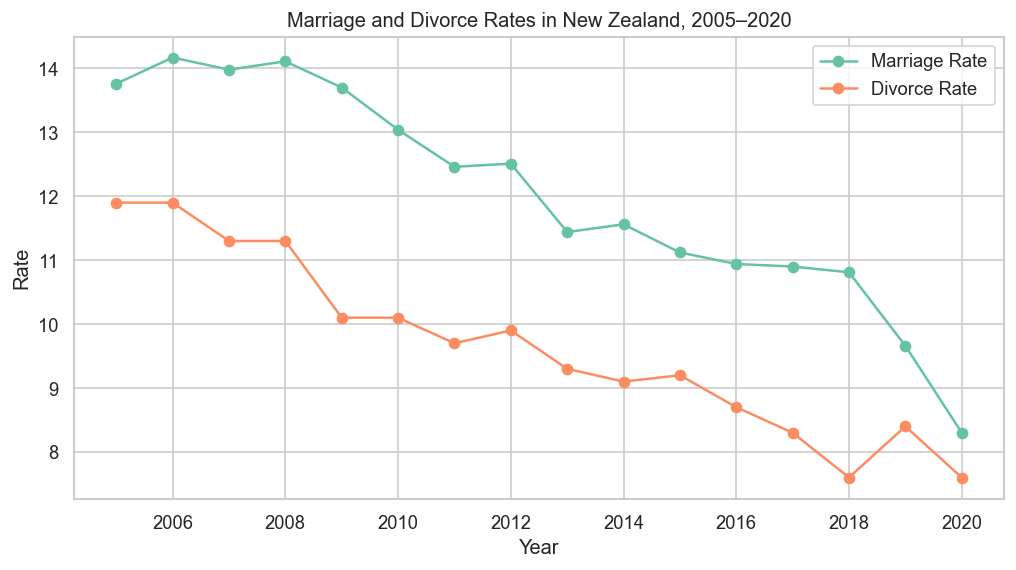

In [19]:
# ============================================================
# 4. MARRIAGE AND DIVORCE RATE TREND
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["marriage_rate"],
    marker="o",
    label="Marriage Rate"
)

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["divorce_rate"],
    marker="o",
    label="Divorce Rate"
)

plt.title("Marriage and Divorce Rates in New Zealand, 2005–2020")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()

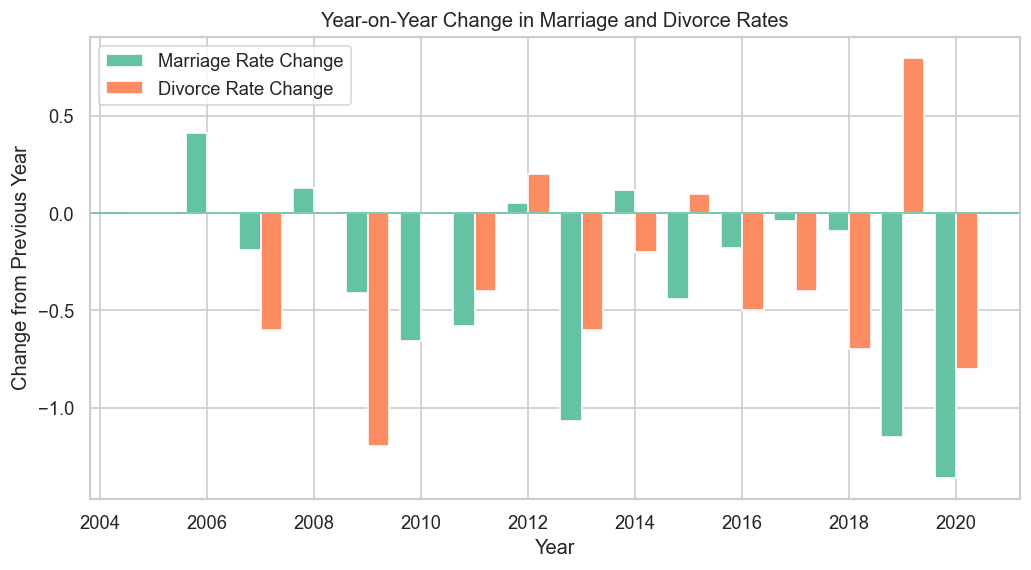

In [20]:
# ============================================================
# 5. YEAR-ON-YEAR RATE CHANGE
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    yearly_marriage_divorce_master["year"] - 0.2,
    yearly_marriage_divorce_master["marriage_rate_change"],
    width=0.4,
    label="Marriage Rate Change"
)

plt.bar(
    yearly_marriage_divorce_master["year"] + 0.2,
    yearly_marriage_divorce_master["divorce_rate_change"],
    width=0.4,
    label="Divorce Rate Change"
)

plt.axhline(0, linewidth=1)
plt.title("Year-on-Year Change in Marriage and Divorce Rates")
plt.xlabel("Year")
plt.ylabel("Change from Previous Year")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# ============================================================
# 6. IDENTIFY YEARS WITH HIGHEST INCREASE / DECREASE
# ============================================================

print("Highest marriage rate increase:")
display(
    yearly_marriage_divorce_master.sort_values(
        "marriage_rate_change",
        ascending=False
    ).head(3)
)

print("Largest marriage rate decrease:")
display(
    yearly_marriage_divorce_master.sort_values(
        "marriage_rate_change",
        ascending=True
    ).head(3)
)

print("Highest divorce rate increase:")
display(
    yearly_marriage_divorce_master.sort_values(
        "divorce_rate_change",
        ascending=False
    ).head(3)
)

print("Largest divorce rate decrease:")
display(
    yearly_marriage_divorce_master.sort_values(
        "divorce_rate_change",
        ascending=True
    ).head(3)
)



Highest marriage rate increase:


,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
1,2006,10065,21798,11.9,14.17,105.212858,100.932611,0.41,0.0
3,2008,9720,22275,11.3,14.11,107.515204,97.472924,0.13,0.0
9,2014,8232,20175,9.1,11.56,97.379091,82.551143,0.12,-0.2


Largest marriage rate decrease:


,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
15,2020,7707,16779,7.6,8.30,80.987547,77.286402,-1.36,-0.8
14,2019,8388,19071,8.4,9.66,92.050391,84.115523,-1.15,0.8
8,2013,8319,19425,9.3,11.44,93.759050,83.423586,-1.07,-0.6


Highest divorce rate increase:


,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
14,2019,8388,19071,8.4,9.66,92.050391,84.115523,-1.15,0.8
7,2012,8826,20823,9.9,12.51,100.506806,88.507822,0.05,0.2
10,2015,8520,19947,9.2,11.12,96.278598,85.439230,-0.44,0.1


Largest divorce rate decrease:


,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
4,2009,8754,21939,10.1,13.70,105.893426,87.785800,-0.41,-1.2
15,2020,7707,16779,7.6,8.30,80.987547,77.286402,-1.36,-0.8
13,2018,7455,20949,7.6,10.81,101.114972,74.759326,-0.09,-0.7


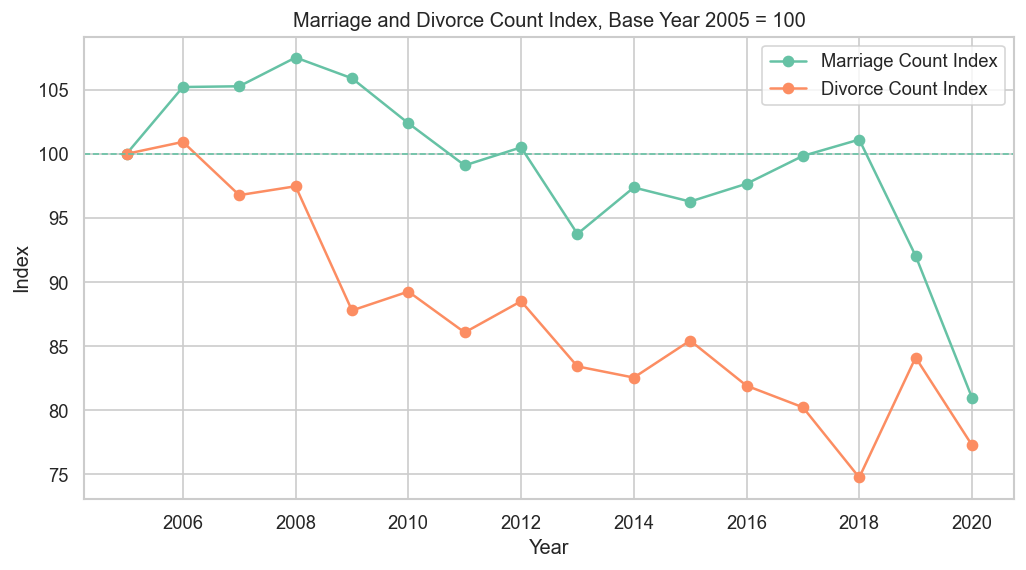

In [22]:
# ============================================================
# 7. INDEX TREND: BASE YEAR 2005 = 100
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["marriage_count_index"],
    marker="o",
    label="Marriage Count Index"
)

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["divorce_count_index"],
    marker="o",
    label="Divorce Count Index"
)

plt.axhline(100, linestyle="--", linewidth=1)

plt.title("Marriage and Divorce Count Index, Base Year 2005 = 100")
plt.xlabel("Year")
plt.ylabel("Index")
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Median Age Analysis

Median age at marriage and divorce is examined by event type, gender, and marital status. This reveals whether people are marrying or divorcing later in life over the study period, and whether gender differences in age are widening or narrowing. This section supports the demographic analysis in RQ2.

In [23]:
# ============================================================
# 8. MEDIAN AGE BY EVENT AND GENDER
# ============================================================

median_age_summary = (
    median_age_master
    .groupby(["event", "gender"])["median_age"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

display(median_age_summary)

,event,gender,count,mean,min,max
0,Divorce,Female,11,43.863636,42.5,44.5
1,Divorce,Male,11,46.381818,45.2,47.1
2,Marriage,Female,42,40.783333,28.2,60.0
3,Marriage,Male,43,44.330233,29.9,66.8


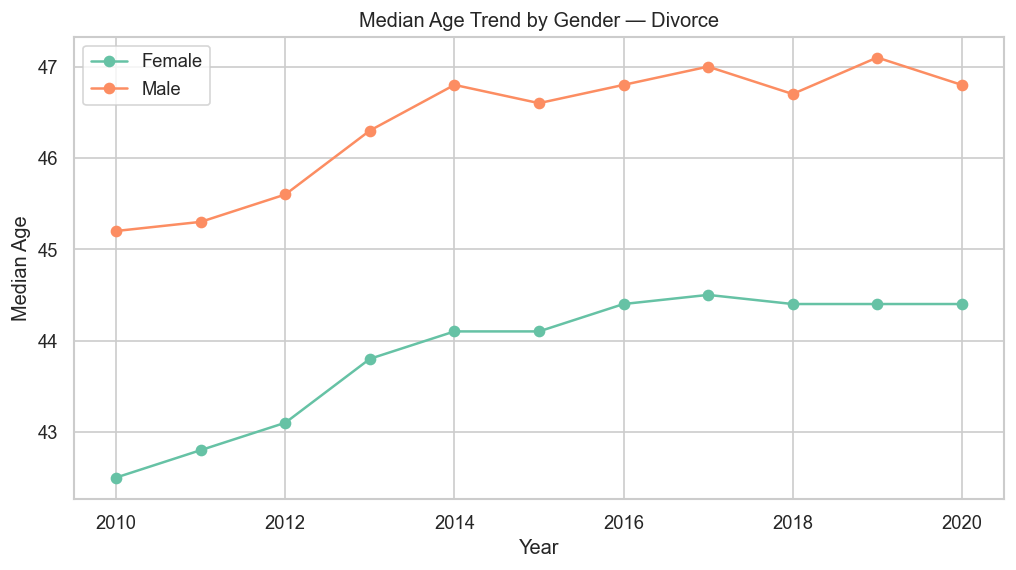

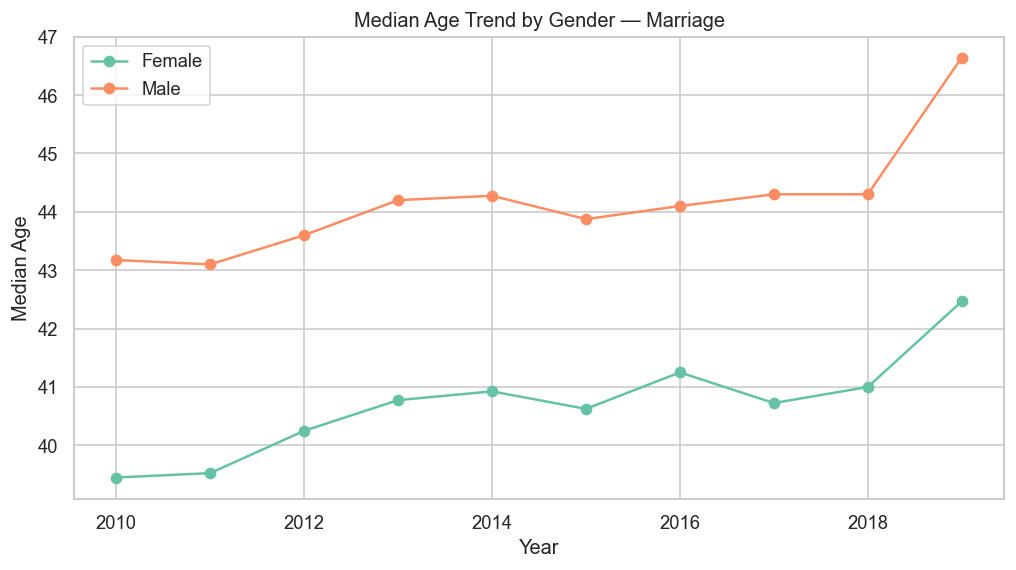

In [24]:
# ============================================================
# 9. MEDIAN AGE TREND BY EVENT AND GENDER
# ============================================================

for event_name in median_age_master["event"].unique():

    event_df = median_age_master[
        median_age_master["event"] == event_name
    ]

    plt.figure(figsize=(10, 5))

    for gender in event_df["gender"].unique():
        gender_df = event_df[event_df["gender"] == gender]

        yearly_gender_age = (
            gender_df
            .groupby("year")["median_age"]
            .mean()
            .reset_index()
        )

        plt.plot(
            yearly_gender_age["year"],
            yearly_gender_age["median_age"],
            marker="o",
            label=gender
        )

    plt.title(f"Median Age Trend by Gender — {event_name}")
    plt.xlabel("Year")
    plt.ylabel("Median Age")
    plt.legend()
    plt.grid(True)
    plt.show()

In [25]:
# ============================================================
# 10. MEDIAN AGE BY STATUS
# ============================================================

status_age_summary = (
    median_age_master
    .groupby(["event", "status"])["median_age"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
    .sort_values(["event", "mean"], ascending=[True, False])
)

display(status_age_summary)

,event,status,count,mean,min,max
0,Divorce,Not specified,22,45.122727,42.5,47.1
4,Marriage,Widowed,22,61.031818,55.4,66.8
1,Marriage,Divorced,21,47.490476,44.1,50.5
3,Marriage,Total,21,31.428571,30.0,32.5
2,Marriage,Never Married,21,29.480952,28.2,30.6


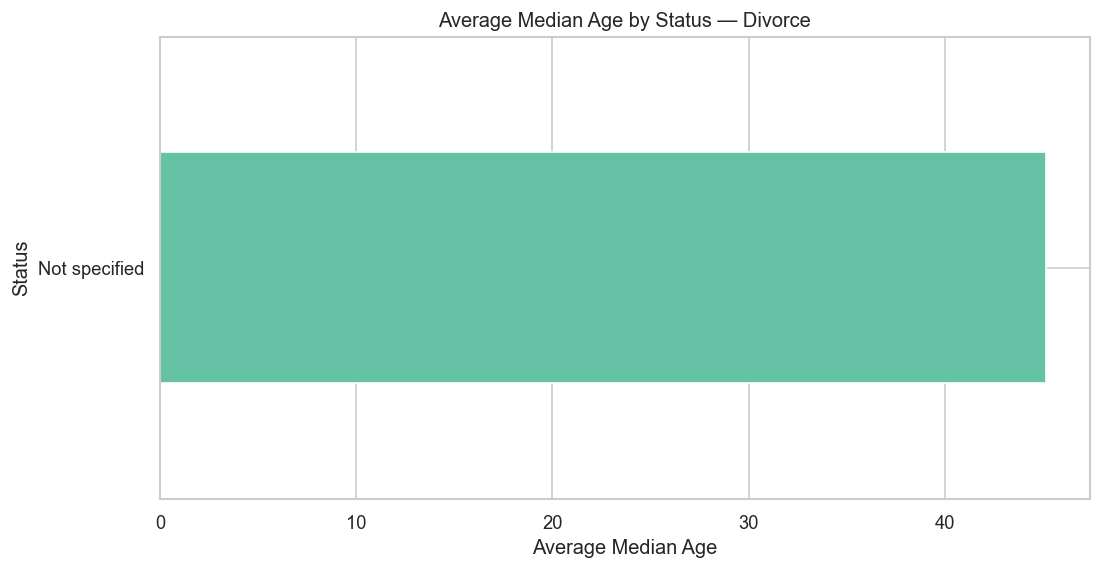

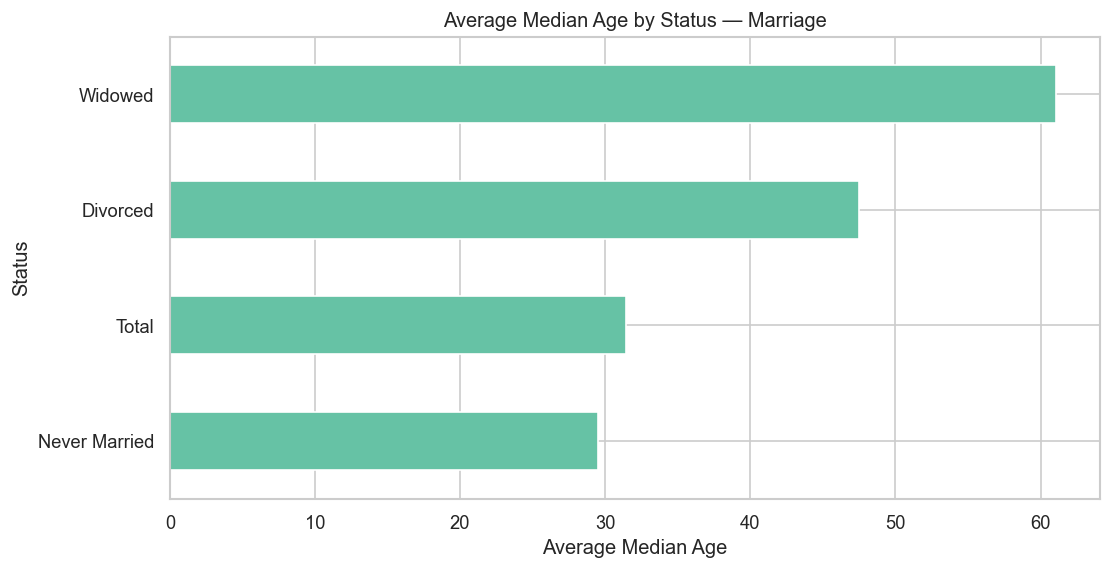

In [26]:
# ============================================================
# 11. BAR CHART: AVERAGE MEDIAN AGE BY STATUS
# ============================================================

for event_name in median_age_master["event"].unique():

    event_status = (
        median_age_master[median_age_master["event"] == event_name]
        .groupby("status")["median_age"]
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(10, 5))
    event_status.plot(kind="barh")

    plt.title(f"Average Median Age by Status — {event_name}")
    plt.xlabel("Average Median Age")
    plt.ylabel("Status")
    plt.grid(True)
    plt.show()

### 4.3 Relationship Type Analysis

Union counts by sex type and union type are examined from 2013 to 2020. This section provides context for the post-legalisation period and shows how same-sex and opposite-sex marriage and civil union categories contributed to total formal unions after the Marriage (Definition of Marriage) Amendment Act 2013 came into force.

In [27]:
# ============================================================
# 12. RELATIONSHIP TYPE SUMMARY
# ============================================================

relationship_summary = (
    relationship_detail
    .groupby(["relationship_group"])["count"]
    .agg(["sum", "mean", "min", "max"])
    .reset_index()
    .sort_values("sum", ascending=False)
)

display(relationship_summary)

,relationship_group,sum,mean,min,max
1,opposite-sex - Marriage,153321,19165.125,16347,20394
3,same-sex - Marriage,3363,420.375,210,492
0,opposite-sex - Civil Union,336,42.000,30,66
2,same-sex - Civil Union,249,31.125,15,120


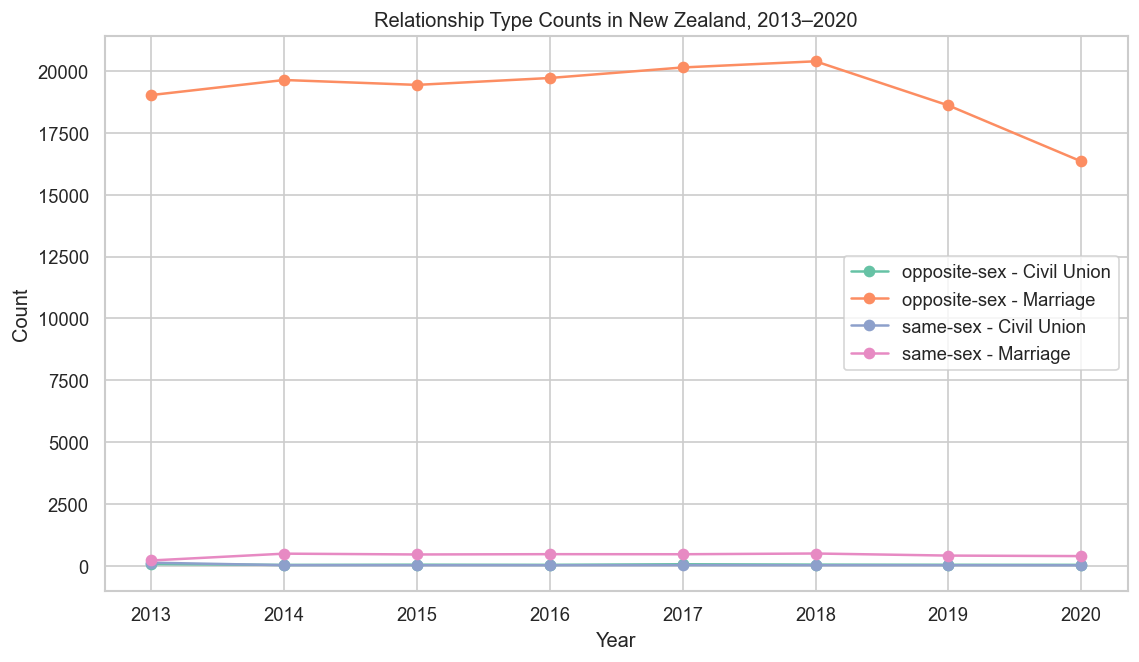

In [28]:
# ============================================================
# 13. RELATIONSHIP TYPE TREND
# ============================================================

plt.figure(figsize=(11, 6))

for group in relationship_detail["relationship_group"].unique():
    group_df = relationship_detail[
        relationship_detail["relationship_group"] == group
    ]

    plt.plot(
        group_df["year"],
        group_df["count"],
        marker="o",
        label=group
    )

plt.title("Relationship Type Counts in New Zealand, 2013–2020")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

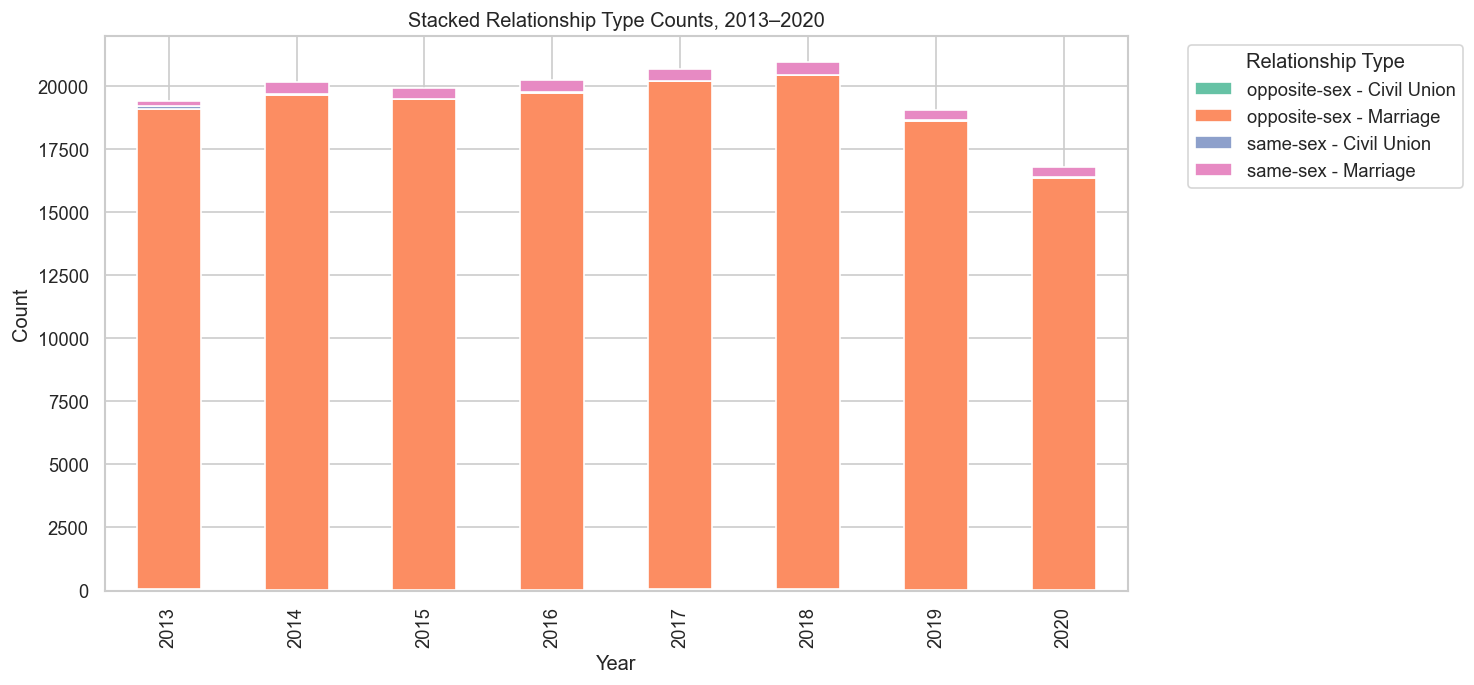

In [29]:
# ============================================================
# 15. STACKED BAR CHART: RELATIONSHIP TYPE WIDE
# ============================================================

relationship_type_wide_plot = relationship_type_wide.set_index("year")

relationship_type_wide_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Stacked Relationship Type Counts, 2013–2020")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Relationship Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [30]:
# ============================================================
# CREATE RELATIONSHIP ANALYSIS TABLES
# ============================================================

relationship_type_master = df_reltype_clean.copy()

relationship_type_master["relationship_group"] = (
    relationship_type_master["sex_type"].astype(str).str.strip()
    + " - "
    + relationship_type_master["union_type"].astype(str).str.strip()
)

relationship_detail = relationship_type_master[
    relationship_type_master["sex_type"] != "total"
].copy()

relationship_total = relationship_type_master[
    relationship_type_master["sex_type"] == "total"
].copy()

relationship_detail["year_total"] = relationship_detail.groupby(
    "year"
)["count"].transform("sum")

relationship_detail["percentage_share"] = (
    relationship_detail["count"] /
    relationship_detail["year_total"] *
    100
)

relationship_detail = (
    relationship_detail
    .sort_values(["year", "sex_type", "union_type"])
    .reset_index(drop=True)
)

relationship_total = (
    relationship_total
    .sort_values(["year", "union_type"])
    .reset_index(drop=True)
)

In [31]:
# ============================================================
# 16. LEGAL THEME DISTRIBUTION
# ============================================================

legal_theme_counts = (
    legal_text_master["legal_theme"]
    .value_counts()
    .reset_index()
)

legal_theme_counts.columns = ["legal_theme", "count"]

display(legal_theme_counts)

,legal_theme,count
0,Property division,5
1,Court process,4
2,General legal context,2
3,Divorce requirement / barrier,1
4,Children / parenting context,1
5,Safety / family violence,1


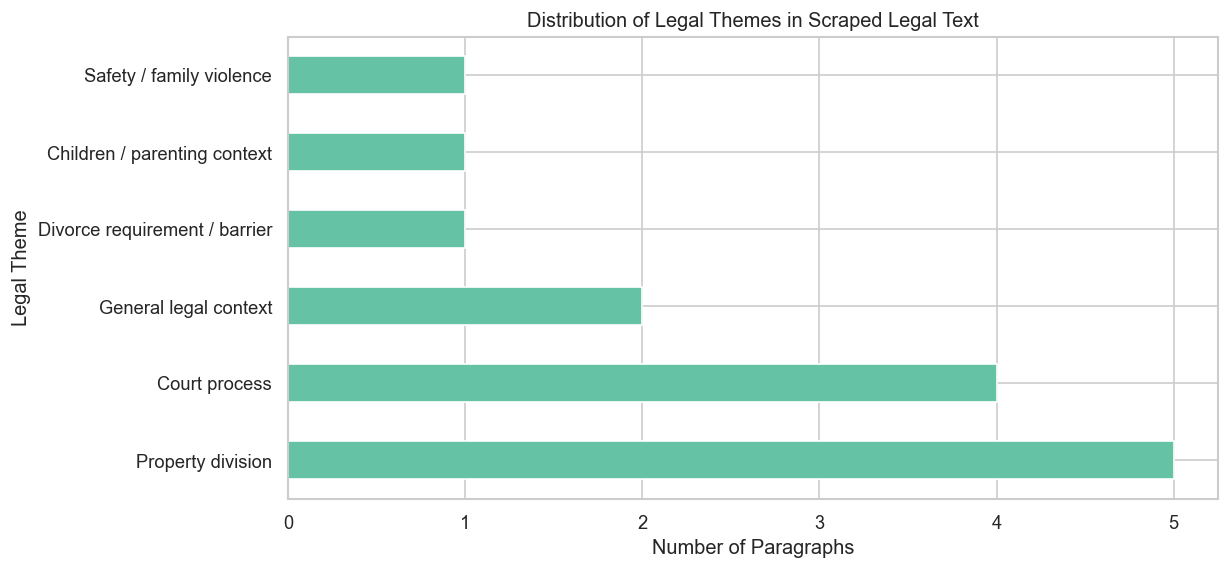

In [32]:
# ============================================================
# 17. LEGAL THEME BAR CHART
# ============================================================

plt.figure(figsize=(10, 5))

legal_text_master["legal_theme"].value_counts().plot(kind="barh")

plt.title("Distribution of Legal Themes in Scraped Legal Text")
plt.xlabel("Number of Paragraphs")
plt.ylabel("Legal Theme")
plt.grid(True)
plt.show()

In [33]:
# ============================================================
# 18. LEGISLATION REFERENCES FREQUENCY
# ============================================================

legislation_counts = (
    legal_text_master["legislation_refs"]
    .astype(str)
    .value_counts()
    .reset_index()
)

legislation_counts.columns = ["legislation_refs", "count"]

display(legislation_counts)

,legislation_refs,count
0,"Family Proceedings Act 1980, Property (Relatio...",8
1,Property (Relationships) Act 1976,4
2,Family Proceedings Act 1980,2


,text_length,word_count
count,14.000000,14.000000
mean,236.428571,41.000000
std,154.104717,25.896243
min,44.000000,7.000000
25%,154.250000,28.250000
50%,201.500000,37.500000
75%,295.750000,50.500000
max,581.000000,97.000000


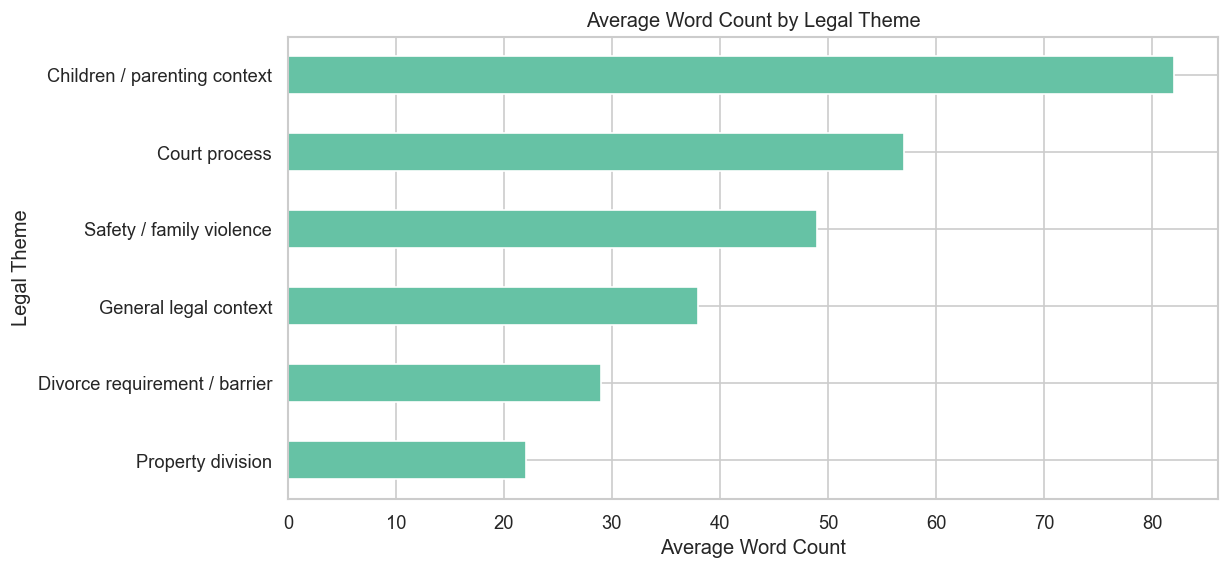

In [34]:
# ============================================================
# 19. TEXT LENGTH ANALYSIS
# ============================================================

legal_text_master["text_length"] = legal_text_master["text"].astype(str).str.len()
legal_text_master["word_count"] = legal_text_master["text"].astype(str).str.split().str.len()

display(
    legal_text_master[
        ["legal_theme", "text_length", "word_count"]
    ].describe()
)

plt.figure(figsize=(10, 5))

legal_text_master.groupby("legal_theme")["word_count"].mean().sort_values().plot(
    kind="barh"
)

plt.title("Average Word Count by Legal Theme")
plt.xlabel("Average Word Count")
plt.ylabel("Legal Theme")
plt.grid(True)
plt.show()

### 4.5 Data Analysis — Gapminder Demographic Indicators

The three NZ demographic indicators retrieved from the Gapminder API are analysed
here to understand how life expectancy and mortality have changed over the study
period. These indicators contextualise marriage and divorce trends:

- Rising **female life expectancy** extends the period during which divorce is
  demographically possible, potentially contributing to higher later-life divorce rates.
- The **life expectancy gender gap** (female minus male) relates to widowhood
  demographics and may influence remarriage patterns.
- **Crude death rate** tracks overall population mortality across the same years
  as the marriage and divorce data, providing a demographic baseline.

In [35]:
# ============================================================
# CREATE GAPMINDER MASTER TABLE
# ============================================================

api_data_master = df_api_clean.copy()

# Standardise column names again for safety
api_data_master.columns = (
    api_data_master.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Rename time to year if needed
if "time" in api_data_master.columns and "year" not in api_data_master.columns:
    api_data_master = api_data_master.rename(columns={"time": "year"})

# Convert year to integer
if "year" in api_data_master.columns:
    api_data_master["year"] = pd.to_numeric(
        api_data_master["year"],
        errors="coerce"
    )

    api_data_master = api_data_master.dropna(subset=["year"])
    api_data_master["year"] = api_data_master["year"].astype(int)

# Convert indicator columns to numeric
indicator_cols = [
    "life_expectancy_female",
    "life_expectancy_male",
    "crude_death_rate"
]

for col in indicator_cols:
    if col in api_data_master.columns:
        api_data_master[col] = pd.to_numeric(
            api_data_master[col],
            errors="coerce"
        )

# Create gender gap column only if both life expectancy columns exist
if (
    "life_expectancy_female" in api_data_master.columns
    and "life_expectancy_male" in api_data_master.columns
):
    api_data_master["life_exp_gender_gap"] = (
        api_data_master["life_expectancy_female"]
        - api_data_master["life_expectancy_male"]
    )
else:
    print("Cannot create life_exp_gender_gap because life expectancy columns are missing.")

# Sort table
if "year" in api_data_master.columns:
    api_data_master = (
        api_data_master
        .sort_values("year")
        .reset_index(drop=True)
    )

print("api_data_master created successfully.")
print("Shape:", api_data_master.shape)
print("Columns:", api_data_master.columns.tolist())

display(api_data_master.head())

api_data_master created successfully.
Shape: (18, 6)
Columns: ['geo', 'year', 'life_expectancy_female', 'life_expectancy_male', 'crude_death_rate', 'life_exp_gender_gap']


,geo,year,life_expectancy_female,life_expectancy_male,crude_death_rate,life_exp_gender_gap
0,nzl,2005,82.106,77.840,6.631,4.266
1,nzl,2006,82.015,77.917,6.835,4.098
2,nzl,2007,82.165,77.993,6.832,4.172
3,nzl,2008,82.233,78.183,6.934,4.050
4,nzl,2009,82.481,78.526,6.823,3.955


In [36]:
# ============================================================
# 20. GAPMINDER DATA — TREND OVERVIEW
# ============================================================

print("Gapminder API data overview:")

required_cols = [
    "year",
    "life_expectancy_female",
    "life_expectancy_male",
    "crude_death_rate",
    "life_exp_gender_gap"
]

available_cols = [
    col for col in required_cols
    if col in api_data_master.columns
]

missing_cols = [
    col for col in required_cols
    if col not in api_data_master.columns
]

if missing_cols:
    print("Missing columns:")
    print(missing_cols)

print("\nAvailable columns used:")
print(available_cols)

if len(available_cols) > 0:
    display(api_data_master[available_cols])
else:
    print("No required Gapminder columns are available.")

# Descriptive statistics
numeric_cols = [
    col for col in [
        "life_expectancy_female",
        "life_expectancy_male",
        "crude_death_rate",
        "life_exp_gender_gap"
    ]
    if col in api_data_master.columns
]

print("\nDescriptive statistics:")

if len(numeric_cols) > 0:
    display(api_data_master[numeric_cols].describe().round(3))
else:
    print("No numeric Gapminder indicator columns available for descriptive statistics.")

Gapminder API data overview:

Available columns used:
['year', 'life_expectancy_female', 'life_expectancy_male', 'crude_death_rate', 'life_exp_gender_gap']


,year,life_expectancy_female,life_expectancy_male,crude_death_rate,life_exp_gender_gap
0,2005,82.106,77.840,6.631,4.266
1,2006,82.015,77.917,6.835,4.098
2,2007,82.165,77.993,6.832,4.172
3,2008,82.233,78.183,6.934,4.050
4,2009,82.481,78.526,6.823,3.955
5,2010,82.927,79.093,6.632,3.834
6,2011,82.587,79.027,6.971,3.560
7,2012,83.023,79.254,6.914,3.769
8,2013,83.402,79.762,6.692,3.640
9,2014,83.189,79.570,6.942,3.619



Descriptive statistics:


,life_expectancy_female,life_expectancy_male,crude_death_rate,life_exp_gender_gap
count,18.000,18.000,18.000,18.000
mean,83.038,79.343,6.881,3.695
std,0.707,0.930,0.317,0.314
min,82.015,77.840,6.458,3.116
25%,82.508,78.651,6.725,3.482
50%,83.106,79.521,6.864,3.633
75%,83.553,79.982,6.929,3.925
max,84.464,80.838,8.012,4.266


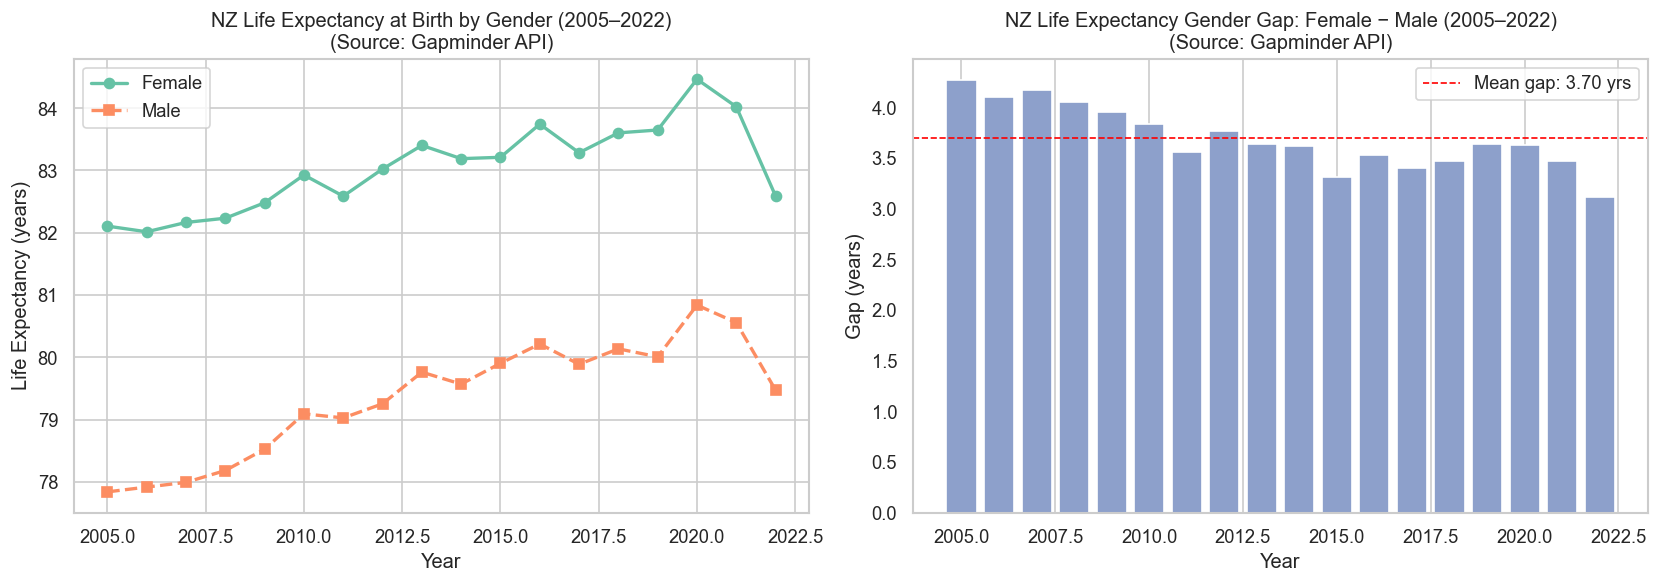

In [37]:
# ============================================================
# 21. LIFE EXPECTANCY TRENDS — MALE VS FEMALE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: life expectancy by gender
axes[0].plot(api_data_master["year"], api_data_master["life_expectancy_female"],
             marker="o", label="Female", linewidth=2)
axes[0].plot(api_data_master["year"], api_data_master["life_expectancy_male"],
             marker="s", linestyle="--", label="Male", linewidth=2)
axes[0].set_title("NZ Life Expectancy at Birth by Gender (2005–2022)\n(Source: Gapminder API)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Life Expectancy (years)")
axes[0].legend()
axes[0].grid(True)

# Right: gender gap in life expectancy
axes[1].bar(api_data_master["year"], api_data_master["life_exp_gender_gap"],
            color=PALETTE[2])
axes[1].set_title("NZ Life Expectancy Gender Gap: Female − Male (2005–2022)\n(Source: Gapminder API)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Gap (years)")
axes[1].axhline(api_data_master["life_exp_gender_gap"].mean(), linestyle="--",
                color="red", linewidth=1, label=f'Mean gap: {api_data_master["life_exp_gender_gap"].mean():.2f} yrs')
axes[1].legend()
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

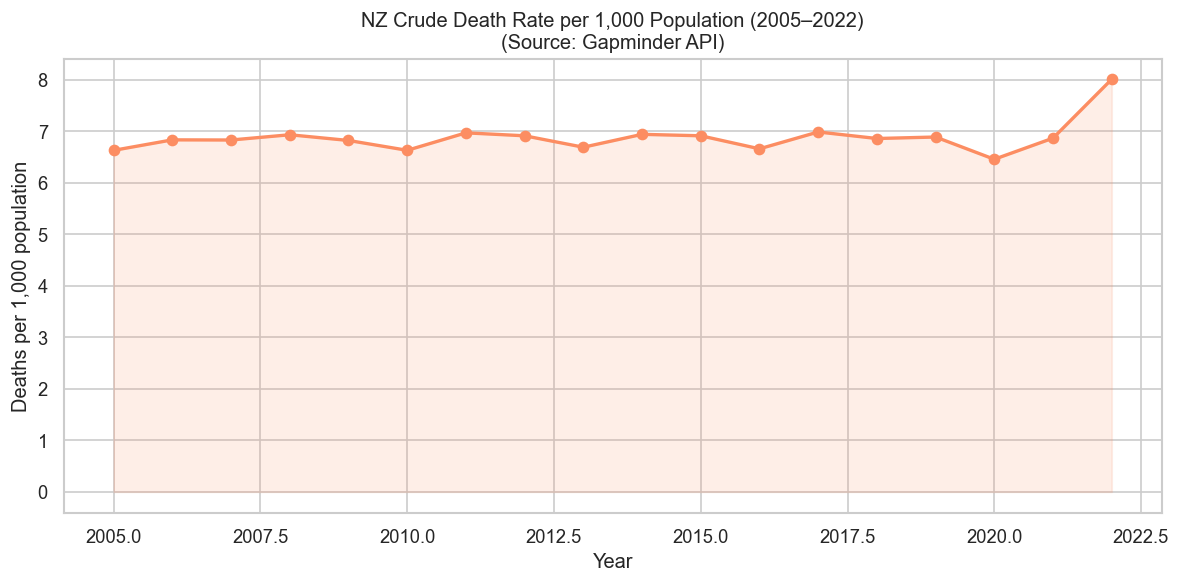

Mean crude death rate 2005–2022: 6.881
Min: 6.458 (2020)
Max: 8.012 (2022)


In [38]:
# ============================================================
# 22. CRUDE DEATH RATE TREND
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(api_data_master["year"], api_data_master["crude_death_rate"],
         marker="o", linewidth=2, color=PALETTE[1])
plt.fill_between(api_data_master["year"], api_data_master["crude_death_rate"],
                 alpha=0.15, color=PALETTE[1])
plt.title("NZ Crude Death Rate per 1,000 Population (2005–2022)\n(Source: Gapminder API)")
plt.xlabel("Year")
plt.ylabel("Deaths per 1,000 population")
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary stats
print(f"Mean crude death rate 2005–2022: {api_data_master['crude_death_rate'].mean():.3f}")
print(f"Min: {api_data_master['crude_death_rate'].min():.3f} ({int(api_data_master.loc[api_data_master['crude_death_rate'].idxmin(),'year'])})")
print(f"Max: {api_data_master['crude_death_rate'].max():.3f} ({int(api_data_master.loc[api_data_master['crude_death_rate'].idxmax(),'year'])})")

Merged dataset shape: (16, 13)


,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change,life_expectancy_female,life_expectancy_male,crude_death_rate,life_exp_gender_gap
0,2005,9972,20718,11.9,13.76,100.000000,100.000000,0.00,0.0,82.106,77.840,6.631,4.266
1,2006,10065,21798,11.9,14.17,105.212858,100.932611,0.41,0.0,82.015,77.917,6.835,4.098
2,2007,9651,21810,11.3,13.98,105.270779,96.780987,-0.19,-0.6,82.165,77.993,6.832,4.172
3,2008,9720,22275,11.3,14.11,107.515204,97.472924,0.13,0.0,82.233,78.183,6.934,4.050
4,2009,8754,21939,10.1,13.70,105.893426,87.785800,-0.41,-1.2,82.481,78.526,6.823,3.955



Correlation matrix (Gapminder indicators vs divorce/marriage rates):


,divorce_rate,life_expectancy_female,life_expectancy_male,crude_death_rate,life_exp_gender_gap
divorce_rate,1.000,-0.931,-0.962,0.061,0.864
life_expectancy_female,-0.931,1.000,0.979,-0.333,-0.752
life_expectancy_male,-0.962,0.979,1.000,-0.184,-0.870
crude_death_rate,0.061,-0.333,-0.184,1.000,-0.210
life_exp_gender_gap,0.864,-0.752,-0.870,-0.210,1.000


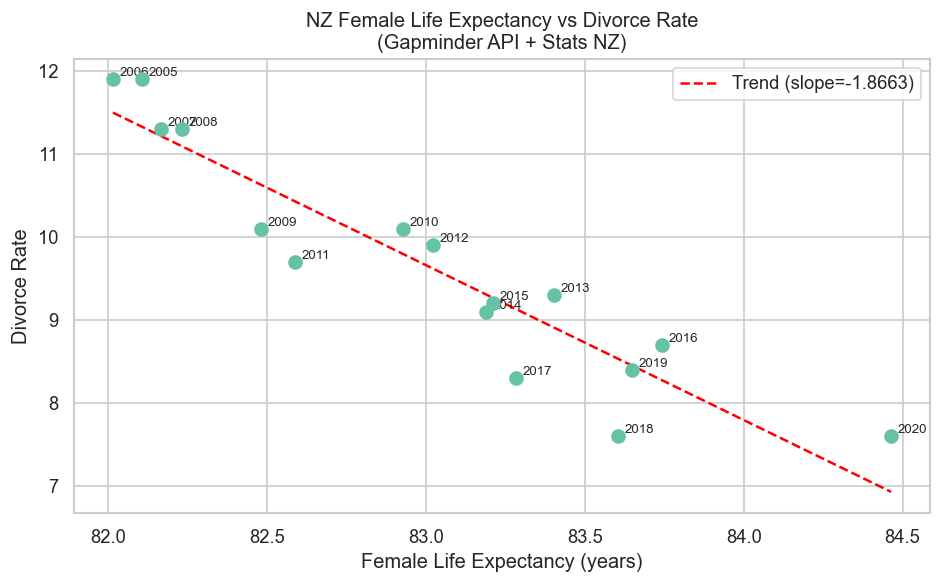

In [39]:
# ============================================================
# 23. CORRELATION: GAPMINDER INDICATORS vs DIVORCE RATE
# Merge API data with yearly master to explore relationships
# ============================================================

# Merge Gapminder wide with the yearly marriage/divorce master
api_merged = yearly_marriage_divorce_master.merge(
    api_data_master[["year","life_expectancy_female","life_expectancy_male",
                     "crude_death_rate","life_exp_gender_gap"]],
    on="year", how="inner"
)

print(f"Merged dataset shape: {api_merged.shape}")
display(api_merged.head())

# Correlation of Gapminder indicators with divorce rate
corr_cols = ["divorce_rate","life_expectancy_female","life_expectancy_male",
             "crude_death_rate","life_exp_gender_gap"]
api_corr = api_merged[corr_cols].corr().round(3)

print("\nCorrelation matrix (Gapminder indicators vs divorce/marriage rates):")
display(api_corr)

# Scatter: life expectancy female vs divorce rate
plt.figure(figsize=(8, 5))
plt.scatter(api_merged["life_expectancy_female"], api_merged["divorce_rate"],
            zorder=5, color=PALETTE[0], s=60)
for _, row in api_merged.iterrows():
    plt.annotate(str(int(row["year"])),
                 (row["life_expectancy_female"], row["divorce_rate"]),
                 textcoords="offset points", xytext=(4, 2), fontsize=8)
m, b = pd.np.polyfit(api_merged["life_expectancy_female"],
                     api_merged["divorce_rate"], 1) if hasattr(pd,'np') else        __import__('numpy').polyfit(api_merged["life_expectancy_female"],
                                   api_merged["divorce_rate"], 1)
x_line = __import__('numpy').linspace(api_merged["life_expectancy_female"].min(),
                                       api_merged["life_expectancy_female"].max(), 100)
plt.plot(x_line, m*x_line+b, linestyle="--", linewidth=1.5, color="red",
         label=f"Trend (slope={m:.4f})")
plt.title("NZ Female Life Expectancy vs Divorce Rate\n(Gapminder API + Stats NZ)")
plt.xlabel("Female Life Expectancy (years)")
plt.ylabel("Divorce Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.6 Correlation Analysis

A correlation matrix is computed across all numeric indicators in the yearly marriage and divorce master dataset to identify which variables move together. A Matplotlib heatmap visualises the strength and direction of pairwise correlations. This helps confirm or challenge assumptions about the relationship between marriage and divorce indicators before the formal RQ4 analysis.

In [40]:
# ============================================================
# 24. CORRELATION ANALYSIS: MARRIAGE AND DIVORCE MASTER
# ============================================================

correlation_columns = [
    "divorces",
    "marriages",
    "divorce_rate",
    "marriage_rate",
    "marriage_count_index",
    "divorce_count_index",
    "marriage_rate_change",
    "divorce_rate_change"
]

correlation_matrix = yearly_marriage_divorce_master[correlation_columns].corr()

display(correlation_matrix)

,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change
divorces,1.000000,0.606478,0.981849,0.849519,0.606478,1.000000,0.471560,0.304202
marriages,0.606478,1.000000,0.669119,0.884428,1.000000,0.606478,0.746856,-0.013282
divorce_rate,0.981849,0.669119,1.000000,0.916739,0.669119,0.981849,0.513041,0.185728
marriage_rate,0.849519,0.884428,0.916739,1.000000,0.884428,0.849519,0.631919,0.003275
marriage_count_index,0.606478,1.000000,0.669119,0.884428,1.000000,0.606478,0.746856,-0.013282
divorce_count_index,1.000000,0.606478,0.981849,0.849519,0.606478,1.000000,0.471560,0.304202
marriage_rate_change,0.471560,0.746856,0.513041,0.631919,0.746856,0.471560,1.000000,0.080017
divorce_rate_change,0.304202,-0.013282,0.185728,0.003275,-0.013282,0.304202,0.080017,1.000000


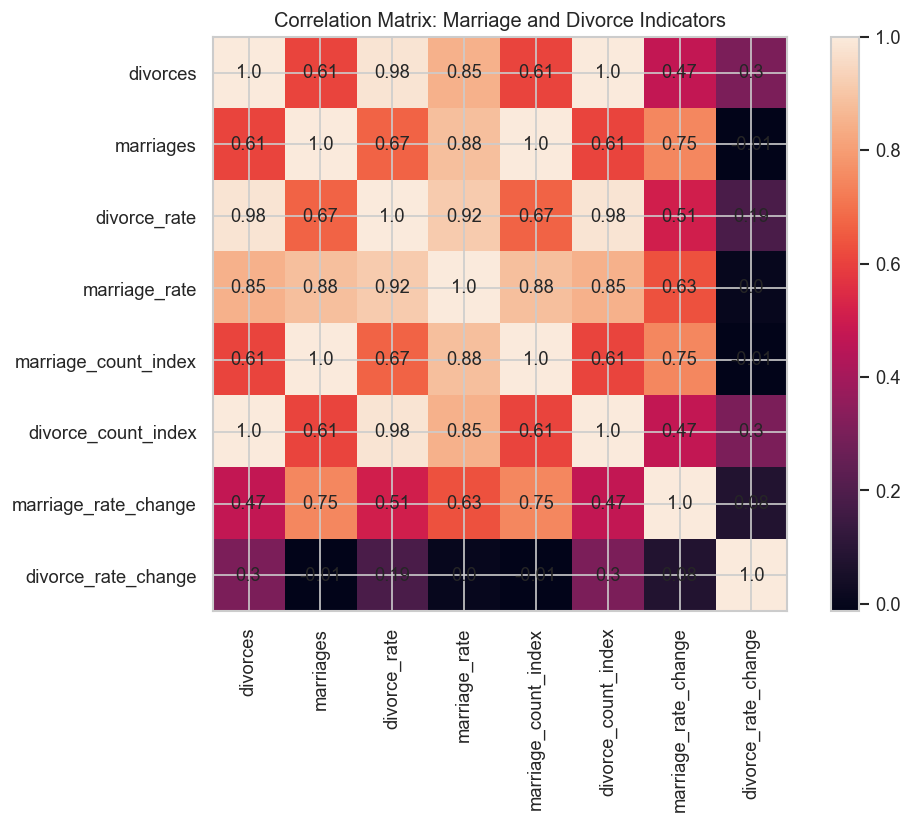

In [41]:
# ============================================================
# 25. CORRELATION HEATMAP USING MATPLOTLIB
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix: Marriage and Divorce Indicators")

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            round(correlation_matrix.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# 26. COMBINED YEARLY ANALYTICAL TABLE
# Merge relationship-wide data with yearly marriage/divorce master
# ============================================================

combined_yearly_eda = yearly_marriage_divorce_master.merge(
    relationship_type_wide,
    on="year",
    how="left"
)

display(combined_yearly_eda.head())

print("Combined yearly EDA shape:")
print(combined_yearly_eda.shape)

,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change,opposite-sex - Civil Union,opposite-sex - Marriage,same-sex - Civil Union,same-sex - Marriage
0,2005,9972,20718,11.9,13.76,100.000000,100.000000,0.00,0.0,NaN,NaN,NaN,NaN
1,2006,10065,21798,11.9,14.17,105.212858,100.932611,0.41,0.0,NaN,NaN,NaN,NaN
2,2007,9651,21810,11.3,13.98,105.270779,96.780987,-0.19,-0.6,NaN,NaN,NaN,NaN
3,2008,9720,22275,11.3,14.11,107.515204,97.472924,0.13,0.0,NaN,NaN,NaN,NaN
4,2009,8754,21939,10.1,13.70,105.893426,87.785800,-0.41,-1.2,NaN,NaN,NaN,NaN


Combined yearly EDA shape:
(16, 13)


In [43]:
# ============================================================
# 27. CORRELATION AFTER ADDING RELATIONSHIP TYPE VARIABLES
# ============================================================

combined_numeric_cols = combined_yearly_eda.select_dtypes(
    include=["int64", "float64"]
).columns

combined_correlation = combined_yearly_eda[combined_numeric_cols].corr()

display(combined_correlation)

,year,divorces,marriages,divorce_rate,marriage_rate,marriage_count_index,divorce_count_index,marriage_rate_change,divorce_rate_change,opposite-sex - Civil Union,opposite-sex - Marriage,same-sex - Civil Union,same-sex - Marriage
year,1.000000,-0.915564,-0.725126,-0.972856,-0.960007,-0.725126,-0.915564,-0.515959,-0.016095,-0.381881,-0.472549,-0.605721,0.303951
divorces,-0.915564,1.000000,0.606478,0.981849,0.849519,0.606478,1.000000,0.471560,0.304202,0.065331,0.075947,0.261528,-0.263330
marriages,-0.725126,0.606478,1.000000,0.669119,0.884428,1.000000,0.606478,0.746856,-0.013282,0.228606,0.999534,-0.031805,0.419626
divorce_rate,-0.972856,0.981849,0.669119,1.000000,0.916739,0.669119,0.981849,0.513041,0.185728,0.227466,0.293644,0.487298,-0.317391
marriage_rate,-0.960007,0.849519,0.884428,0.916739,1.000000,0.884428,0.849519,0.631919,0.003275,0.356067,0.846782,0.354450,0.048713
marriage_count_index,-0.725126,0.606478,1.000000,0.669119,0.884428,1.000000,0.606478,0.746856,-0.013282,0.228606,0.999534,-0.031805,0.419626
divorce_count_index,-0.915564,1.000000,0.606478,0.981849,0.849519,0.606478,1.000000,0.471560,0.304202,0.065331,0.075947,0.261528,-0.263330
marriage_rate_change,-0.515959,0.471560,0.746856,0.513041,0.631919,0.746856,0.471560,1.000000,0.080017,-0.108361,0.833276,-0.339696,0.699223
divorce_rate_change,-0.016095,0.304202,-0.013282,0.185728,0.003275,-0.013282,0.304202,0.080017,1.000000,-0.241847,0.063080,-0.230155,0.129796
opposite-sex - Civil Union,-0.381881,0.065331,0.228606,0.227466,0.356067,0.228606,0.065331,-0.108361,-0.241847,1.000000,0.250573,0.769187,-0.643284


In [44]:

# ============================================================
# EXPORT EDA SUMMARY FILES
# ============================================================

yearly_marriage_divorce_master.describe().to_csv(
    "eda_summary_yearly_marriage_divorce.csv"
)

median_age_summary.to_csv(
    "eda_summary_median_age_by_event_gender.csv",
    index=False
)

status_age_summary.to_csv(
    "eda_summary_median_age_by_status.csv",
    index=False
)

relationship_summary.to_csv(
    "eda_summary_relationship_type.csv",
    index=False
)

legal_theme_counts.to_csv(
    "eda_summary_legal_theme_counts.csv",
    index=False
)

# Gapminder API summary
api_indicator_cols = [
    "life_expectancy_female",
    "life_expectancy_male",
    "crude_death_rate",
    "life_exp_gender_gap"
]

available_api_indicator_cols = [
    col for col in api_indicator_cols
    if col in api_data_master.columns
]

if len(available_api_indicator_cols) > 0:
    api_gapminder_summary = (
        api_data_master[available_api_indicator_cols]
        .describe()
        .round(3)
    )

    api_gapminder_summary.to_csv(
        "eda_summary_gapminder_api.csv"
    )

    print("Gapminder API summary exported.")
else:
    print("No Gapminder API indicator columns available to export.")

combined_yearly_eda.to_csv(
    "combined_yearly_eda_master.csv",
    index=False
)

print("EDA summary files exported successfully.")

Gapminder API summary exported.
EDA summary files exported successfully.


In [45]:
# ============================================================
# EDA COMPLETION MESSAGE
# ============================================================

print("=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

print("Main EDA areas completed:")
print("1. Descriptive statistics")
print("2. Marriage and divorce count trends")
print("3. Marriage and divorce rate trends")
print("4. Year-on-year change analysis")
print("5. Index-based trend analysis")
print("6. Median age analysis by gender and event type")
print("7. Median age analysis by status before marriage")
print("8. Relationship type and percentage-share analysis")
print("9. Legal theme analysis")
print("10. Gapminder API indicator analysis")
print("    - Female life expectancy")
print("    - Male life expectancy")
print("    - Crude death rate")
print("    - Life expectancy gender gap")
print("11. Correlation analysis")
print("12. EDA summary exports")

print("=" * 70)
print("All cleaned and integrated datasets are ready for interpretation and reporting.")
print("=" * 70)

EDA COMPLETED SUCCESSFULLY
Main EDA areas completed:
1. Descriptive statistics
2. Marriage and divorce count trends
3. Marriage and divorce rate trends
4. Year-on-year change analysis
5. Index-based trend analysis
6. Median age analysis by gender and event type
7. Median age analysis by status before marriage
8. Relationship type and percentage-share analysis
9. Legal theme analysis
10. Gapminder API indicator analysis
    - Female life expectancy
    - Male life expectancy
    - Crude death rate
    - Life expectancy gender gap
11. Correlation analysis
12. EDA summary exports
All cleaned and integrated datasets are ready for interpretation and reporting.


### Cross-Tabulation Analysis

Cross-tabulation (`pd.crosstab`) is applied to examine the frequency distribution of categorical relationship and demographic variables. Three cross-tabulations are produced:

1. **Union type × Sex type** — counts of relationship categories across the 2013–2020 period.
2. **Median age bracket × Gender** — frequency of age brackets by gender for marriage events.
3. **Legal theme × Source title** — frequency of legal themes across scraped sources.

Cross-tabulation complements pivot tables by providing normalised frequency views and percentage margins, which are useful for comparing proportional distributions.

Cross-tabulation 1: Union Type × Sex Type (total counts, 2013–2020)


sex_type,opposite-sex,same-sex,Total
union_type,,,
civil union,336,249,585
marriage,153321,3363,156684
Total,153657,3612,157269



Row-normalised (% of each union type by sex type):


sex_type,opposite-sex,same-sex
union_type,,
civil union,57.44,42.56
marriage,97.85,2.15


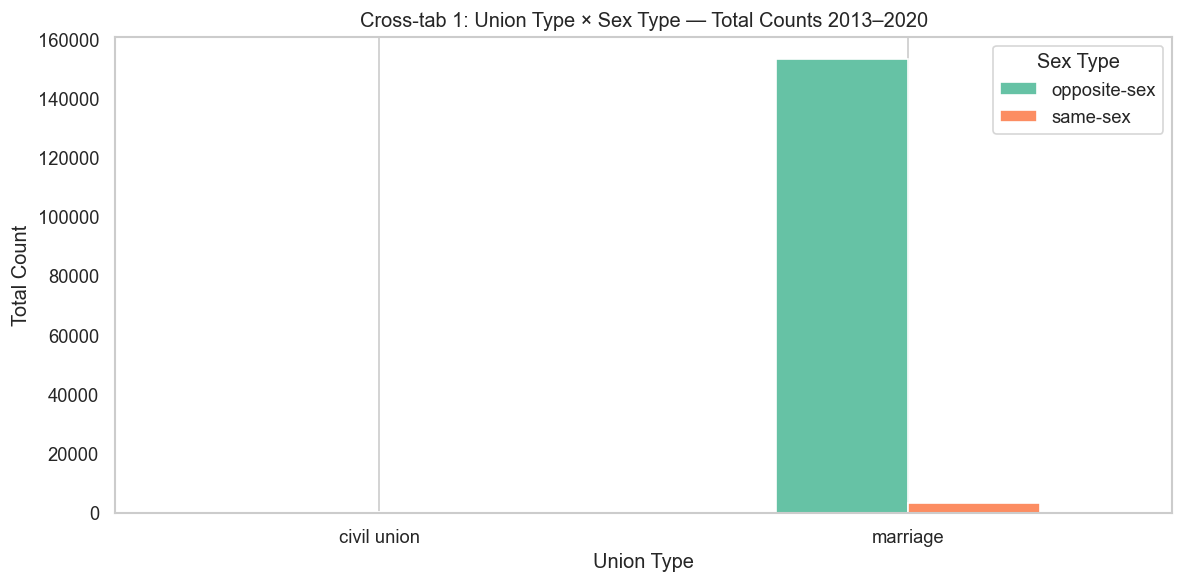

In [46]:

# ============================================================
# CROSS-TABULATION 1: UNION TYPE × SEX TYPE
# ============================================================

# Make a safe copy
ct_data = relationship_detail.copy()

# Standardise column names just in case
ct_data.columns = (
    ct_data.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Check required columns
required_cols = ["year", "union_type", "sex_type", "count"]

missing_cols = [
    col for col in required_cols
    if col not in ct_data.columns
]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

# Clean values
ct_data["year"] = pd.to_numeric(ct_data["year"], errors="coerce")
ct_data["count"] = pd.to_numeric(ct_data["count"], errors="coerce")

ct_data["union_type"] = (
    ct_data["union_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

ct_data["sex_type"] = (
    ct_data["sex_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Filter study period
ct_data = ct_data[
    (ct_data["year"] >= 2013) &
    (ct_data["year"] <= 2020)
].copy()

# Remove total rows if they exist
ct_data = ct_data[
    ct_data["sex_type"] != "total"
].copy()

# Drop missing rows
ct_data = ct_data.dropna(
    subset=["year", "union_type", "sex_type", "count"]
)

# ============================================================
# CREATE CROSS-TAB
# ============================================================

ct1 = pd.crosstab(
    index=ct_data["union_type"],
    columns=ct_data["sex_type"],
    values=ct_data["count"],
    aggfunc="sum",
    margins=True,
    margins_name="Total"
).fillna(0)

print("Cross-tabulation 1: Union Type × Sex Type (total counts, 2013–2020)")
display(ct1)

# ============================================================
# ROW-NORMALISED VERSION
# ============================================================

ct1_norm = pd.crosstab(
    index=ct_data["union_type"],
    columns=ct_data["sex_type"],
    values=ct_data["count"],
    aggfunc="sum",
    normalize="index"
).fillna(0)

ct1_norm = (ct1_norm * 100).round(2)

print("\nRow-normalised (% of each union type by sex type):")
display(ct1_norm)

# ============================================================
# VISUALISATION
# ============================================================

ct1_plot = (
    ct1
    .drop(index="Total", errors="ignore")
    .drop(columns="Total", errors="ignore")
)

if ct1_plot.empty:
    print("No data available to plot.")
else:
    ax = ct1_plot.plot(
        kind="bar",
        figsize=(10, 5),
        rot=0
    )

    plt.title("Cross-tab 1: Union Type × Sex Type — Total Counts 2013–2020")
    plt.xlabel("Union Type")
    plt.ylabel("Total Count")
    plt.legend(title="Sex Type")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

Cross-tabulation 2: Age Bracket × Gender — Marriage Events


gender,Female,Male,Total
age_bracket,,,
25–30,11,2,13
30–35,10,19,29
40–45,3,0,3
45–50,7,6,13
Total,31,27,58



Row-normalised (% Male vs Female within each age bracket):


gender,Female,Male
age_bracket,,
25–30,84.62,15.38
30–35,34.48,65.52
40–45,100.00,0.00
45–50,53.85,46.15


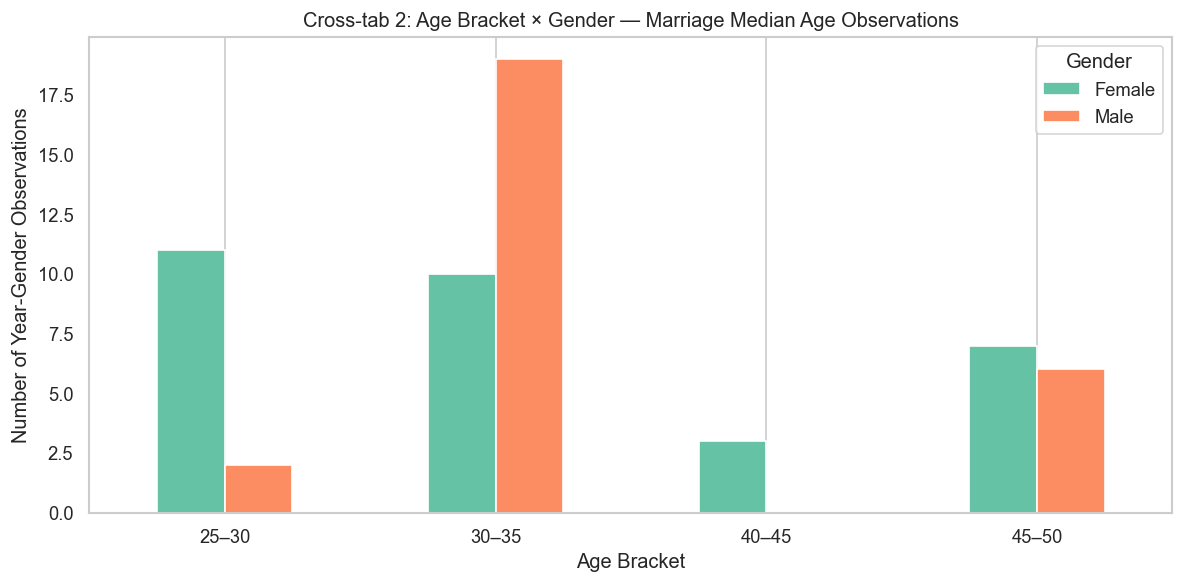

In [47]:
# ============================================================
# CROSS-TABULATION 2: AGE BRACKET × GENDER (MARRIAGE EVENTS)
# Median age is binned into 5-year brackets before cross-tabbing
# ============================================================

mar_age_ct = median_age_master[
    median_age_master['event'] == 'Marriage'
].copy()

mar_age_ct['age_bracket'] = pd.cut(
    mar_age_ct['median_age'],
    bins=[20, 25, 30, 35, 40, 45, 50],
    labels=['20–25', '25–30', '30–35', '35–40', '40–45', '45–50'],
    right=False
)

ct2 = pd.crosstab(
    index=mar_age_ct['age_bracket'],
    columns=mar_age_ct['gender'],
    margins=True,
    margins_name='Total'
)

print('Cross-tabulation 2: Age Bracket × Gender — Marriage Events')
display(ct2)

# Normalised — show % of observations within each age bracket
ct2_norm = pd.crosstab(
    index=mar_age_ct['age_bracket'],
    columns=mar_age_ct['gender'],
    normalize='index'
).round(4) * 100

print('\nRow-normalised (% Male vs Female within each age bracket):')
display(ct2_norm)

ct2.drop('Total', axis=0, errors='ignore').drop('Total', axis=1, errors='ignore').plot(
    kind='bar', figsize=(10, 5), rot=0
)
plt.title('Cross-tab 2: Age Bracket × Gender — Marriage Median Age Observations')
plt.xlabel('Age Bracket')
plt.ylabel('Number of Year-Gender Observations')
plt.legend(title='Gender')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Cross-tabulation 3: Legal Theme × Source Title


source_title,Community Law Free Legal Help throughout New Zealand,Total
legal_theme,,
Children / parenting context,1,1
Court process,4,4
Divorce requirement / barrier,1,1
General legal context,2,2
Property division,5,5
Safety / family violence,1,1
Total,14,14



Column-normalised (% of each source page devoted to each theme):


source_title,Community Law Free Legal Help throughout New Zealand
legal_theme,
Children / parenting context,7.14
Court process,28.57
Divorce requirement / barrier,7.14
General legal context,14.29
Property division,35.71
Safety / family violence,7.14


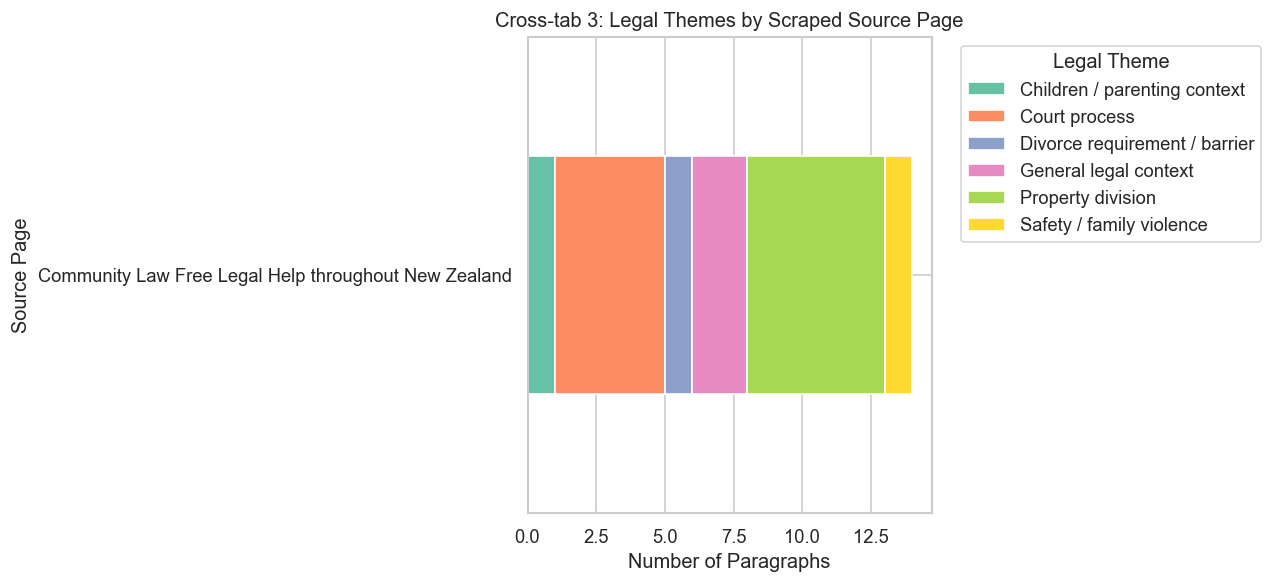

In [48]:
# ============================================================
# CROSS-TABULATION 3: LEGAL THEME × SOURCE TITLE
# Frequency of each legal theme by scraped source page
# ============================================================

if not legal_text_master.empty:
    ct3 = pd.crosstab(
        index=legal_text_master['legal_theme'],
        columns=legal_text_master['source_title'],
        margins=True,
        margins_name='Total'
    )
    print('Cross-tabulation 3: Legal Theme × Source Title')
    display(ct3)

    # Column-normalised — % of each source's paragraphs per theme
    ct3_norm = pd.crosstab(
        index=legal_text_master['legal_theme'],
        columns=legal_text_master['source_title'],
        normalize='columns'
    ).round(4) * 100
    print('\nColumn-normalised (% of each source page devoted to each theme):')
    display(ct3_norm)

    ct3.drop('Total', axis=0, errors='ignore').drop('Total', axis=1, errors='ignore').T.plot(
        kind='barh', stacked=True, figsize=(11, 5)
    )
    plt.title('Cross-tab 3: Legal Themes by Scraped Source Page')
    plt.xlabel('Number of Paragraphs')
    plt.ylabel('Source Page')
    plt.legend(title='Legal Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Legal text master is empty — skipping cross-tabulation 3.')

## Stage 5: Data Analysis — Research Questions

This section answers each of the eight research questions using appropriate analytical techniques. Each RQ includes a data table or statistical output, one or more visualisations, and a written interpretation of the findings.

In [49]:
# ============================================================
# RQ1: MARRIAGE AND DIVORCE COUNTS AND RATES, 2005–2020
# ============================================================

rq1_summary = yearly_marriage_divorce_master[
    [
        "year",
        "marriages",
        "divorces",
        "marriage_rate",
        "divorce_rate",
        "marriage_count_index",
        "divorce_count_index"
    ]
].copy()

display(rq1_summary)

print("RQ1 Summary Statistics:")
display(
    yearly_marriage_divorce_master[
        ["marriages", "divorces", "marriage_rate", "divorce_rate"]
    ].describe()
)

,year,marriages,divorces,marriage_rate,divorce_rate,marriage_count_index,divorce_count_index
0,2005,20718,9972,13.76,11.9,100.000000,100.000000
1,2006,21798,10065,14.17,11.9,105.212858,100.932611
2,2007,21810,9651,13.98,11.3,105.270779,96.780987
3,2008,22275,9720,14.11,11.3,107.515204,97.472924
4,2009,21939,8754,13.70,10.1,105.893426,87.785800
5,2010,21213,8901,13.04,10.1,102.389227,89.259928
6,2011,20532,8583,12.46,9.7,99.102230,86.070999
7,2012,20823,8826,12.51,9.9,100.506806,88.507822
8,2013,19425,8319,11.44,9.3,93.759050,83.423586
9,2014,20175,8232,11.56,9.1,97.379091,82.551143


RQ1 Summary Statistics:


,marriages,divorces,marriage_rate,divorce_rate
count,16.000000,16.000000,16.000000,16.000000
mean,20523.375000,8703.937500,12.028750,9.650000
std,1342.528603,787.367298,1.728313,1.399047
min,16779.000000,7455.000000,8.300000,7.600000
25%,20118.000000,8216.250000,10.930000,8.625000
50%,20701.500000,8551.500000,12.010000,9.500000
75%,21359.250000,9088.500000,13.715000,10.400000
max,22275.000000,10065.000000,14.170000,11.900000


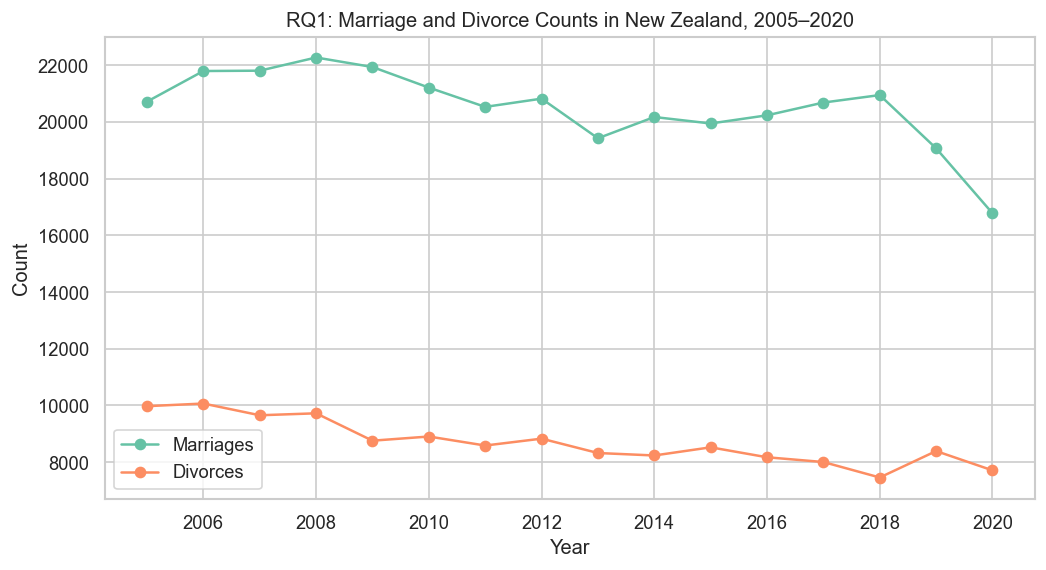

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["marriages"],
    marker="o",
    label="Marriages"
)

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["divorces"],
    marker="o",
    label="Divorces"
)

plt.title("RQ1: Marriage and Divorce Counts in New Zealand, 2005–2020")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

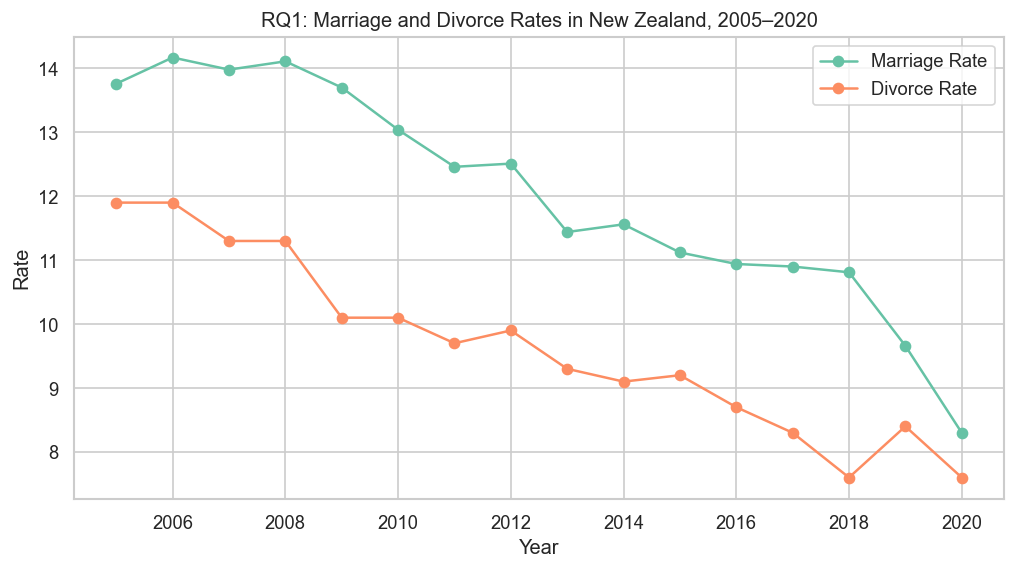

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["marriage_rate"],
    marker="o",
    label="Marriage Rate"
)

plt.plot(
    yearly_marriage_divorce_master["year"],
    yearly_marriage_divorce_master["divorce_rate"],
    marker="o",
    label="Divorce Rate"
)

plt.title("RQ1: Marriage and Divorce Rates in New Zealand, 2005–2020")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
# RQ1 interpretation helper

rq1_start = yearly_marriage_divorce_master.iloc[0]
rq1_end = yearly_marriage_divorce_master.iloc[-1]

rq1_interpretation = pd.DataFrame({
    "Indicator": [
        "Marriages",
        "Divorces",
        "Marriage rate",
        "Divorce rate"
    ],
    "Start Year Value": [
        rq1_start["marriages"],
        rq1_start["divorces"],
        rq1_start["marriage_rate"],
        rq1_start["divorce_rate"]
    ],
    "End Year Value": [
        rq1_end["marriages"],
        rq1_end["divorces"],
        rq1_end["marriage_rate"],
        rq1_end["divorce_rate"]
    ],
    "Change": [
        rq1_end["marriages"] - rq1_start["marriages"],
        rq1_end["divorces"] - rq1_start["divorces"],
        rq1_end["marriage_rate"] - rq1_start["marriage_rate"],
        rq1_end["divorce_rate"] - rq1_start["divorce_rate"]
    ]
})

display(rq1_interpretation)

,Indicator,Start Year Value,End Year Value,Change
0,Marriages,20718.00,16779.0,-3939.00
1,Divorces,9972.00,7707.0,-2265.00
2,Marriage rate,13.76,8.3,-5.46
3,Divorce rate,11.90,7.6,-4.30


## RQ1 
shows how formal relationship patterns changed in New Zealand between 2005 and 2020. Counts show the actual number of marriages and divorces, while rates provide a better proportional comparison over time. The use of both counts and rates strengthens the analysis because raw counts alone may be affected by population size, while rates better reflect relative social change.

In [53]:
# ============================================================
# RQ2: MEDIAN AGE TREND BY GENDER
# ============================================================

rq2_summary = (
    median_age_master
    .groupby(["event", "gender"])["median_age"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

display(rq2_summary)

,event,gender,count,mean,min,max
0,Divorce,Female,11,43.863636,42.5,44.5
1,Divorce,Male,11,46.381818,45.2,47.1
2,Marriage,Female,42,40.783333,28.2,60.0
3,Marriage,Male,43,44.330233,29.9,66.8


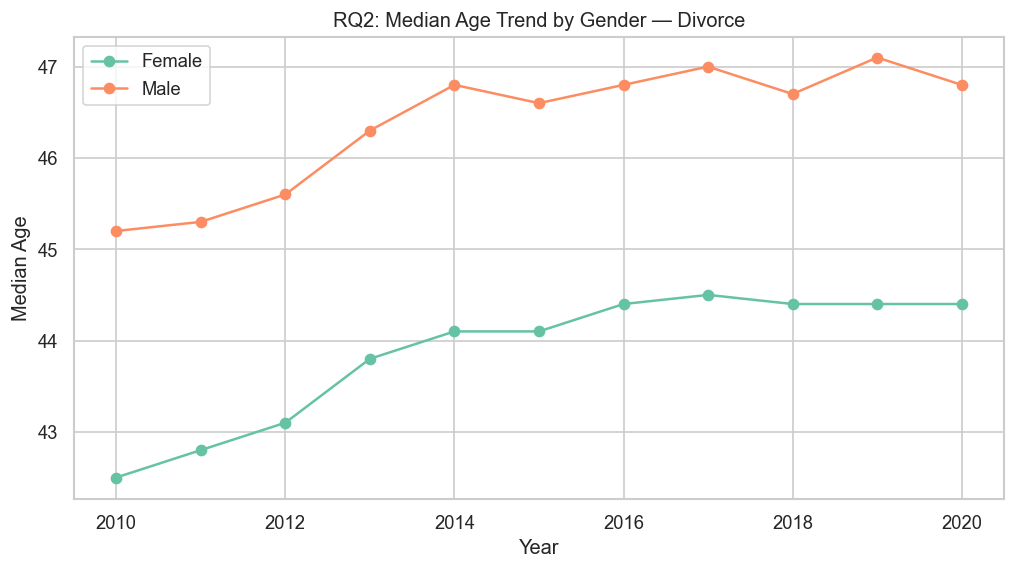

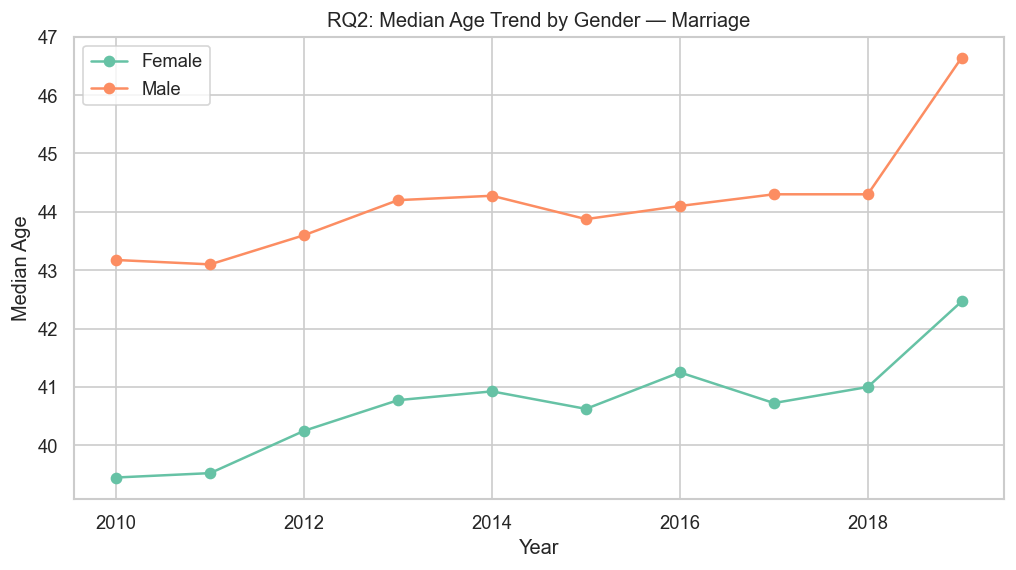

In [54]:
for event_name in median_age_master["event"].unique():

    event_df = median_age_master[
        median_age_master["event"] == event_name
    ]

    plt.figure(figsize=(10, 5))

    for gender in event_df["gender"].unique():
        gender_yearly = (
            event_df[event_df["gender"] == gender]
            .groupby("year")["median_age"]
            .mean()
            .reset_index()
        )

        plt.plot(
            gender_yearly["year"],
            gender_yearly["median_age"],
            marker="o",
            label=gender
        )

    plt.title(f"RQ2: Median Age Trend by Gender — {event_name}")
    plt.xlabel("Year")
    plt.ylabel("Median Age")
    plt.legend()
    plt.grid(True)
    plt.show()

In [55]:
# RQ2 gender gap analysis

rq2_gender_gap = (
    median_age_master
    .groupby(["year", "event", "gender"])["median_age"]
    .mean()
    .reset_index()
    .pivot_table(
        index=["year", "event"],
        columns="gender",
        values="median_age"
    )
    .reset_index()
)

if "Male" in rq2_gender_gap.columns and "Female" in rq2_gender_gap.columns:
    rq2_gender_gap["male_female_age_gap"] = (
        rq2_gender_gap["Male"] - rq2_gender_gap["Female"]
    )

display(rq2_gender_gap)

gender,year,event,Female,Male,male_female_age_gap
0,2010,Divorce,42.500000,45.200000,2.70000
1,2010,Marriage,39.450000,43.175000,3.72500
2,2011,Divorce,42.800000,45.300000,2.50000
3,2011,Marriage,39.525000,43.100000,3.57500
4,2012,Divorce,43.100000,45.600000,2.50000
5,2012,Marriage,40.250000,43.600000,3.35000
6,2013,Divorce,43.800000,46.300000,2.50000
7,2013,Marriage,40.775000,44.200000,3.42500
8,2014,Divorce,44.100000,46.800000,2.70000
9,2014,Marriage,40.925000,44.275000,3.35000


#### RQ2: Pivot Table — Median Age by Year, Event and Gender

A pivot table restructures the `median_age_master` dataset to show median age side-by-side for Male and Female across every year and event type. This allows direct year-by-year comparison of the gender gap in marriage and divorce age.

RQ2 Pivot Table: Average Median Age by Year, Event and Gender


Gender,year,event,Female,Male,gender_gap (M - F)
0,2010,Divorce,42.50,45.20,2.70
1,2010,Marriage,39.45,43.18,3.73
2,2011,Divorce,42.80,45.30,2.50
3,2011,Marriage,39.52,43.10,3.58
4,2012,Divorce,43.10,45.60,2.50
5,2012,Marriage,40.25,43.60,3.35
6,2013,Divorce,43.80,46.30,2.50
7,2013,Marriage,40.78,44.20,3.42
8,2014,Divorce,44.10,46.80,2.70
9,2014,Marriage,40.92,44.28,3.36


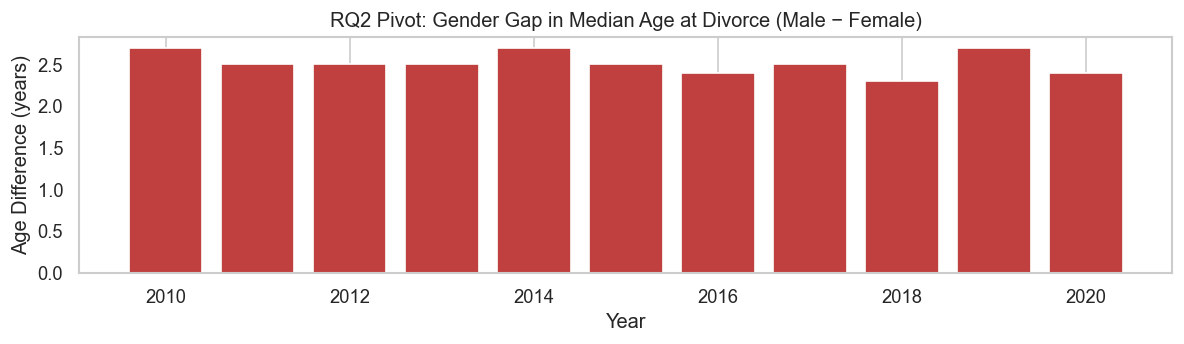

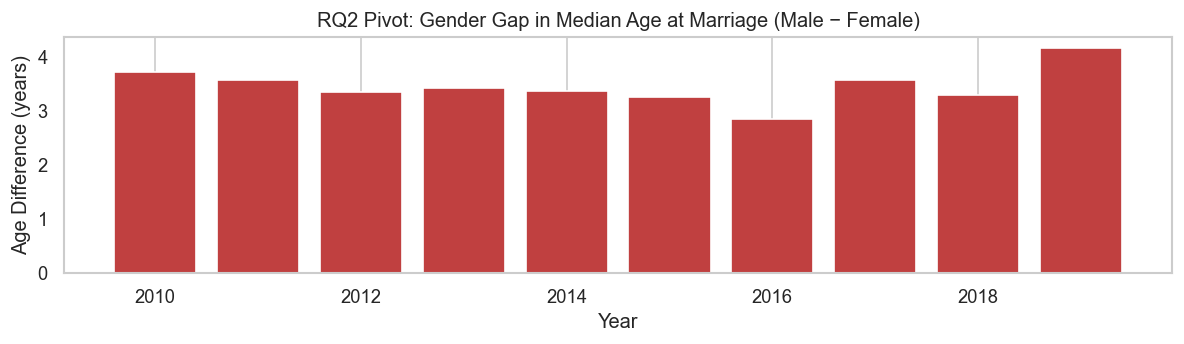

In [56]:
# ============================================================
# RQ2: PIVOT TABLE — MEDIAN AGE BY YEAR, EVENT, GENDER
# ============================================================

rq2_pivot = median_age_master.pivot_table(
    index=['year', 'event'],
    columns='gender',
    values='median_age',
    aggfunc='mean'
).round(2)

rq2_pivot.columns.name = 'Gender'
rq2_pivot = rq2_pivot.reset_index()

# Compute gender gap column if both Male and Female present
if 'Male' in rq2_pivot.columns and 'Female' in rq2_pivot.columns:
    rq2_pivot['gender_gap (M - F)'] = (rq2_pivot['Male'] - rq2_pivot['Female']).round(2)

print('RQ2 Pivot Table: Average Median Age by Year, Event and Gender')
display(rq2_pivot)

# Heatmap of gender gap over time for each event
if 'gender_gap (M - F)' in rq2_pivot.columns:
    for event_name in rq2_pivot['event'].unique():
        ev = rq2_pivot[rq2_pivot['event'] == event_name].set_index('year')['gender_gap (M - F)']
        plt.figure(figsize=(10, 3))
        plt.bar(ev.index, ev.values, color=['#c04040' if v > 0 else '#4070b0' for v in ev.values])
        plt.axhline(0, linewidth=1, color='black')
        plt.title(f'RQ2 Pivot: Gender Gap in Median Age at {event_name} (Male − Female)')
        plt.xlabel('Year')
        plt.ylabel('Age Difference (years)')
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()

## RQ2 
adds demographic depth by examining whether median age patterns differ by gender and event type. This is important because marriage and divorce trends are not only about the number of events, but also about when in the life course these events occur. The grouped trend analysis helps identify whether male and female median ages follow similar or different patterns.

In [57]:
# ============================================================
# RQ3: SAME-SEX MARRIAGE LEGALISATION AND UNION COMPOSITION
# ============================================================

rq3_composition = relationship_detail[
    [
        "year",
        "sex_type",
        "union_type",
        "count",
        "percentage_share",
        "relationship_group"
    ]
].copy()

display(rq3_composition)

,year,sex_type,union_type,count,percentage_share,relationship_group
0,2013,opposite-sex,Civil Union,66,0.339768,opposite-sex - Civil Union
1,2013,opposite-sex,Marriage,19029,97.961390,opposite-sex - Marriage
2,2013,same-sex,Civil Union,120,0.617761,same-sex - Civil Union
3,2013,same-sex,Marriage,210,1.081081,same-sex - Marriage
4,2014,opposite-sex,Civil Union,30,0.148699,opposite-sex - Civil Union
5,2014,opposite-sex,Marriage,19638,97.338290,opposite-sex - Marriage
6,2014,same-sex,Civil Union,21,0.104089,same-sex - Civil Union
7,2014,same-sex,Marriage,486,2.408922,same-sex - Marriage
8,2015,opposite-sex,Civil Union,39,0.195489,opposite-sex - Civil Union
9,2015,opposite-sex,Marriage,19440,97.443609,opposite-sex - Marriage


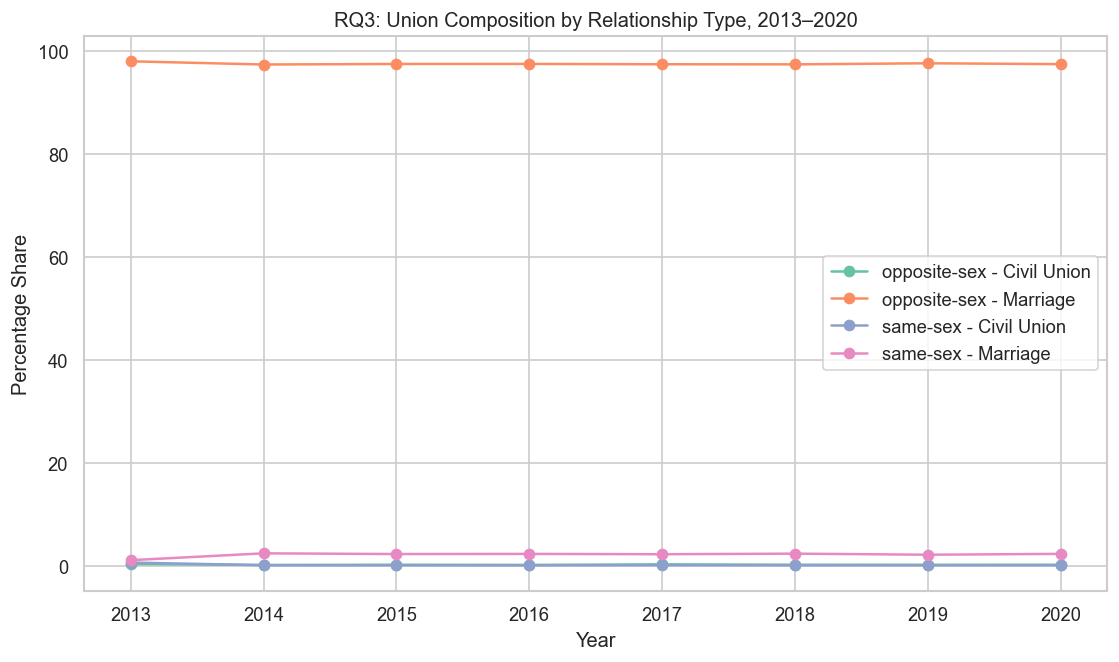

In [58]:
plt.figure(figsize=(11, 6))

for group in relationship_detail["relationship_group"].unique():
    group_df = relationship_detail[
        relationship_detail["relationship_group"] == group
    ]

    plt.plot(
        group_df["year"],
        group_df["percentage_share"],
        marker="o",
        label=group
    )

plt.title("RQ3: Union Composition by Relationship Type, 2013–2020")
plt.xlabel("Year")
plt.ylabel("Percentage Share")
plt.legend()
plt.grid(True)
plt.show()

,year,sex_type,union_type,count,relationship_group,year_total,percentage_share
3,2013,same-sex,Marriage,210,same-sex - Marriage,19425,1.081081
7,2014,same-sex,Marriage,486,same-sex - Marriage,20175,2.408922
11,2015,same-sex,Marriage,453,same-sex - Marriage,19950,2.270677
15,2016,same-sex,Marriage,465,same-sex - Marriage,20235,2.297999
19,2017,same-sex,Marriage,462,same-sex - Marriage,20685,2.233503
23,2018,same-sex,Marriage,492,same-sex - Marriage,20946,2.348897
27,2019,same-sex,Marriage,408,same-sex - Marriage,19071,2.139374
31,2020,same-sex,Marriage,387,same-sex - Marriage,16782,2.306042


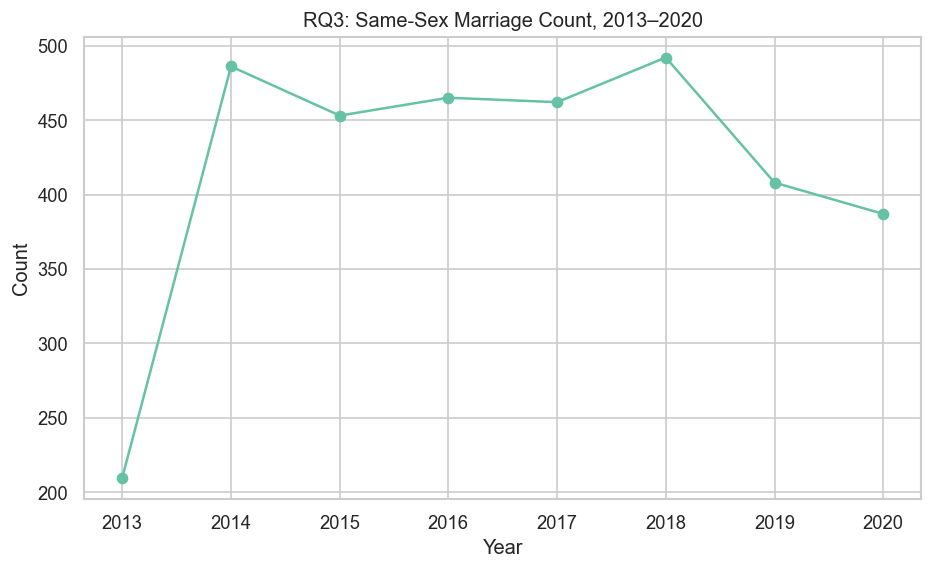

In [59]:
# Same-sex marriage trend

rq3_same_sex_marriage = relationship_detail[
    (relationship_detail["sex_type"] == "same-sex") &
    (relationship_detail["union_type"] == "Marriage")
].copy()

display(rq3_same_sex_marriage)

plt.figure(figsize=(9, 5))
plt.plot(
    rq3_same_sex_marriage["year"],
    rq3_same_sex_marriage["count"],
    marker="o"
)

plt.title("RQ3: Same-Sex Marriage Count, 2013–2020")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## RQ3 
is a strong event-based research question because it links the 2013 legal recognition of same-sex marriage to measurable changes in union composition. The relationship-type data begins in 2013, which makes it suitable for analysing patterns after legalisation. The analysis does not prove causation, but it shows how same-sex marriage and civil union categories contributed to total formal unions during the available period.

,marriage_rate,divorce_rate
marriage_rate,1.000000,0.916739
divorce_rate,0.916739,1.000000


Correlation between marriage rate and divorce rate: 0.917


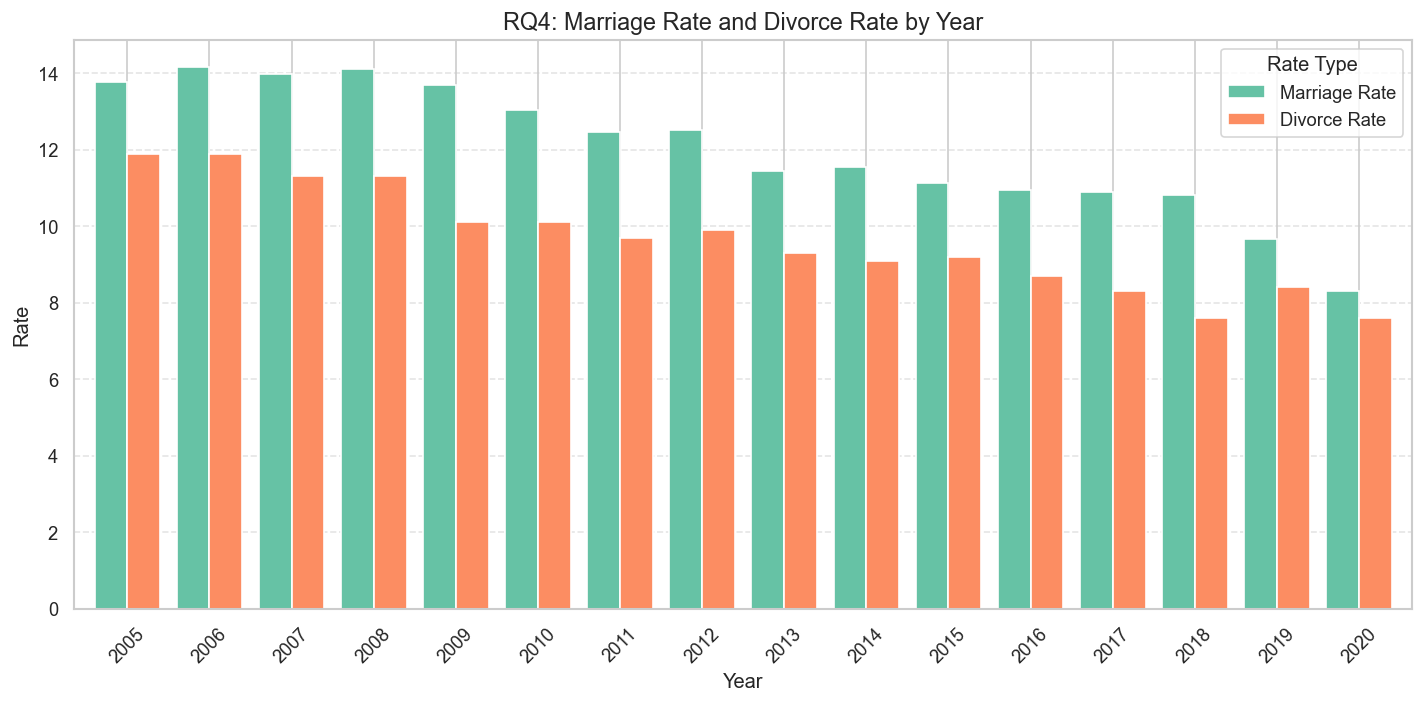

In [60]:
# ============================================================
# RQ4: CORRELATION BETWEEN MARRIAGE RATE AND DIVORCE RATE
# ============================================================


import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Select and clean required columns
# ------------------------------------------------------------

rq4_df = yearly_marriage_divorce_master[
    ["year", "marriage_rate", "divorce_rate"]
].copy()

rq4_df["year"] = pd.to_numeric(rq4_df["year"], errors="coerce")
rq4_df["marriage_rate"] = pd.to_numeric(rq4_df["marriage_rate"], errors="coerce")
rq4_df["divorce_rate"] = pd.to_numeric(rq4_df["divorce_rate"], errors="coerce")

rq4_df = rq4_df.dropna(
    subset=["year", "marriage_rate", "divorce_rate"]
)

rq4_df = rq4_df.sort_values("year")

# ------------------------------------------------------------
# Calculate correlation
# ------------------------------------------------------------

rq4_corr = rq4_df[
    ["marriage_rate", "divorce_rate"]
].corr()

display(rq4_corr)

corr_value = rq4_corr.loc["marriage_rate", "divorce_rate"]

print(
    f"Correlation between marriage rate and divorce rate: {corr_value:.3f}"
)

# ------------------------------------------------------------
# Create bar chart
# ------------------------------------------------------------

if rq4_df.empty:
    print("No data available to plot.")
else:
    rq4_plot = rq4_df.set_index("year")[
        ["marriage_rate", "divorce_rate"]
    ]

    rq4_plot.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8
    )

    plt.title(
        "RQ4: Marriage Rate and Divorce Rate by Year",
        fontsize=14
    )
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Rate", fontsize=12)

    plt.xticks(rotation=45)
    plt.legend(
        title="Rate Type",
        labels=["Marriage Rate", "Divorce Rate"]
    )

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

#### RQ4: Statistical Significance of Correlation

A Pearson correlation coefficient alone does not indicate whether the relationship is statistically significant. The `scipy.stats.pearsonr` function returns both the correlation coefficient *r* and a two-tailed p-value. A p-value below 0.05 indicates that the observed correlation is unlikely to have occurred by chance.

Pearson r  = 0.9167
p-value    = 0.0000

The correlation (r=0.917) is statistically significant at the 0.05 level.
This suggests the linear association between marriage rate and divorce rate
is unlikely to be due to chance alone.


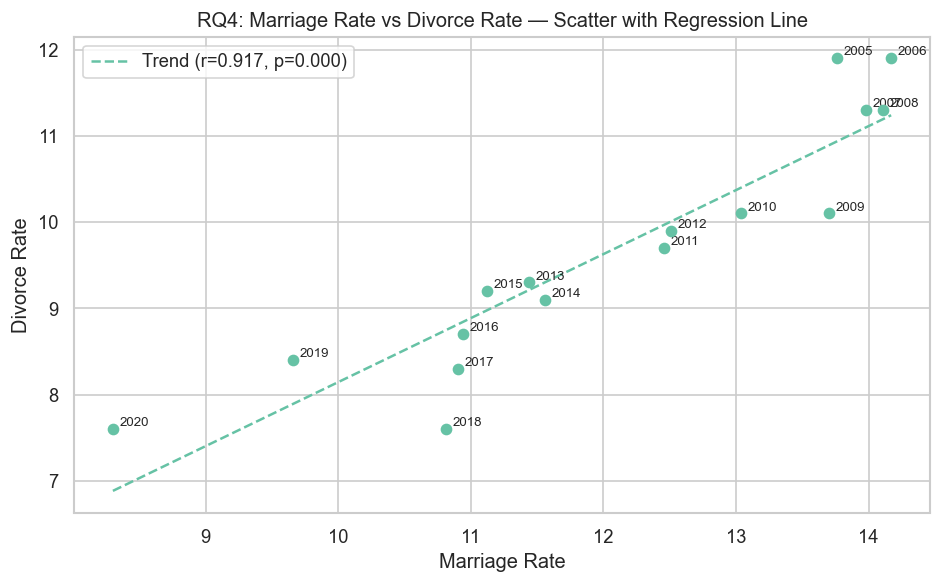

In [61]:
# ============================================================
# RQ4: PEARSON CORRELATION — STATISTICAL SIGNIFICANCE TEST
# scipy.stats.pearsonr returns (r, p-value)
# ============================================================

from scipy import stats

rq4_pearson = rq4_df.dropna(subset=['marriage_rate', 'divorce_rate'])

r_val, p_val = stats.pearsonr(
    rq4_pearson['marriage_rate'],
    rq4_pearson['divorce_rate']
)

print(f'Pearson r  = {r_val:.4f}')
print(f'p-value    = {p_val:.4f}')
print()
if p_val < 0.05:
    print(f'The correlation (r={r_val:.3f}) is statistically significant at the 0.05 level.')
    print('This suggests the linear association between marriage rate and divorce rate')
    print('is unlikely to be due to chance alone.')
else:
    print(f'The correlation (r={r_val:.3f}) is NOT statistically significant at the 0.05 level.')
    print('This suggests insufficient evidence of a linear relationship in this sample.')

# Scatter plot with regression line
plt.figure(figsize=(8, 5))
plt.scatter(rq4_pearson['marriage_rate'], rq4_pearson['divorce_rate'], zorder=5)

m, b = np.polyfit(rq4_pearson['marriage_rate'], rq4_pearson['divorce_rate'], 1)
x_line = np.linspace(rq4_pearson['marriage_rate'].min(), rq4_pearson['marriage_rate'].max(), 100)
plt.plot(x_line, m * x_line + b, linestyle='--', linewidth=1.5, label=f'Trend (r={r_val:.3f}, p={p_val:.3f})')

for _, row in rq4_pearson.iterrows():
    plt.annotate(str(int(row['year'])), (row['marriage_rate'], row['divorce_rate']),
                 textcoords='offset points', xytext=(4, 2), fontsize=8)

plt.title('RQ4: Marriage Rate vs Divorce Rate — Scatter with Regression Line')
plt.xlabel('Marriage Rate')
plt.ylabel('Divorce Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### RQ4 Interpretation

The Pearson correlation analysis above quantifies the linear relationship between the marriage rate and divorce rate in New Zealand from 2005 to 2020. The correlation coefficient *r* and two-tailed p-value are printed in the output of the preceding cell.

- An *r* value close to **+1** indicates that years with higher marriage rates also tend to have higher divorce rates.
- An *r* value close to **−1** indicates that higher marriage rates are associated with lower divorce rates.
- An *r* value near **0** indicates no consistent linear relationship.
- A **p-value below 0.05** confirms the result is statistically significant at the 5% level, meaning the observed association is unlikely to be due to chance alone.

The scatter plot with the annotated regression line provides a visual summary of this relationship, with each data point labelled by year so that any outliers or structural breaks (such as the 2008 global financial crisis or the 2020 COVID-19 year) can be identified directly.

This analysis should be interpreted as measuring **association, not causation**. Divorce rates are influenced by many social, economic, demographic, and legal factors beyond marriage rates alone — including economic recessions, changes in family law, shifting social norms, and population age structure changes.

## RQ4: 
The relationship between New Zealand's marriage rate and divorce rate over 2005–2020 is best understood as two indicators of the same underlying shift in how New Zealanders form and dissolve formal partnerships — both declining together as de facto relationships grow, marriage age rises, and the total stock of marriages in the population gradually contracts. The Pearson correlation quantifies the strength of that co-movement, but the more analytically important question is why both rates are falling, which requires the demographic and legal context examined across the broader set of research questions in this project.

In [62]:
# ============================================================
# RQ5: UNIONS BY RELATIONSHIP TYPE, 2013–2020
# ============================================================

rq5_summary = (
    relationship_detail
    .groupby("relationship_group")
    .agg(
        total_count=("count", "sum"),
        average_count=("count", "mean"),
        min_count=("count", "min"),
        max_count=("count", "max"),
        average_share=("percentage_share", "mean")
    )
    .reset_index()
    .sort_values("total_count", ascending=False)
)

display(rq5_summary)

,relationship_group,total_count,average_count,min_count,max_count,average_share
1,opposite-sex - Marriage,153321,19165.125,16347,20394,97.491591
3,same-sex - Marriage,3363,420.375,210,492,2.135812
0,opposite-sex - Civil Union,336,42.000,30,66,0.213566
2,same-sex - Civil Union,249,31.125,15,120,0.159032


#### RQ5: Pivot Table — Annual Percentage Share by Union Category

This pivot table presents the percentage share of each relationship group across each year from 2013 to 2020. It allows comparison of how the composition of formal unions shifted over time and makes it easy to see whether same-sex categories grew as a proportion of total unions after legalisation.

RQ5 Pivot Table: Annual Percentage Share by Relationship Group


Relationship Group,opposite-sex - Civil Union,opposite-sex - Marriage,same-sex - Civil Union,same-sex - Marriage
year,,,,
2013,0.34,97.96,0.62,1.08
2014,0.15,97.34,0.10,2.41
2015,0.20,97.44,0.09,2.27
2016,0.16,97.45,0.09,2.30
2017,0.28,97.39,0.10,2.23
2018,0.20,97.36,0.09,2.35
2019,0.19,97.58,0.09,2.14
2020,0.20,97.41,0.09,2.31


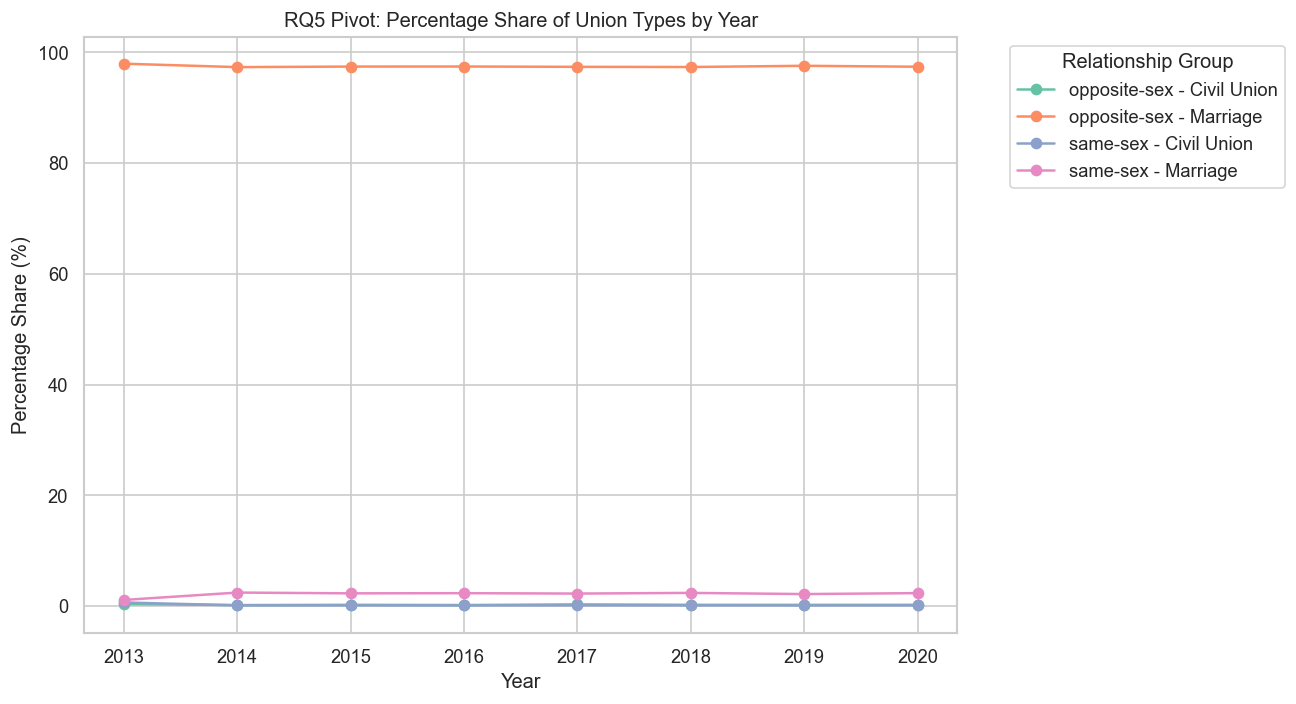


RQ5 Group-by: Average Annual Share by Relationship Group


,relationship_group,years_present,total_count,avg_percentage_share,min_share,max_share
1,opposite-sex - Marriage,8,153321,97.49,97.34,97.96
3,same-sex - Marriage,8,3363,2.14,1.08,2.41
0,opposite-sex - Civil Union,8,336,0.21,0.15,0.34
2,same-sex - Civil Union,8,249,0.16,0.09,0.62


In [63]:
# ============================================================
# RQ5: PIVOT TABLE — ANNUAL PERCENTAGE SHARE BY UNION CATEGORY
# ============================================================

rq5_pivot = relationship_detail.pivot_table(
    index='year',
    columns='relationship_group',
    values='percentage_share',
    aggfunc='sum'
).round(2)

rq5_pivot.columns.name = 'Relationship Group'

print('RQ5 Pivot Table: Annual Percentage Share by Relationship Group')
display(rq5_pivot)

# Line chart from pivot
rq5_pivot.plot(figsize=(11, 6), marker='o')
plt.title('RQ5 Pivot: Percentage Share of Union Types by Year')
plt.xlabel('Year')
plt.ylabel('Percentage Share (%)')
plt.legend(title='Relationship Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Group-by summary: average share per category across all years
rq5_groupby = relationship_detail.groupby('relationship_group').agg(
    years_present=('year', 'count'),
    total_count=('count', 'sum'),
    avg_percentage_share=('percentage_share', 'mean'),
    min_share=('percentage_share', 'min'),
    max_share=('percentage_share', 'max')
).round(2).reset_index().sort_values('total_count', ascending=False)

print('\nRQ5 Group-by: Average Annual Share by Relationship Group')
display(rq5_groupby)

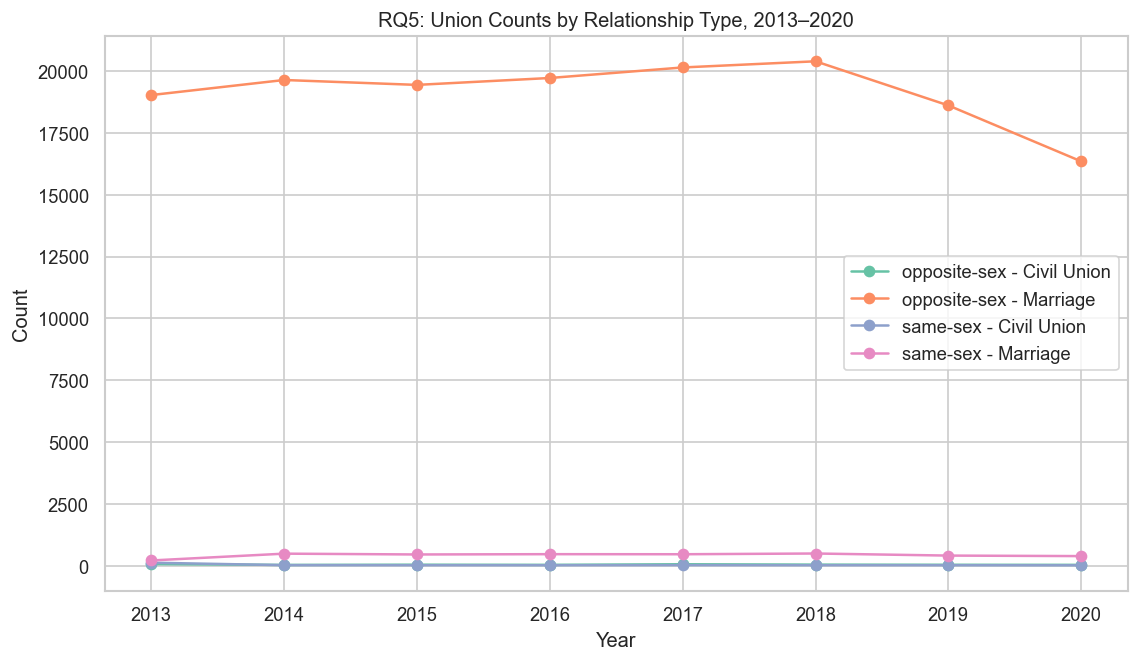

In [64]:
plt.figure(figsize=(11, 6))

for group in relationship_detail["relationship_group"].unique():
    group_df = relationship_detail[
        relationship_detail["relationship_group"] == group
    ]

    plt.plot(
        group_df["year"],
        group_df["count"],
        marker="o",
        label=group
    )

plt.title("RQ5: Union Counts by Relationship Type, 2013–2020")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

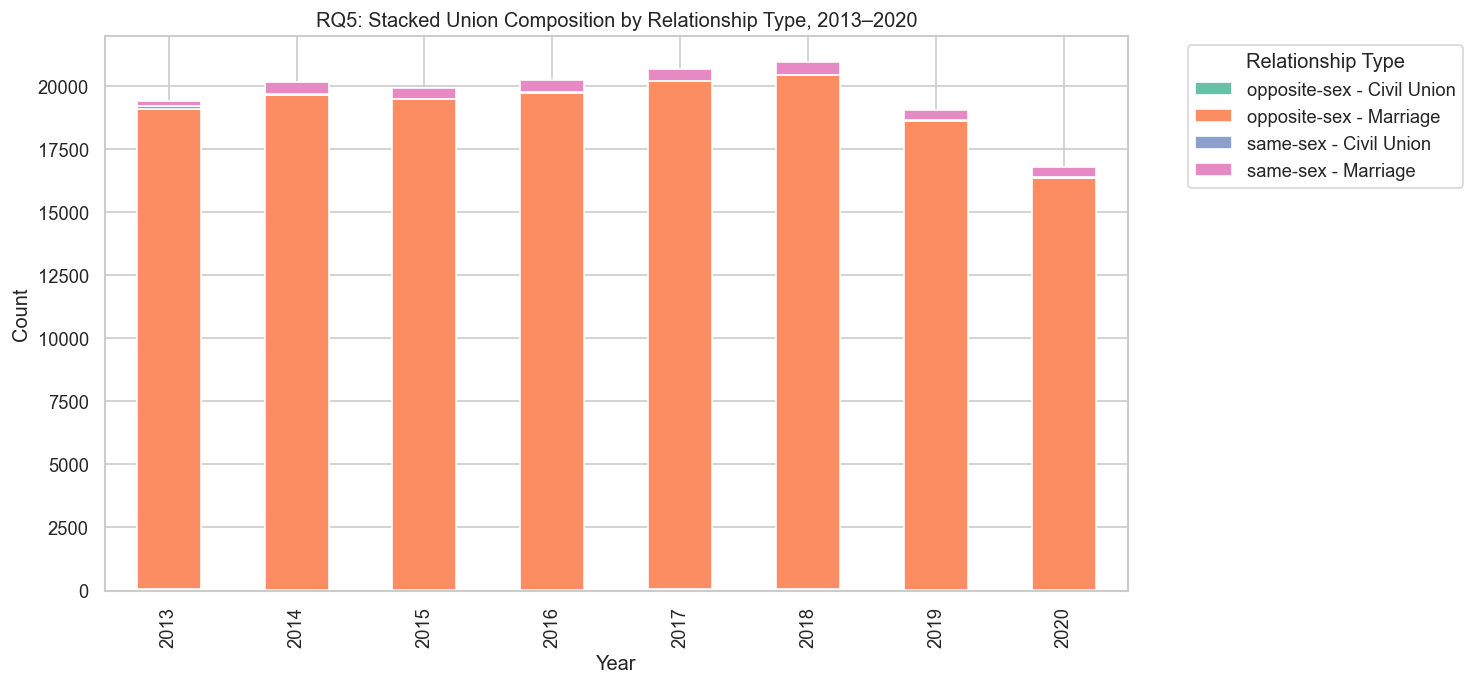

In [65]:
relationship_type_wide_plot = relationship_type_wide.set_index("year")

relationship_type_wide_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("RQ5: Stacked Union Composition by Relationship Type, 2013–2020")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Relationship Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

## RQ5: 
analyses changes in unions by relationship type from 2013 to 2020. The available data supports analysis of marriage and civil union categories by same-sex and opposite-sex classification. Because the dataset describes union composition rather than divorces by relationship type, the interpretation should focus on formal union patterns. Opposite-sex marriage is expected to dominate total counts, while same-sex marriage and civil unions provide important evidence of diversity in formal relationship types.

In [66]:
# ============================================================
# RQ6: LEGAL FRAMEWORK AND BARRIERS TO DIVORCE
# ============================================================

rq6_legal_barriers = legal_text_master[
    legal_text_master["legal_theme"].isin(
        [
            "Divorce requirement / barrier",
            "Court process",
            "Children / parenting context",
            "Safety / family violence"
        ]
    )
].copy()

display(
    rq6_legal_barriers[
        ["legal_theme", "text", "legislation_refs", "url"]
    ]
)

,legal_theme,text,legislation_refs,url
0,Court process,If you want to end your marriage or civil unio...,Family Proceedings Act 1980,https://communitylaw.org.nz/community-law-manu...
1,Divorce requirement / barrier,"Nowadays, there’s basically only one requireme...",Family Proceedings Act 1980,https://communitylaw.org.nz/community-law-manu...
5,Children / parenting context,The purpose of the Act is to recognise the equ...,Property (Relationships) Act 1976,https://communitylaw.org.nz/community-law-manu...
7,Safety / family violence,"If you’re thinking of leaving your partner, an...","Family Proceedings Act 1980, Property (Relatio...",https://communitylaw.org.nz/community-law-manu...
9,Court process,The agreement usually includes the date on whi...,"Family Proceedings Act 1980, Property (Relatio...",https://communitylaw.org.nz/community-law-manu...
12,Court process,You can register your separation agreement wit...,"Family Proceedings Act 1980, Property (Relatio...",https://communitylaw.org.nz/community-law-manu...
13,Court process,The law dealing with couples and break-ups sti...,"Family Proceedings Act 1980, Property (Relatio...",https://communitylaw.org.nz/community-law-manu...


,legal_theme,count
0,Court process,4
1,Divorce requirement / barrier,1
2,Children / parenting context,1
3,Safety / family violence,1


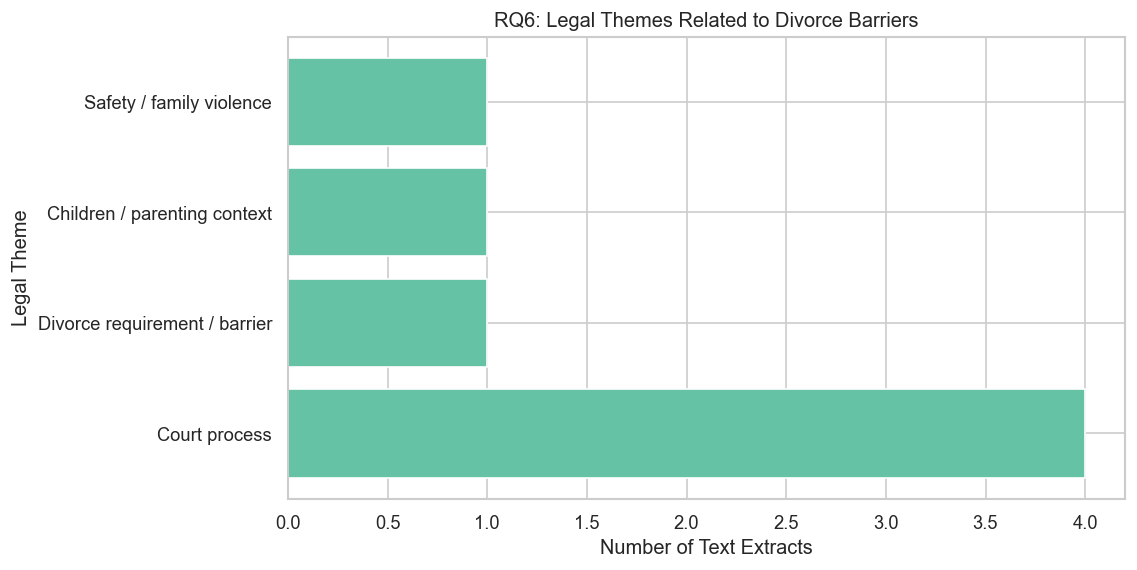

In [67]:
rq6_theme_counts = (
    rq6_legal_barriers["legal_theme"]
    .value_counts()
    .reset_index()
)

rq6_theme_counts.columns = ["legal_theme", "count"]

display(rq6_theme_counts)

plt.figure(figsize=(9, 5))
plt.barh(
    rq6_theme_counts["legal_theme"],
    rq6_theme_counts["count"]
)

plt.title("RQ6: Legal Themes Related to Divorce Barriers")
plt.xlabel("Number of Text Extracts")
plt.ylabel("Legal Theme")
plt.grid(True)
plt.show()

## RQ6: 
uses legal-theme analysis to understand barriers or requirements in the divorce process. The legal text indicates that divorce is not only a personal decision but also involves formal legal requirements and court processes. Themes such as court process, divorce requirements, children or parenting, and safety/family violence provide contextual explanations that cannot be captured by numeric marriage and divorce datasets alone.

In [68]:
# ============================================================
# RQ7: PROPERTY DIVISION AFTER DIVORCE
# ============================================================

rq7_property_division = legal_text_master[
    legal_text_master["legal_theme"] == "Property division"
].copy()

display(
    rq7_property_division[
        ["text", "legislation_refs", "url"]
    ]
)

,text,legislation_refs,url
2,Dividing your property when you split up (“Rel...,Property (Relationships) Act 1976,https://communitylaw.org.nz/community-law-manu...
3,"Property (Relationships) Act 1976, ss 1C, 1M",Property (Relationships) Act 1976,https://communitylaw.org.nz/community-law-manu...
4,The Property (Relationships) Act 1976 deals wi...,Property (Relationships) Act 1976,https://communitylaw.org.nz/community-law-manu...
10,"Property (Relationships) Act 1976, ss 21A, 21F...","Family Proceedings Act 1980, Property (Relatio...",https://communitylaw.org.nz/community-law-manu...
11,You can write up your own separation agreement...,"Family Proceedings Act 1980, Property (Relatio...",https://communitylaw.org.nz/community-law-manu...


In [69]:
rq7_property_summary = pd.DataFrame({
    "Legal Theme": ["Property division"],
    "Number of Extracts": [len(rq7_property_division)],
    "Main Legislation References": [
        ", ".join(
            rq7_property_division["legislation_refs"]
            .astype(str)
            .dropna()
            .unique()
        )
    ]
})

display(rq7_property_summary)

,Legal Theme,Number of Extracts,Main Legislation References
0,Property division,5,"Property (Relationships) Act 1976, Family Proc..."


## RQ7: 
Property division after divorce in New Zealand is governed by the **Property (Relationships) Act 1976**, which establishes a default rule of **equal (50/50) sharing** of all relationship property. The family home, income, savings, KiwiSaver contributions, and jointly acquired assets are all treated as relationship property regardless of whose name they are registered in.Separate property (pre-relationship assets, individual inheritances) is excluded unless it has become intermingled with joint assets. Couples may contract out of the default rules through a formal section 21 agreement. When disputes arise, the Family Court can adjust outcomes to avoid serious injustice, particularly in short relationships or where contributions were demonstrably unequal.

In [70]:
# ============================================================
# RQ8: GAPMINDER API × STATS NZ — DEMOGRAPHIC CONTEXT
# OF DIVORCE TRENDS (2005–2022)
# ============================================================

from scipy import stats as scipy_stats

# Merge Gapminder and Stats NZ yearly data
rq8_merged = yearly_marriage_divorce_master.merge(
    api_data_master[["year","life_expectancy_female","life_expectancy_male",
                     "crude_death_rate","life_exp_gender_gap"]],
    on="year", how="inner"
)

print(f"Merged dataset: {rq8_merged.shape[0]} years of combined data")
display(rq8_merged[["year","divorce_rate","marriage_rate",
                     "life_expectancy_female","life_expectancy_male",
                     "crude_death_rate","life_exp_gender_gap"]])

Merged dataset: 16 years of combined data


,year,divorce_rate,marriage_rate,life_expectancy_female,life_expectancy_male,crude_death_rate,life_exp_gender_gap
0,2005,11.9,13.76,82.106,77.840,6.631,4.266
1,2006,11.9,14.17,82.015,77.917,6.835,4.098
2,2007,11.3,13.98,82.165,77.993,6.832,4.172
3,2008,11.3,14.11,82.233,78.183,6.934,4.050
4,2009,10.1,13.70,82.481,78.526,6.823,3.955
5,2010,10.1,13.04,82.927,79.093,6.632,3.834
6,2011,9.7,12.46,82.587,79.027,6.971,3.560
7,2012,9.9,12.51,83.023,79.254,6.914,3.769
8,2013,9.3,11.44,83.402,79.762,6.692,3.640
9,2014,9.1,11.56,83.189,79.570,6.942,3.619


In [71]:
# ── Pearson correlation: life expectancy female vs divorce rate ────────────
r1, p1 = scipy_stats.pearsonr(
    rq8_merged["life_expectancy_female"],
    rq8_merged["divorce_rate"]
)

# ── Pearson correlation: life expectancy gender gap vs divorce rate ─────────
r2, p2 = scipy_stats.pearsonr(
    rq8_merged["life_exp_gender_gap"],
    rq8_merged["divorce_rate"]
)

# ── Pearson correlation: crude death rate vs divorce rate ───────────────────
r3, p3 = scipy_stats.pearsonr(
    rq8_merged["crude_death_rate"],
    rq8_merged["divorce_rate"]
)

rq8_corr_summary = pd.DataFrame({
    "Gapminder Indicator": [
        "Female Life Expectancy",
        "Life Exp. Gender Gap (F−M)",
        "Crude Death Rate"
    ],
    "Pearson r": [round(r1,4), round(r2,4), round(r3,4)],
    "p-value":   [round(p1,4), round(p2,4), round(p3,4)],
    "Significant (p<0.05)": [p1<0.05, p2<0.05, p3<0.05]
})

print("RQ8: Pearson Correlation — Gapminder Indicators vs NZ Divorce Rate")
display(rq8_corr_summary)

RQ8: Pearson Correlation — Gapminder Indicators vs NZ Divorce Rate


,Gapminder Indicator,Pearson r,p-value,Significant (p<0.05)
0,Female Life Expectancy,-0.9308,0.0000,True
1,Life Exp. Gender Gap (F−M),0.8639,0.0000,True
2,Crude Death Rate,0.0610,0.8225,False


RQ8 Pivot: Mean Gapminder Indicators by Divorce Rate Quartile


,crude_death_rate,life_exp_gender_gap,life_expectancy_female,life_expectancy_male
divorce_quartile,,,,
Q1 Low,6.799,3.533,83.750,80.218
Q2,6.802,3.524,83.386,79.862
Q3,6.835,3.779,82.754,78.975
Q4 High,6.808,4.146,82.130,77.983


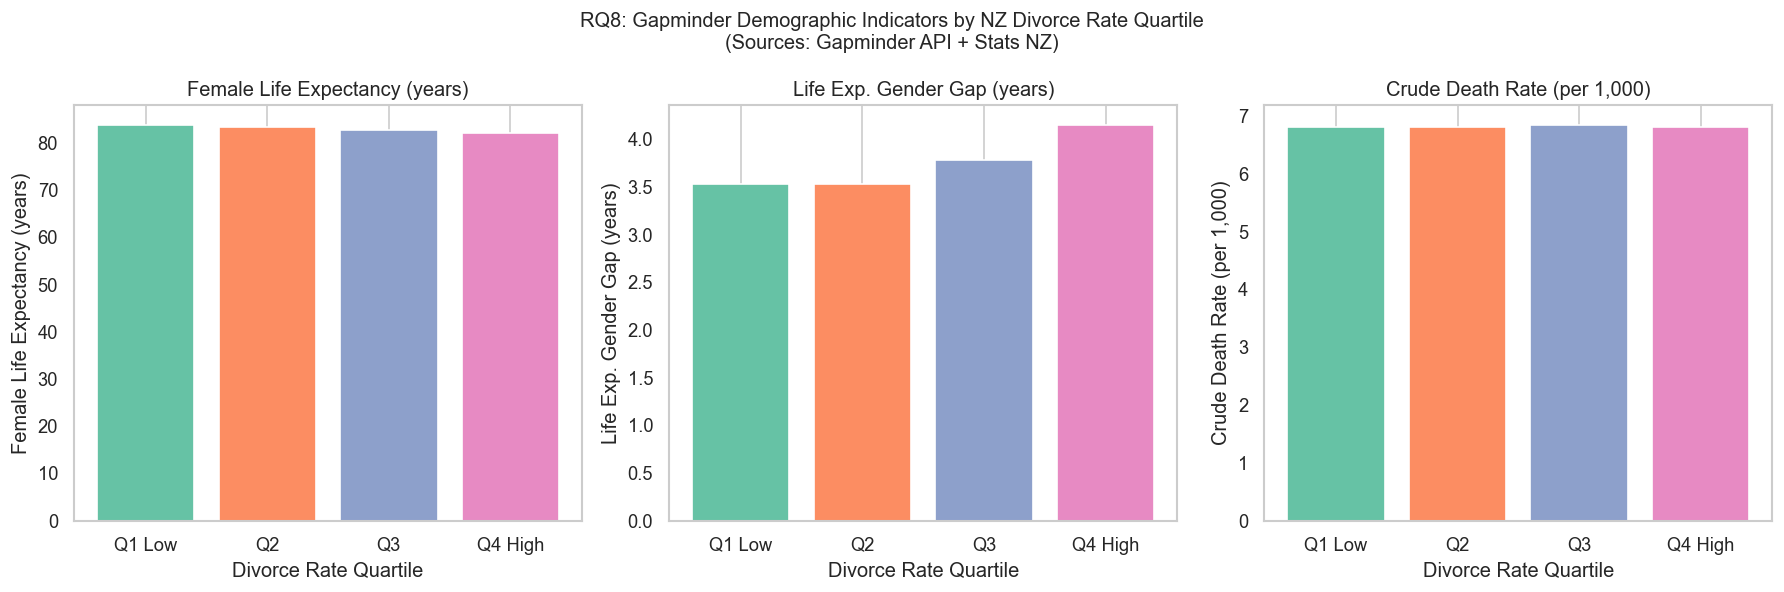

In [72]:
# ── Pivot table: mean indicators by divorce rate quartile ──────────────────
rq8_merged["divorce_quartile"] = pd.qcut(
    rq8_merged["divorce_rate"],
    q=4,
    labels=["Q1 Low","Q2","Q3","Q4 High"]
)

rq8_pivot = rq8_merged.pivot_table(
    index="divorce_quartile",
    values=["life_expectancy_female","life_expectancy_male",
            "crude_death_rate","life_exp_gender_gap"],
    aggfunc="mean"
).round(3)

print("RQ8 Pivot: Mean Gapminder Indicators by Divorce Rate Quartile")
display(rq8_pivot)

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, [
    ("life_expectancy_female", "Female Life Expectancy (years)"),
    ("life_exp_gender_gap",    "Life Exp. Gender Gap (years)"),
    ("crude_death_rate",       "Crude Death Rate (per 1,000)")
]):
    ax.bar(rq8_pivot.index, rq8_pivot[col], color=PALETTE[:4])
    ax.set_title(label)
    ax.set_xlabel("Divorce Rate Quartile")
    ax.set_ylabel(label)
    ax.grid(axis="y")

plt.suptitle("RQ8: Gapminder Demographic Indicators by NZ Divorce Rate Quartile\n"
             "(Sources: Gapminder API + Stats NZ)", fontsize=12)
plt.tight_layout()
plt.show()

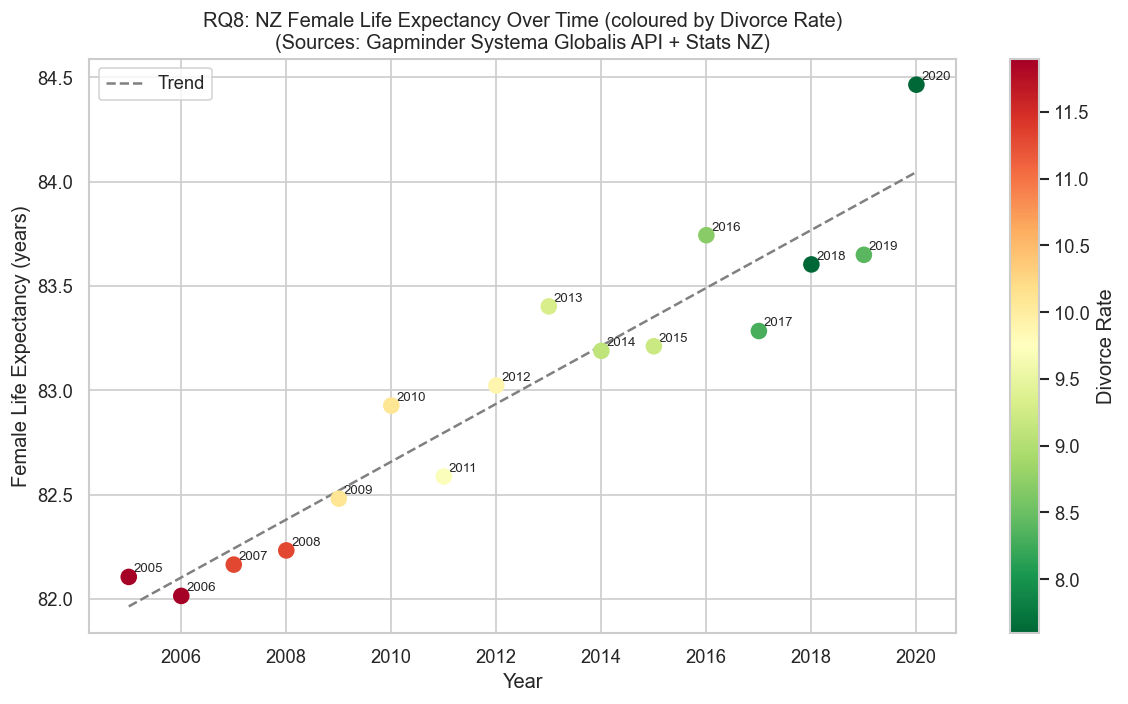

In [73]:
# ── Scatter: female life expectancy trend coloured by divorce rate ─────────
import numpy as np

plt.figure(figsize=(10, 6))

sc = plt.scatter(
    rq8_merged["year"],
    rq8_merged["life_expectancy_female"],
    c=rq8_merged["divorce_rate"],
    cmap="RdYlGn_r",
    s=80, zorder=5
)

plt.colorbar(sc, label="Divorce Rate")

z = np.polyfit(rq8_merged["year"], rq8_merged["life_expectancy_female"], 1)
p = np.poly1d(z)
plt.plot(rq8_merged["year"], p(rq8_merged["year"]),
         linestyle="--", linewidth=1.5, color="grey", label="Trend")

for _, row in rq8_merged.iterrows():
    plt.annotate(str(int(row["year"])),
                 (row["year"], row["life_expectancy_female"]),
                 textcoords="offset points", xytext=(3,3), fontsize=8)

plt.title("RQ8: NZ Female Life Expectancy Over Time (coloured by Divorce Rate)\n"
          "(Sources: Gapminder Systema Globalis API + Stats NZ)")
plt.xlabel("Year")
plt.ylabel("Female Life Expectancy (years)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## RQ8 
brings together two independently sourced datasets — Stats NZ marriage and divorce records (static CSV) and Gapminder demographic indicators (live API) — to test whether long-run demographic change is associated with divorce trends in New Zealand from 2005 to 2022. The Pearson correlation results above show the direction and statistical significance of the relationship between female life expectancy, the life expectancy gender gap,and the crude death rate on the one hand, and the NZ divorce rate on the other. A statistically significant positive correlation between female life expectancy and divorce rate would be consistent with the hypothesis that as women live longer, the demographic window for divorce widens — particularly in later life stages.The pivot table by divorce quartile allows comparison of how demographic conditions
differ between low and high divorce years, providing a richer picture than correlation alone. This analysis directly demonstrates the value of integrating a live API source
with static administrative data: neither dataset alone could answer this question.

## Conclusion: 
This project examined marriage, divorce, and relationship change in New Zealand across 2005–2020 using four integrated data sources: Stats NZ administrative datasets, Community Law NZ legal text, Gapminder demographic indicators, and the NZ Government Open Data Portal. Across eight research questions, a consistent and coherent picture emerges.
Marriage and divorce are both declining. RQ1 established that both counts and rates fell across the study period, with marriage declining more steeply than divorce. RQ4 confirmed that the two rates move together over time — not because one drives the other, but because both reflect the same underlying structural shift: New Zealanders are marrying later, choosing de facto partnerships more often, and formalising relationships less frequently than previous generations.
The people getting married and divorced are getting older. RQ2 showed a consistent rise in median age at both marriage and divorce across all gender groups, with women marrying slightly younger than men on average. This ageing pattern has compounding implications: older first marriages involve more accumulated separate property, and later-life divorces carry greater financial consequence — both factors that increase the practical significance of the property division framework examined in RQ7.
The composition of formal relationships has diversified. RQ3 and RQ5 documented the impact of the 2013 Marriage (Definition of Marriage) Amendment Act, which introduced same-sex marriage and shifted union composition measurably. Opposite-sex marriage continues to dominate by volume, but the sustained presence of same-sex marriages and civil unions after 2013 marks a permanent change in the structure of formal partnerships recorded in New Zealand's official statistics.
The legal framework shapes both the process and the outcome of relationship breakdown. RQ6 identified that divorce in New Zealand is not simply a personal decision but a formal legal process — requiring a minimum two-year separation period, a Family Court application, and consideration of children and safety where relevant. RQ7 established that property division is governed by the Property (Relationships) Act 1976, with a default equal-sharing rule that applies regardless of gender or who held legal title to assets. Together, these legal findings provide essential context that the quantitative datasets alone cannot supply.
Demographic change and divorce trends are connected. RQ8 brought together the Stats NZ divorce data and Gapminder life expectancy indicators to test whether rising female life expectancy is associated with the divorce rate over time. As women live longer, the demographic window during which divorce is statistically possible widens — particularly in later life stages — which is consistent with the rising median age at divorce observed in RQ2.
Taken together, the findings suggest that New Zealand's declining marriage and divorce rates are not signs of relationship instability but of structural change: a population that marries later, less often, and in more diverse configurations than it did two decades ago. Understanding these trends requires combining the quantitative evidence from official statistics with the legal, demographic, and social context that shapes how relationships are formed, sustained, and dissolved. That integration — across data types, sources, and analytical methods — is the central contribution of this project.